# ============================================================
# MODULE 8 — APACHE SPARK
# NovaBuild Risk Management Pipeline
# ============================================================

# ── SECTION 8.1: Spark Architecture ─────────────────────────
# Setup, JDBC reads, core transformations, capstone query




**What is Spark, in plain english?**

You know Pandas. In Pandas, you load a CSV into your laptop's RAM and process it there. One machine, one CPU, all the data sits in one place.

Spark does the same thing — but it's designed for when your data is too big for one machine. It splits the data into chunks and processes each chunk on a different machine (or a different CPU core) at the same time.

That's the entire idea. Everything else — drivers, executors, DAGs — is just the machinery that makes that splitting and parallel processing work.

**In your Colab notebook right now,** there's no real cluster. Spark will just use the 2 CPU cores Colab gives you. But the code you write is identical to production Spark on a 100-machine cluster. That's why you're learning it this way.

In [1]:
# Install PostgreSQL driver + PySpark
!pip install pyspark --quiet
!apt-get install -y postgresql postgresql-contrib > /dev/null 2>&1
!service postgresql start

!pip install psycopg2-binary --quiet

 * Starting PostgreSQL 14 database server
   ...done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 24.5 MB/s eta 0:00:00


apt-get update && apt-get install -y postgresql && service postgresql start && sudo -u postgres psql -c "CREATE USER saas_user WITH PASSWORD 'saas_pass';" && sudo -u postgres psql -c "CREATE DATABASE novabuilds OWNER saas_user;" && sudo -u postgres psql -c "GRANT ALL PRIVILEGES ON DATABASE novabuilds TO saas_user;" && echo "DONE"

**Run your NovaBuild setup script**

In [2]:
# This is the exact same script you already have
# Just run it — it creates all 21 tables and loads all 76,529 rows
exec(open('/content/novabuilds_colab_setup_v2.py').read())

Connected. Ready.
All 21 tables created.
Loading data...
  ✓ carriers                           15 rows
  ✓ brokers                            40 rows
  ✓ sponsors                           80 rows
  ✓ contractors                      1500 rows
  ✓ projects                          200 rows
  ✓ wrap_programs                     200 rows
  ✓ contractor_enrollments           6000 rows
  ✓ payroll_reports                 18000 rows
  ✓ policies                          600 rows
  ✓ policy_coverages                 1794 rows
  ✓ endorsements                      900 rows
  ✓ premiums                         4500 rows
  ✓ certificates                     9000 rows
  ✓ coi_verifications                9000 rows
  ✓ compliance_tracking              6000 rows
  ✓ prequalifications                1500 rows
  ✓ safety_incidents                 4000 rows
  ✓ inspections                      5000 rows
  ✓ claims                           2500 rows
  ✓ claim_assessments                2500 rows
  ✓

<string>:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.


  carriers                           15
  brokers                            40
  sponsors                           80
  contractors                     1,500
  projects                          200
  wrap_programs                     200
  contractor_enrollments          6,000
  payroll_reports                18,000
  policies                          600
  policy_coverages                1,794
  endorsements                      900
  premiums                        4,500
  certificates                    9,000
  coi_verifications               9,000
  compliance_tracking             6,000
  prequalifications               1,500
  safety_incidents                4,000
  inspections                     5,000
  claims                          2,500
  claim_assessments               2,500
  claim_payments                  3,200
----------------------------------------
  TOTAL                          76,529

── COI Compliance Rate by Contractor Tier ──


,tier,total_verifications,compliant,compliance_rate_pct
0,Conditional,2308,1442,62.5
1,Probationary,2437,1513,62.1
2,Preferred,2135,1311,61.4
3,Standard,2120,1285,60.6



── Loss Ratio by Project Type ──


...

,project_type,claim_count,premium_collected_m,incurred_loss_m,loss_ratio_pct
0,School,178,810.84,1155.64,142.5
1,Highway,230,1092.16,1460.01,133.7
2,Data Center,280,1484.33,1919.58,129.3
3,Industrial Facility,264,1132.17,1434.62,126.7
4,Hospital,276,1257.97,1500.13,119.2
5,Bridge,253,1290.77,1428.42,110.7
6,Residential Tower,219,1140.07,1244.48,109.2
7,Commercial Office,289,1329.93,1435.31,107.9
8,Mixed-Use,244,1184.19,1259.70,106.4
9,Retail Complex,267,1445.01,1450.43,100.4



── Contractors with COIs Expiring in 30 Days ──


<string>:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.


,company_name,trade,certificate_number,expiration_date,days_until_expiry,last_verification_result



Dataset ready. All queries working.


**Cell 3 — Download the JDBC driver**

In [3]:
# Download the PostgreSQL JDBC driver jar
!wget -q https://jdbc.postgresql.org/download/postgresql-42.7.3.jar -O /content/postgresql-jdbc.jar
print("JDBC driver downloaded.")

JDBC driver downloaded.


**Cell 4 — Start Spark with the JDBC driver**

In [4]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("NovaBuild") \
    .master("local[2]") \
    .config("spark.jars", "/content/postgresql-jdbc.jar") \
    .getOrCreate()

print("Spark started:", spark.version)

Spark started: 4.0.2


**Cell 5 — Read the claims table from PostgreSQL into Spark**

In [5]:
# JDBC connection settings — reuse these for every table
jdbc_url = "jdbc:postgresql://localhost:5432/novabuilds"

jdbc_props = {
    "user": "saas_user",
    "password": "saas_pass",
    "driver": "org.postgresql.Driver"
}

# Read the claims table
claims = spark.read.jdbc(
    url=jdbc_url,
    table="claims",
    properties=jdbc_props
)

print("Rows loaded:", claims.count())
print("Partitions:", claims.rdd.getNumPartitions())
claims.printSchema()

Rows loaded: 2500
Partitions: 1
root
 |-- claim_id: string (nullable = true)
 |-- claim_number: string (nullable = true)
 |-- policy_id: string (nullable = true)
 |-- program_id: string (nullable = true)
 |-- project_id: string (nullable = true)
 |-- carrier_id: string (nullable = true)
 |-- loss_date: date (nullable = true)
 |-- report_date: date (nullable = true)
 |-- claim_type: string (nullable = true)
 |-- coverage_line: string (nullable = true)
 |-- claimant_name: string (nullable = true)
 |-- claimant_type: string (nullable = true)
 |-- description: string (nullable = true)
 |-- reserves: decimal(18,2) (nullable = true)
 |-- incurred_loss: decimal(18,2) (nullable = true)
 |-- status: string (nullable = true)
 |-- adjuster_name: string (nullable = true)
 |-- litigation: boolean (nullable = true)
 |-- subrogation_potential: boolean (nullable = true)
 |-- created_at: date (nullable = true)



In [6]:
# Reload all tables fresh from PostgreSQL
claims = spark.read.jdbc(url=jdbc_url, table="claims", properties=jdbc_props)
contractors = spark.read.jdbc(url=jdbc_url, table="contractors", properties=jdbc_props)
safety_incidents = spark.read.jdbc(url=jdbc_url, table="safety_incidents", properties=jdbc_props)
certificates = spark.read.jdbc(url=jdbc_url, table="certificates", properties=jdbc_props)
policies = spark.read.jdbc(url=jdbc_url, table="policies", properties=jdbc_props)
carriers = spark.read.jdbc(url=jdbc_url, table="carriers", properties=jdbc_props)
brokers = spark.read.jdbc(url=jdbc_url, table="brokers", properties=jdbc_props)
sponsors = spark.read.jdbc(url=jdbc_url, table="sponsors", properties=jdbc_props)

print("All tables reloaded.")
print("contractors type:", type(contractors))

All tables reloaded.
contractors type: <class 'pyspark.sql.classic.dataframe.DataFrame'>


In [7]:
# Read safety_incidents — this table has contractor_id directly on it
safety_incidents = spark.read.jdbc(
    url=jdbc_url,
    table="safety_incidents",
    properties=jdbc_props
)

# Confirm contractor_id exists
print("safety_incidents columns:", safety_incidents.columns)
print("contractors columns:", contractors.columns)

safety_incidents columns: ['incident_id', 'project_id', 'contractor_id', 'enrollment_id', 'incident_date', 'incident_type', 'severity', 'injured_count', 'fatality_count', 'lost_days', 'description', 'root_cause', 'osha_recordable', 'osha_reported', 'corrective_action', 'closed_date', 'created_at']
contractors columns: ['contractor_id', 'company_name', 'trade', 'state', 'license_number', 'contact_name', 'contact_email', 'contact_phone', 'employees_count', 'years_in_business', 'annual_revenue', 'emr', 'tier', 'created_at']


**Cell 6 — Read a second table and do your first join in Spark**

In [8]:
# Read contractors table
contractors = spark.read.jdbc(
    url=jdbc_url,
    table="contractors",
    properties=jdbc_props
)

# Join safety_incidents with contractors to get tier on each incident
incidents_with_tier = safety_incidents.join(
    contractors,
    on="contractor_id",
    how="left"
)

# Show the columns we care about
incidents_with_tier.select(
    "incident_id",
    "incident_type",
    "severity",
    "osha_recordable",
    "tier",
    "emr"
).show(10)

+-----------+-----------------+----------+---------------+------------+----+
|incident_id|    incident_type|  severity|osha_recordable|        tier| emr|
+-----------+-----------------+----------+---------------+------------+----+
|  INC-00011| Vehicle Accident| Near Miss|          false| Conditional|1.19|
|  INC-00010|        Near Miss|Recordable|           true|Probationary|1.44|
|  INC-00009| Struck By Object| Lost Time|           true|    Standard|0.71|
|  INC-00006| Struck By Object| Lost Time|           true|Probationary|1.18|
|  INC-00007|       Electrical| Lost Time|           true|    Standard|0.57|
|  INC-00003| Struck By Object|Recordable|           true|    Standard|0.93|
|  INC-00005|        Near Miss| First Aid|          false|    Standard|1.16|
|  INC-00001|Caught In/Between| First Aid|          false|Probationary|1.71|
|  INC-00004|        Near Miss|Recordable|           true| Conditional|1.42|
|  INC-00002| Vehicle Accident|Recordable|           true|   Preferred|0.63|

Now the real learning — your first 5 Spark operations

Here is the code. Read the explanation for each block, then run them all.
Operation 1 — filter()

In [9]:
# Get only OSHA recordable incidents
recordable = safety_incidents.filter(
    safety_incidents["osha_recordable"] == True
)

print("Total incidents:", safety_incidents.count())
print("Recordable only:", recordable.count())

Total incidents: 4000
Recordable only: 1615


safety_incidents["osha_recordable"] — this is how you reference a column in Spark. Like df["column"] in Pandas.

== True — the condition. Only rows where osha_recordable is True pass through.

safety_incidents.filter(...) — returns a new DataFrame with only matching rows. The original safety_incidents is unchanged.

.count() — an action. This is what actually triggers Spark to read the data and count. You'll see two numbers — total rows and filtered rows.

**Operation 2 — select()**

safety_incidents.select(...) — returns a new DataFrame with only the listed columns. Like SELECT col1, col2 FROM table in SQL. All other columns are dropped.

This is important in Spark because reading fewer columns means less data moved across the network in a real cluster. Always select() only what you need.

.show(5) — action. Prints first 5 rows.

In [10]:
# Pick only the columns you care about
slim = safety_incidents.select(
    "incident_id",
    "incident_type",
    "severity",
    "osha_recordable",
    "contractor_id"
)
slim.show(5)

+-----------+-----------------+----------+---------------+-------------+
|incident_id|    incident_type|  severity|osha_recordable|contractor_id|
+-----------+-----------------+----------+---------------+-------------+
|  INC-00001|Caught In/Between| First Aid|          false|    CON-01000|
|  INC-00002| Vehicle Accident|Recordable|           true|    CON-01264|
|  INC-00003| Struck By Object|Recordable|           true|    CON-00751|
|  INC-00004|        Near Miss|Recordable|           true|    CON-01156|
|  INC-00005|        Near Miss| First Aid|          false|    CON-00832|
+-----------+-----------------+----------+---------------+-------------+
only showing top 5 rows


**Operation 3 — withColumn()**

from pyspark.sql.functions import when — when is Spark's version of an IF statement for columns. You import it from pyspark.sql.functions — this is where most of Spark's built-in column functions live.

safety_incidents.withColumn("risk_flag", ...) — adds a new column called risk_flag to the DataFrame. First argument is the new column name. Second argument is how to calculate its value.

when(condition, value).when(condition, value).otherwise(value) — exactly like a CASE WHEN in SQL. Checks each condition in order, returns the first matching value. If nothing matches, returns the otherwise value.

.show(10) — action. You should see the original severity column alongside your new risk_flag column.



In [11]:
from pyspark.sql.functions import when

# Add a new column: risk_flag based on severity

with_flag = safety_incidents.withColumn(
    "risk_flag",
    when(safety_incidents["severity"] == "Fatality", "Critical")
    .when(safety_incidents['severity'] == "Lost Time", "High")
    .when(safety_incidents["severity"] == "Recordable", "Medium")
)
with_flag.select("incident_id","severity","risk_flag").show(10)

+-----------+----------+---------+
|incident_id|  severity|risk_flag|
+-----------+----------+---------+
|  INC-00001| First Aid|     NULL|
|  INC-00002|Recordable|   Medium|
|  INC-00003|Recordable|   Medium|
|  INC-00004|Recordable|   Medium|
|  INC-00005| First Aid|     NULL|
|  INC-00006| Lost Time|     High|
|  INC-00007| Lost Time|     High|
|  INC-00008| Lost Time|     High|
|  INC-00009| Lost Time|     High|
|  INC-00010|Recordable|   Medium|
+-----------+----------+---------+
only showing top 10 rows


**Operation 4 — groupBy() and agg()**

incidents_with_tier.groupBy("tier") — groups all rows by the tier column. Like GROUP BY tier in SQL. You have 4 tiers: Preferred, Standard, Conditional, Probationary.

.agg(...) — defines what to calculate for each group. Short for "aggregate."
count("incident_id").alias("total_incidents") — counts rows per group. .alias(...) renames the output column — without it Spark gives it an ugly auto-generated name.

count(when(...)) — counts only rows where the condition is true. This is the Spark equivalent of COUNT(*) FILTER (WHERE osha_recordable = true) from your SQL module.

round(avg("emr"), 2).alias("avg_emr") — average EMR per tier, rounded to 2 decimal places.

.show() — action. You'll see one row per tier with three calculated columns.

In [12]:
from pyspark.sql.functions import count, round, avg

# Count incidents and average EMR by contractor tier
tier_summary = incidents_with_tier.groupBy("tier").agg(
    count("incident_id").alias("total_incidents"),
    count(
        when(incidents_with_tier["osha_recordable"] == True,
             incidents_with_tier["incident_id"])
    ).alias("osha_recordable_count"),
    round(avg("emr"), 2).alias("avg_emr")
)

#Operation 5 — orderBy()
# Sort the summary — worst tier (highest OSHA count) first
tier_summary.orderBy("osha_recordable_count", ascending=False)
tier_summary.show()

+------------+---------------+---------------------+-------+
|        tier|total_incidents|osha_recordable_count|avg_emr|
+------------+---------------+---------------------+-------+
|   Preferred|            963|                  388|   1.22|
| Conditional|           1041|                  416|   1.24|
|Probationary|           1086|                  444|   1.24|
|    Standard|            910|                  367|   1.27|
+------------+---------------+---------------------+-------+



Question: Which incident type causes the most Lost Time incidents? Show incident_type, total count, lost time count, and what percentage of that type's incidents result in lost time. Order by lost time count descending.
Columns you need — all on safety_incidents:

incident_type — the type of incident (Struck By Object, Electrical, etc.)

severity — filter for "Lost Time"

incident_id — for counting


In [13]:

incident_summary = safety_incidents.groupBy("incident_type").agg(
    count("incident_id").alias("total_incidents"),
    count(
        when(safety_incidents["severity"] == "Lost Time",
             safety_incidents["incident_id"])
    ).alias("lost_time_count"),
    round(
        count(when(safety_incidents['severity'] == "Lost Time", safety_incidents["incident_id"])) * 100
        / count("incident_id"), 1
    ).alias("lost_time_pct")
)

incident_summary.orderBy("lost_time_count", ascending=False).show()


+-----------------+---------------+---------------+-------------+
|    incident_type|total_incidents|lost_time_count|lost_time_pct|
+-----------------+---------------+---------------+-------------+
| Vehicle Accident|            528|             73|         13.8|
|Chemical Exposure|            529|             69|         13.0|
|Caught In/Between|            500|             69|         13.8|
|       Electrical|            480|             69|         14.4|
|        Near Miss|            482|             64|         13.3|
|             Fire|            517|             62|         12.0|
| Struck By Object|            462|             58|         12.6|
| Fall from Height|            502|             55|         11.0|
+-----------------+---------------+---------------+-------------+



Line by line:

from pyspark.sql.functions import count, when, round — import three functions. count counts rows. when is the IF statement for columns. round rounds a number to N decimal places.

safety_incidents.groupBy("incident_type") — form one bucket per incident type. Every unique value in incident_type becomes its own group.
.agg(...) — for each bucket, calculate these three things and collapse to one row.

count("incident_id").alias("total_count") — count all rows in the bucket regardless of severity. Rename the output column to total_count.
count(when(safety_incidents["severity"] == "Lost Time", safety_incidents["incident_id"])) — count only rows where severity is Lost Time. The when returns the incident_id value if the condition is true, and NULL if false.

count ignores NULLs automatically — so it only counts the matching rows.
round(...* 100.0 / count("incident_id"), 1).alias("lost_time_pct") — divide lost time count by total count, multiply by 100 to get a percentage, round to 1 decimal place.

.orderBy("lost_time_count", ascending=False).show() — sort highest lost time count first and print.

This is a separate transformation chained on top of the summary.

Question: For each severity level, show:

Total incident count

How many had osha_recordable = True

The percentage that were OSHA recordable

Order by total count descending

In [14]:

osha_summary = safety_incidents.groupBy("severity").agg(
    count("incident_id").alias("total_incidents"),
    count(
        when(safety_incidents["osha_recordable"] == True,
             safety_incidents["incident_id"])
    ).alias("osha_recordable_count"),
    round(
        count(when(safety_incidents['osha_recordable'] == True, safety_incidents["incident_id"])) * 100
        / count("incident_id"), 1
    ).alias("osha_recordable_pct")
)

osha_summary.orderBy("total_incidents", ascending=False).show()


+----------+---------------+---------------------+-------------------+
|  severity|total_incidents|osha_recordable_count|osha_recordable_pct|
+----------+---------------+---------------------+-------------------+
| Near Miss|           1386|                    0|                0.0|
|Recordable|           1025|                 1025|              100.0|
| First Aid|            999|                    0|                0.0|
| Lost Time|            519|                  519|              100.0|
|  Fatality|             71|                   71|              100.0|
+----------+---------------+---------------------+-------------------+



**withColumn()**

You already used this in Operation 3. Now let's go deeper because this is the most common transformation you will write in real Spark pipelines.
Plain english first.

withColumn adds a new column to a DataFrame, or replaces an existing one. Every row gets a value for that new column based on a rule you define. That rule can be simple (multiply a number by 2) or complex (nested conditions like a CASE WHEN in SQL).

The DataFrame is not changed in place. You get a new DataFrame back with the extra column added. The original is untouched.

withColumn — three levels of complexity

**Level 1 — simple math on an existing column**

In [15]:
from pyspark.sql.functions import round

# claims has an incurred_loss column in dollars
# Add a new column showing the same value in thousands
claims_with_k = claims.withColumn(
    "incurred_loss_k",
    round(claims["incurred_loss"] / 1000, 1)
)

claims_with_k.select(
    "claim_id",
    "claim_type",
    "incurred_loss",
    "incurred_loss_k"
).show(5)

+---------+---------------+-------------+---------------+
| claim_id|     claim_type|incurred_loss|incurred_loss_k|
+---------+---------------+-------------+---------------+
|CLM-00001|   Workers Comp|    120752.80|          120.8|
|CLM-00002|   Water Damage|   1096690.44|         1096.7|
|CLM-00003|Equipment Theft|    225475.90|          225.5|
|CLM-00004|Equipment Theft|   1142081.40|         1142.1|
|CLM-00005|  Bodily Injury|    442918.90|          442.9|
+---------+---------------+-------------+---------------+
only showing top 5 rows


**Level 2 — conditional logic with when/otherwise**


In [16]:
from pyspark.sql.functions import when

# Add EMR risk category based on the emr value
# EMR > 1.25 = High Risk, EMR 1.0-1.25 = Medium Risk, EMR < 1.0 = Low Risk

contractors_with_risk = contractors.withColumn(
    "emr_category",
    when(contractors['emr'] > 1.25, "High Risk")
    .when(contractors['emr'] >= 1.0, "Medium Risk")
    .otherwise("Low Risk")
)

contractors_with_risk.select(
    "company_name",
    "tier",
    "emr",
    "emr_category"
).show(10)

+--------------------+------------+----+------------+
|        company_name|        tier| emr|emr_category|
+--------------------+------------+----+------------+
|Premier Plumbing ...|   Preferred|1.72|   High Risk|
|Summit General Co...|    Standard|0.55|    Low Risk|
|Premier Concrete ...|Probationary|0.78|    Low Risk|
|Global Elevator C...| Conditional|1.49|   High Risk|
|Central Landscapi...| Conditional|1.46|   High Risk|
|National Glass Co...|   Preferred|1.92|   High Risk|
|United Demolition...|   Preferred|0.87|    Low Risk|
|National Excavati...|Probationary|1.42|   High Risk|
|National Electric...| Conditional|1.32|   High Risk|
|National Fire Pro...|    Standard|1.05| Medium Risk|
+--------------------+------------+----+------------+
only showing top 10 rows


when(contractors["emr"] > 1.25, "High Risk") — if EMR is above 1.25, this row gets "High Risk".

.when(contractors["emr"] >= 1.0, "Medium Risk") — else if EMR is between 1.0 and 1.25, gets "Medium Risk".

.otherwise("Low Risk") — everything else (EMR below 1.0) gets "Low Risk".
Spark checks these conditions top to bottom and stops at the first match. Order matters.

**Level 3 — combining two columns into one**

In [17]:
from pyspark.sql.functions import concat, lit

# Create a display label combining company_name and tier
# Example output: "Apex Roofing [Preferred]"
contractors_labeled = contractors.withColumn(
    "contractor_label",
    concat(
        contractors["company_name"],
        lit(" ["),
        contractors["tier"],
        lit("]")
    )
)

contractors_labeled.select(
    "contractor_id",
    "contractor_label",
    "emr"
).show(5)

+-------------+--------------------+----+
|contractor_id|    contractor_label| emr|
+-------------+--------------------+----+
|    CON-00001|Premier Plumbing ...|1.72|
|    CON-00002|Summit General Co...|0.55|
|    CON-00003|Premier Concrete ...|0.78|
|    CON-00004|Global Elevator C...|1.49|
|    CON-00005|Central Landscapi...|1.46|
+-------------+--------------------+----+
only showing top 5 rows


**Practice question**

Use the claims DataFrame. Add two new columns to it in a single chain — meaning one withColumn after another on the same DataFrame.
Column 1 — loss_size
Based on incurred_loss:

Above 500,000 → "Large"

Between 100,000 and 500,000 → "Medium"

Below 100,000 → "Small"

Column 2 — claim_label

Combine claim_type and status into one string like this:

"Bodily Injury | Open"
Use concat, lit(" | "), and the two column references.

Then select only claim_id, claim_type, status, incurred_loss, loss_size, claim_label and show 10 rows.

In [18]:
from pyspark.sql.functions import when, concat, lit

result = claims \
    .withColumn(
        "loss_size",
        when(claims["incurred_loss"] > 500000, "Large")
        .when(claims["incurred_loss"] >= 100000, "Medium")
        .otherwise("Small")
    ) \
    .withColumn(
        "claim_label",
        concat(
            claims["claim_type"],
            lit(" | "),
            claims["status"]
        )
    )

result.select(
    "claim_id",
    "claim_type",
    "status",
    "incurred_loss",
    "loss_size",
    "claim_label"
).show(10)

+---------+--------------------+--------+-------------+---------+--------------------+
| claim_id|          claim_type|  status|incurred_loss|loss_size|         claim_label|
+---------+--------------------+--------+-------------+---------+--------------------+
|CLM-00001|        Workers Comp|    Open|    120752.80|   Medium| Workers Comp | Open|
|CLM-00002|        Water Damage|    Open|   1096690.44|    Large| Water Damage | Open|
|CLM-00003|     Equipment Theft|  Closed|    225475.90|   Medium|Equipment Theft |...|
|CLM-00004|     Equipment Theft|  Closed|   1142081.40|    Large|Equipment Theft |...|
|CLM-00005|       Bodily Injury|    Open|    442918.90|   Medium|Bodily Injury | Open|
|CLM-00006|     Property Damage|Reserved|    653125.40|    Large|Property Damage |...|
|CLM-00007|Third Party Liabi...|Reserved|    181983.69|   Medium|Third Party Liabi...|
|CLM-00008|        Water Damage|  Closed|    398432.09|   Medium|Water Damage | Cl...|
|CLM-00009|     Equipment Theft|    Open|  

**Section 8.1 Capstone Query**

**Business problem:**

NovaBuild's risk team wants to understand which contractor tiers are producing the most serious incidents. Specifically they want to know — across all 4 contractor tiers, how many incidents fall into each risk level, and what is the average EMR of contractors in that tier-risk combination?

This matters because a Preferred tier contractor with many CRITICAL incidents is a red flag — their tier rating may no longer reflect their actual safety performance. An underwriter at Injala would use exactly this query to flag contractors for re-evaluation before renewing their wrap program enrollment.

**What this query does:**
Takes incidents_with_tier — which already has incident data joined with contractor tier and EMR — then:

Adds a risk_flag column to every incident row based on severity
Groups by every unique combination of tier and risk_flag
For each combination counts the incidents and averages the EMR
Sorts by tier then risk flag so the output is readable

Expected output shape: 4 tiers × up to 4 risk flags = up to 16 rows. Each row answers: "For contractors in this tier, how many incidents at this risk level, and what is their average EMR?"

In [19]:
# Section 8.1 summary — full pipeline in one chain
from pyspark.sql.functions import count, when, round, concat, lit

final_summary = incidents_with_tier \
    .withColumn(
        "risk_flag",
        when(safety_incidents["severity"] == "Fatality", "CRITICAL")
        .when(safety_incidents["severity"] == "Lost Time", "HIGH")
        .when(safety_incidents["severity"] == "Recordable", "MEDIUM")
        .otherwise("LOW")
    ) \
    .groupBy("tier", "risk_flag") \
    .agg(
        count("incident_id").alias("incident_count"),
        round(avg("emr"), 2).alias("avg_emr")
    ) \
    .orderBy("tier", "risk_flag")

final_summary.show()

+------------+---------+--------------+-------+
|        tier|risk_flag|incident_count|avg_emr|
+------------+---------+--------------+-------+
| Conditional| CRITICAL|            14|   1.54|
| Conditional|     HIGH|           126|   1.17|
| Conditional|      LOW|           625|   1.24|
| Conditional|   MEDIUM|           276|   1.24|
|   Preferred| CRITICAL|            14|   1.26|
|   Preferred|     HIGH|           131|   1.24|
|   Preferred|      LOW|           575|   1.22|
|   Preferred|   MEDIUM|           243|   1.20|
|Probationary| CRITICAL|            26|   1.20|
|Probationary|     HIGH|           147|   1.30|
|Probationary|      LOW|           642|   1.24|
|Probationary|   MEDIUM|           271|   1.22|
|    Standard| CRITICAL|            17|   1.30|
|    Standard|     HIGH|           115|   1.22|
|    Standard|      LOW|           543|   1.29|
|    Standard|   MEDIUM|           235|   1.26|
+------------+---------+--------------+-------+



In [20]:
!pip install pyngrok --quiet
from pyngrok import ngrok
ngrok.set_auth_token("3DiIkhmnIXuQ36Xw28tgwwCSgmb_XM5Q88d5PTEv42CKWKmF")
tunnel = ngrok.connect(4040)
print("Spark UI URL:", tunnel.public_url)

Spark UI URL: https://unstuffed-buggy-factor.ngrok-free.dev


"""
# ── SECTION 8.1 GAP: Spark UI — What I Learned ──────────────

The Spark UI runs automatically at port 4040 whenever a
SparkSession is active. In Colab, access it via ngrok tunnel.
In Databricks, it is built into the cluster panel.

── 6 TABS AND WHAT EACH ONE IS FOR ─────────────────────────

Jobs tab:
  Every action you call (.count, .show, .write) creates one job.
  Each job shows: duration, number of stages, number of tasks.
  Failed jobs appear in red. Click any job to see its stages.

Stages tab:
  Each job breaks into stages separated by shuffle boundaries.
  Narrow transformations (filter, select) stay in one stage.
  Wide transformations (groupBy, join, orderBy) create a new stage.
  Click a stage to see task-level metrics and the DAG diagram.

Storage tab:
  Shows DataFrames you have cached with .cache() or .persist().
  Shows how much memory each cached DataFrame is using.
  If a DataFrame spilled to disk, you see it here.

Environment tab:
  All Spark configuration settings.
  JVM version, Spark version, all spark.conf values.
  Useful for verifying your config changes actually took effect.

Executors tab:
  One row per executor. Shows cores, memory used, tasks completed.
  In Colab (local mode) you see only the driver executor.
  In a real cluster you see all worker nodes here.

SQL / DataFrame tab:
  The most useful tab in production.
  Every DataFrame operation appears here with a Plan Visualization.
  Click any query to see the full physical execution plan as a DAG.
  Each box shows row counts — critical for debugging.

── WHAT TO LOOK FOR IN THE PLAN VISUALIZATION ──────────────

BroadcastHashJoin  → broadcast join worked, no shuffle for this join
SortMergeJoin      → shuffle join, expensive, consider broadcasting
BroadcastExchange  → the step where small table was copied to executors
Exchange           → shuffle boundary, data moved across executors
HashAggregate      → groupBy aggregation step
AQEShuffleRead     → Adaptive Query Execution coalesced small partitions
WholeStageCodegen  → Spark compiled multiple steps into one JVM block
                     (good — means Catalyst optimised these steps)

── ROW COUNTS IN THE PLAN ───────────────────────────────────

Every box in the plan shows number of output rows.
This is how you debug a slow pipeline:

If Scan shows 50,000,000 rows and Filter shows 50,000,000 rows
→ your filter is not pushing down to the scan
→ Spark reads everything then filters late — performance problem

If Scan shows 50,000,000 rows and Filter shows 100 rows
→ predicate pushdown is working
→ Spark discards 99.9% of data at the source — efficient

── WHAT I SAW IN MY NovaBuild QUERY ────────────────────────

Query: claims joined with carriers, grouped by carrier + claim_type

Scan JDBCRelation(carriers): 15 rows, 2ms
BroadcastExchange: carriers (15 rows, 3MB) copied to all executors
Scan JDBCRelation(claims): 2,500 rows, 16ms
BroadcastHashJoin: join happened locally, no shuffle, output 2,500 rows
HashAggregate (partial): 2,500 rows → 105 partial groups
Exchange (shuffle): only 12.1 KB shuffled — tiny because of partial agg
AQEShuffleRead: AQE coalesced partitions automatically
HashAggregate (final): 105 rows → final result
TakeOrderedAndProject: orderBy + top 20 for .show()

Key insight: broadcast join meant only 12KB was shuffled instead
of the full 2,500 claim rows. This is why broadcast joins matter.

── PRODUCTION HABIT ─────────────────────────────────────────

Every time a Spark job is slower than expected:
1. Open Spark UI → SQL/DataFrame tab
2. Click the slow query
3. Find the stage taking the most time
4. Check: is there an unexpected shuffle? → consider broadcast join
5. Check: are row counts dropping early? → predicate pushdown working
6. Check: max task duration >> median? → data skew, need to salt key
"""

In [21]:
carriers = spark.read.jdbc(url=jdbc_url, table="carriers", properties=jdbc_props)
print("Carriers rows:", carriers.count())

Carriers rows: 15


In [22]:
from pyspark.sql import functions as F

# This query has a join + groupBy — will create multiple stages
complex_query = claims \
    .join(F.broadcast(carriers), on="carrier_id", how="left") \
    .groupBy("carrier_name", "claim_type") \
    .agg(
        F.count("claim_id").alias("claim_count"),
        F.round(F.sum("incurred_loss"), 2).alias("total_loss")
    ) \
    .orderBy("total_loss", ascending=False)

complex_query.show()

+--------------------+--------------------+-----------+-----------+
|        carrier_name|          claim_type|claim_count| total_loss|
+--------------------+--------------------+-----------+-----------+
|Berkshire Hathawa...|     Property Damage|         62|48564771.78|
|Berkshire Hathawa...|        Workers Comp|         53|46330853.92|
|Berkshire Hathawa...|        Water Damage|         43|38365999.48|
|Berkshire Hathawa...|      Fire/Explosion|         53|38242815.26|
|      Liberty Mutual|      Fire/Explosion|         48|36766253.49|
|Nationwide Insurance|       Bodily Injury|         46|35362964.73|
|Berkshire Hathawa...|       Bodily Injury|         49|34253295.81|
|Berkshire Hathawa...|     Equipment Theft|         50|33809449.02|
|        Tokio Marine|     Equipment Theft|         37|33309878.59|
|Nationwide Insurance|     Equipment Theft|         33|31541463.39|
| Westfield Insurance|       Bodily Injury|         43|30914750.73|
|           FM Global|       Bodily Injury|     


# ── SECTION 8.2: RDDs vs DataFrames ──

Plain english first.

When Spark was first built in 2014, the only way to work with data was through something called an RDD — Resilient Distributed Dataset. It was powerful but painful to use. You had to tell Spark exactly how to process every row, step by step, like writing assembly code.

In 2015 Spark introduced DataFrames. Same distributed processing underneath, but now Spark understands the structure of your data — column names, types, schema. This lets Spark optimize your code automatically. You tell it what you want, not how to do it.

Think of it this way:

RDD = you give Spark a bag of raw objects and tell it exactly what to do with each one. No column names. No types. Just Python objects.
DataFrame = you give Spark a structured table with named columns and types. Spark figures out the best way to execute your operations.

You will almost never use RDDs in real work. DataFrames are faster, easier, and automatically optimized. The only reason you are learning RDDs today is because they come up in interviews and because understanding them makes you understand why DataFrames are better.

The code — same question, two approaches side by side
The question: Count how many incidents exist per severity level.
You already know the DataFrame way. Now see both.

**Approach 1 — RDD way**

In [23]:
# Add this under your Section 8.2 header in module8_spark.ipynb

# Step 1 — convert DataFrame to RDD
incidents_rdd = safety_incidents.rdd

# Step 2 — each row is now a Row object, extract severity
severity_rdd = incidents_rdd.map(lambda row: (row["severity"], 1))

# Step 3 — add up all the 1s for each severity value
severity_counts_rdd = severity_rdd.reduceByKey(lambda a, b: a + b)

# Step 4 — bring results to driver and print
results = severity_counts_rdd.collect()
for severity, count in sorted(results, key=lambda x: x[1], reverse=True):
    print(f"{severity:<15} {count}")

Near Miss       1386
Recordable      1025
First Aid       999
Lost Time       519
Fatality        71


**Approach 2 — DataFrame way**

In [24]:
# Exact same question — severity count
safety_incidents.groupBy("severity") \
    .count() \
    .orderBy("count", ascending=False) \
    .show()

+----------+-----+
|  severity|count|
+----------+-----+
| Near Miss| 1386|
|Recordable| 1025|
| First Aid|  999|
| Lost Time|  519|
|  Fatality|   71|
+----------+-----+



**The one thing RDDs are still used for**

In [25]:
# Check partition count — you saw this in Section 8.1
print("Partitions:", safety_incidents.rdd.getNumPartitions())

Partitions: 1


The interview question that always comes from this topic

"What is the difference between RDD, DataFrame, and Dataset in Spark?"

Here is your answer, structured the way an interviewer expects to hear it:

**RDD** — the original Spark data structure. A distributed collection of raw objects with no schema. You get full control but no automatic optimization. Spark executes exactly what you write, nothing more. Use case today: almost never, except for .rdd.getNumPartitions() or when processing truly unstructured data that cannot be represented as a table.

**DataFrame** — a distributed table with named columns and data types. Spark understands the schema, so the Catalyst optimizer can rewrite your query into a more efficient execution plan automatically. This is what you use for everything. Equivalent to a SQL table or a Pandas DataFrame, but distributed across a cluster.

**Dataset** — a typed DataFrame available only in Scala and Java. In Python it does not exist as a separate concept — a Python DataFrame is already a Dataset under the hood. You will never use this word in a Python/PySpark context. Only mention it if the interviewer specifically asks.
The one-line summary for an interviewer: "RDDs give you control but no optimization. DataFrames give you optimization but require structured data. In PySpark I always use DataFrames — the performance difference is significant and the code is far cleaner."

# ── SECTION 8.3: Reading and Writing Data ──
Plain english first.
So far you have only read data one way — JDBC from PostgreSQL. In real pipelines, data comes in many formats and you write it out in many formats too. Section 8.3 covers the three formats you will use constantly:

**CSV** — you know this. Human readable, but slow to read at scale because Spark has to parse every character as text. No type information stored — Spark has to guess or you have to tell it the schema.

**Parquet** — the standard format for big data pipelines. It stores data in columns rather than rows, which means if you only need 3 columns out of 20, Spark only reads those 3 columns off disk. It also stores the schema inside the file, so no type guessing. Files are automatically compressed. In production, almost everything gets written as Parquet.

**Delta** — Parquet plus a transaction log on top. Gives you the ability to update and delete rows (which plain Parquet cannot do), roll back to previous versions of data, and handle concurrent writes safely. This is what Databricks runs on. You will use Delta in Section 8.9.
The goal of this section: read your NovaBuild tables, write them as Parquet, read them back, and compare file sizes and read speeds.

**Step 1 — Write claims to Parquet**

In [26]:
# ── SECTION 8.3: Reading and Writing Data ────────────────────

# Write claims DataFrame to Parquet format

claims.write \
  .mode("overwrite")\
  .parquet("/content/novabuilds_colab_setup_v2.py")

print("Claims written to Parquet.")

Claims written to Parquet.


**Step 2 — Write three more tables**

In [27]:
# Write safety_incidents, contractors, and certificates to Parquet

safety_incidents.write\
  .mode("overwrite")\
  .parquet("/content/novabuilds_colab_setup_v2.py")

contractors.write.mode("overwrite")\
  .parquet("/content/novabuilds_colab_setup_v2.py")

# Read certificates from PostgreSQL first — we haven't loaded it yet

certificates = spark.read.jdbc(
    url=jdbc_url,
    table="certificates",
    properties=jdbc_props
)

certificates.write.mode("overwrite") \
    .parquet("/content/novabuild_parquet/certificates")

print("All tables written to Parquet.")

All tables written to Parquet.


In [28]:
# Write all four tables to Parquet in one cell
tables_to_write = {
    "claims": claims,
    "safety_incidents": safety_incidents,
    "contractors": contractors,
    "certificates": certificates
}

for table_name, df in tables_to_write.items():
    path = f"/content/novabuild_parquet/{table_name}"
    df.write.mode("overwrite").parquet(path)
    print(f"Written: {table_name} → {path}")

print("\nAll done.")

Written: claims → /content/novabuild_parquet/claims
Written: safety_incidents → /content/novabuild_parquet/safety_incidents
Written: contractors → /content/novabuild_parquet/contractors
Written: certificates → /content/novabuild_parquet/certificates

All done.


**Step 3 — Check file sizes**

In [29]:
import os

def folder_size_kb(path):
    total = 0
    for f in os.listdir(path):
        fp = os.path.join(path, f)
        if os.path.isfile(fp):
            total += os.path.getsize(fp)
    return __builtins__['round'](total / 1024, 1) if isinstance(__builtins__, dict) else builtins.round(total / 1024, 1)

In [30]:
import os

def folder_size_kb(path):
    total = 0
    for f in os.listdir(path):
        fp = os.path.join(path, f)
        if os.path.isfile(fp):
            total += os.path.getsize(fp)
    return f"{total / 1024:.1f}"

print("File sizes on disk:")
print(f"  claims:           {folder_size_kb('/content/novabuild_parquet/claims')} KB")
print(f"  safety_incidents: {folder_size_kb('/content/novabuild_parquet/safety_incidents')} KB")
print(f"  contractors:      {folder_size_kb('/content/novabuild_parquet/contractors')} KB")
print(f"  certificates:     {folder_size_kb('/content/novabuild_parquet/certificates')} KB")

File sizes on disk:
  claims:           123.7 KB
  safety_incidents: 106.7 KB
  contractors:      85.7 KB
  certificates:     280.9 KB


In [31]:
import os
print(os.path.exists("/content/novabuild_parquet"))
print(os.path.exists("/content/novabuild_parquet/claims"))

True
True


In [32]:
import os
print(os.listdir("/content/novabuild_parquet"))

['contractors', 'certificates', 'safety_incidents', 'claims']


In [33]:
import time

# Time JDBC read
start = time.time()
claims.count()
jdbc_time = time.time() - start
jdbc_time = f"{jdbc_time:.2f}"

# Time Parquet read
claims_parquet = spark.read.parquet("/content/novabuild_parquet/claims")
start = time.time()
claims_parquet.count()
parquet_time = time.time() - start
parquet_time_val = f"{parquet_time:.2f}"

print(f"JDBC read time:    {jdbc_time} seconds")
print(f"Parquet read time: {parquet_time_val} seconds")

JDBC read time:    0.36 seconds
Parquet read time: 0.65 seconds


In [34]:
print("Schema from Parquet:")
claims_parquet.printSchema()
print("Row count:", claims_parquet.count())

Schema from Parquet:
root
 |-- claim_id: string (nullable = true)
 |-- claim_number: string (nullable = true)
 |-- policy_id: string (nullable = true)
 |-- program_id: string (nullable = true)
 |-- project_id: string (nullable = true)
 |-- carrier_id: string (nullable = true)
 |-- loss_date: date (nullable = true)
 |-- report_date: date (nullable = true)
 |-- claim_type: string (nullable = true)
 |-- coverage_line: string (nullable = true)
 |-- claimant_name: string (nullable = true)
 |-- claimant_type: string (nullable = true)
 |-- description: string (nullable = true)
 |-- reserves: decimal(18,2) (nullable = true)
 |-- incurred_loss: decimal(18,2) (nullable = true)
 |-- status: string (nullable = true)
 |-- adjuster_name: string (nullable = true)
 |-- litigation: boolean (nullable = true)
 |-- subrogation_potential: boolean (nullable = true)
 |-- created_at: date (nullable = true)

Row count: 2500


**What a real Section 8.3 pipeline looks like in production:**

In [35]:
# Ingest from source database — runs once daily via Airflow
raw_claims = spark.read.jdbc(url=jdbc_url, table="claims", properties=jdbc_props)

# Write to data lake bronze layer as Parquet
raw_claims.write \
    .mode("overwrite") \
    .parquet("s3://novabuild-datalake/bronze/claims/")

# All downstream jobs read from Parquet — never from the database again
claims = spark.read.parquet("s3://novabuild-datalake/bronze/claims/")

Py4JJavaError: An error occurred while calling o448.parquet.
: org.apache.hadoop.fs.UnsupportedFileSystemException: No FileSystem for scheme "s3"
	at org.apache.hadoop.fs.FileSystem.getFileSystemClass(FileSystem.java:3581)
	at org.apache.hadoop.fs.FileSystem.createFileSystem(FileSystem.java:3612)
	at org.apache.hadoop.fs.FileSystem.access$300(FileSystem.java:172)
	at org.apache.hadoop.fs.FileSystem$Cache.getInternal(FileSystem.java:3716)
	at org.apache.hadoop.fs.FileSystem$Cache.get(FileSystem.java:3667)
	at org.apache.hadoop.fs.FileSystem.get(FileSystem.java:557)
	at org.apache.hadoop.fs.Path.getFileSystem(Path.java:366)
	at org.apache.spark.sql.execution.datasources.DataSource.makeQualified(DataSource.scala:125)
	at org.apache.spark.sql.execution.datasources.DataSource.planForWritingFileFormat(DataSource.scala:468)
	at org.apache.spark.sql.execution.datasources.DataSource.planForWriting(DataSource.scala:554)
	at org.apache.spark.sql.classic.DataFrameWriter.saveToV1Source(DataFrameWri

**Section 8.4 — Transformations in Depth**

Plain english first.

You have already used filter, select, withColumn, groupBy, and join. You know the basics. Section 8.4 goes deeper on three real problems that come up in every production pipeline:

**Null handling —** real data always has nulls. If you do not handle them explicitly, they silently corrupt your aggregations and joins.

**Type casting —** sometimes a column comes in as string when it should be a number. You need to convert it before doing any math.

**Multiple join types —** you have only used left join so far. Inner, left, right, and anti joins behave differently and choosing the wrong one gives you wrong row counts silently.

These three things cause the majority of bugs in real Spark pipelines. After today you will know how to handle all of them.

Forget the list comprehension for now. Let's do it the long way first.

One column at a time. Fully written out. No shortcuts.

In [36]:
from pyspark.sql.functions import col, count, when

# Checking just ONE column for nulls — incurred_loss
result = claims.select(
    count(when(col("incurred_loss").isNull(), "yes")).alias("null_count")
)
result.show()

+----------+
|null_count|
+----------+
|         0|
+----------+



In [37]:
null_counts = claims.select(
    [
        count(when(col(c).isNull(), "yes")).alias(c)
        for c in claims.columns
    ]
)
null_counts.show()

+--------+------------+---------+----------+----------+----------+---------+-----------+----------+-------------+-------------+-------------+-----------+--------+-------------+------+-------------+----------+---------------------+----------+
|claim_id|claim_number|policy_id|program_id|project_id|carrier_id|loss_date|report_date|claim_type|coverage_line|claimant_name|claimant_type|description|reserves|incurred_loss|status|adjuster_name|litigation|subrogation_potential|created_at|
+--------+------------+---------+----------+----------+----------+---------+-----------+----------+-------------+-------------+-------------+-----------+--------+-------------+------+-------------+----------+---------------------+----------+
|       0|           0|        0|         0|         0|         0|        0|          0|         0|            0|            0|            0|          0|       0|            0|     0|            0|         0|                    0|         0|
+--------+------------+---------

In [38]:
null_counts_incident = safety_incidents.select(
    [
        count(when(col(c).isNull(), "yes")).alias(c)
        for c in safety_incidents.columns
    ]
)
null_counts_incident.show()

+-----------+----------+-------------+-------------+-------------+-------------+--------+-------------+--------------+---------+-----------+----------+---------------+-------------+-----------------+-----------+----------+
|incident_id|project_id|contractor_id|enrollment_id|incident_date|incident_type|severity|injured_count|fatality_count|lost_days|description|root_cause|osha_recordable|osha_reported|corrective_action|closed_date|created_at|
+-----------+----------+-------------+-------------+-------------+-------------+--------+-------------+--------------+---------+-----------+----------+---------------+-------------+-----------------+-----------+----------+
|          0|         0|            0|            0|            0|            0|       0|            0|             0|        0|          0|         0|              0|            0|                0|        773|         0|
+-----------+----------+-------------+-------------+-------------+-------------+--------+-------------+-----

**Now Step 2 — handling nulls three ways. Run this:**

In [39]:
# Way 1 — DROP rows where closed_date is null
incidents_closed_only = safety_incidents.dropna(subset=["closed_date"])
print("Total incidents:", safety_incidents.count())
print("Closed incidents only:", incidents_closed_only.count())

Total incidents: 4000
Closed incidents only: 3227


**Way 2 — FILL null closed_date with a placeholder string**

In [40]:
from pyspark.sql.functions import col
#First cast closed_date to string so we can fill with text

incidents_filled = safety_incidents.withColumn(
    "closed_date",
    when(col("closed_date").isNull(), "Still Open")
    .otherwise(col("closed_date").cast("string"))
)
incidents_filled.select(
    "incident_id",
    "severity",
    "closed_date"
).show(10)

+-----------+----------+-----------+
|incident_id|  severity|closed_date|
+-----------+----------+-----------+
|  INC-00001| First Aid| 2022-09-11|
|  INC-00002|Recordable| 2021-09-12|
|  INC-00003|Recordable| 2023-02-21|
|  INC-00004|Recordable| Still Open|
|  INC-00005| First Aid| 2022-04-18|
|  INC-00006| Lost Time| 2021-05-11|
|  INC-00007| Lost Time| 2024-12-07|
|  INC-00008| Lost Time| 2022-11-17|
|  INC-00009| Lost Time| 2024-11-25|
|  INC-00010|Recordable| 2023-12-30|
+-----------+----------+-----------+
only showing top 10 rows


**Way 3 — FLAG nulls instead of filling or dropping**

In [41]:
# Way 3 — FLAG nulls instead of filling or dropping
incidents_flagged = safety_incidents.withColumn(
    "closure_status",
    when(col("closed_date").isNull(), "Open")
    .otherwise("Closed")
)

incidents_flagged.select(
    "incident_id",
    "severity",
    "closed_date",
    "closure_status"
).show(10)

+-----------+----------+-----------+--------------+
|incident_id|  severity|closed_date|closure_status|
+-----------+----------+-----------+--------------+
|  INC-00001| First Aid| 2022-09-11|        Closed|
|  INC-00002|Recordable| 2021-09-12|        Closed|
|  INC-00003|Recordable| 2023-02-21|        Closed|
|  INC-00004|Recordable|       NULL|          Open|
|  INC-00005| First Aid| 2022-04-18|        Closed|
|  INC-00006| Lost Time| 2021-05-11|        Closed|
|  INC-00007| Lost Time| 2024-12-07|        Closed|
|  INC-00008| Lost Time| 2022-11-17|        Closed|
|  INC-00009| Lost Time| 2024-11-25|        Closed|
|  INC-00010|Recordable| 2023-12-30|        Closed|
+-----------+----------+-----------+--------------+
only showing top 10 rows


**Part 2 — Type Casting**

Plain english.

Sometimes a column comes into Spark as the wrong type. The most common case — a number stored as a string. If incurred_loss came in as a string, you cannot do sum("incurred_loss") or compare it with > 100000. Spark would either throw an error or give you wrong results silently.
Type casting means converting a column from one type to another.

In [42]:
from pyspark.sql.functions import col

# Check current types
claims.printSchema()

root
 |-- claim_id: string (nullable = true)
 |-- claim_number: string (nullable = true)
 |-- policy_id: string (nullable = true)
 |-- program_id: string (nullable = true)
 |-- project_id: string (nullable = true)
 |-- carrier_id: string (nullable = true)
 |-- loss_date: date (nullable = true)
 |-- report_date: date (nullable = true)
 |-- claim_type: string (nullable = true)
 |-- coverage_line: string (nullable = true)
 |-- claimant_name: string (nullable = true)
 |-- claimant_type: string (nullable = true)
 |-- description: string (nullable = true)
 |-- reserves: decimal(18,2) (nullable = true)
 |-- incurred_loss: decimal(18,2) (nullable = true)
 |-- status: string (nullable = true)
 |-- adjuster_name: string (nullable = true)
 |-- litigation: boolean (nullable = true)
 |-- subrogation_potential: boolean (nullable = true)
 |-- created_at: date (nullable = true)



In [43]:
# Simulate a type problem — cast incurred_loss to string first
claims_broken = claims.withColumn(
    "incurred_loss",
    col("incurred_loss").cast("string")
)

# Try to sum it — this will give wrong results
from pyspark.sql.functions import sum
claims_broken.agg(sum("incurred_loss")).show()

+-------------------+
| sum(incurred_loss)|
+-------------------+
|1.911089721609995E9|
+-------------------+



In [44]:
# Fix it — cast back to double
claims_fixed = claims_broken.withColumn(
    "incurred_loss",
    col("incurred_loss").cast("double")
)

# Now sum works correctly
claims_fixed.agg(sum("incurred_loss")).show()

+-------------------+
| sum(incurred_loss)|
+-------------------+
|1.911089721609995E9|
+-------------------+



In [45]:
# Simulate a REAL type problem — a column with dirty string values
from pyspark.sql.functions import col, sum

# Create a small test DataFrame with a mix of numbers and bad values
dirty_data = spark.createDataFrame([
    ("CLM-001", "120000.50"),
    ("CLM-002", "250000.00"),
    ("CLM-003", "N/A"),          # bad value
    ("CLM-004", "999999.99"),
    ("CLM-005", "PENDING"),      # bad value
], ["claim_id", "incurred_loss_str"])

# Try to sum without casting
#dirty_data.agg(sum("incurred_loss_str")).show()

# Now cast properly and sum
dirty_data.withColumn(
    "incurred_loss_clean",
    col("incurred_loss_str").cast("double")
).select("claim_id", "incurred_loss_str", "incurred_loss_clean").show()

{"ts": "2026-06-22 07:45:40.774", "level": "ERROR", "logger": "DataFrameQueryContextLogger", "msg": "[CAST_INVALID_INPUT] The value 'N/A' of the type \"STRING\" cannot be cast to \"DOUBLE\" because it is malformed. Correct the value as per the syntax, or change its target type. Use `try_cast` to tolerate malformed input and return NULL instead. SQLSTATE: 22018", "context": {"file": "line 19 in cell [45]", "line": "", "fragment": "cast", "errorClass": "CAST_INVALID_INPUT"}, "exception": {"class": "Py4JJavaError", "msg": "An error occurred while calling o858.showString.\n: org.apache.spark.SparkNumberFormatException: [CAST_INVALID_INPUT] The value 'N/A' of the type \"STRING\" cannot be cast to \"DOUBLE\" because it is malformed. Correct the value as per the syntax, or change its target type. Use `try_cast` to tolerate malformed input and return NULL instead. SQLSTATE: 22018\n== DataFrame ==\n\"cast\" was called from\nline 19 in cell [45]\n\n\tat org.apache.spark.sql.errors.QueryExecution

NumberFormatException: [CAST_INVALID_INPUT] The value 'N/A' of the type "STRING" cannot be cast to "DOUBLE" because it is malformed. Correct the value as per the syntax, or change its target type. Use `try_cast` to tolerate malformed input and return NULL instead. SQLSTATE: 22018
== DataFrame ==
"cast" was called from
line 19 in cell [45]


In [46]:
from pyspark.sql.functions import col, when

# Same result as try_cast — convert good values, null out bad ones
dirty_data.withColumn(
    "incurred_loss_clean",
    when(
        col("incurred_loss_str").rlike("^[0-9]+\\.?[0-9]*$"),
        col("incurred_loss_str").cast("double")
    ).otherwise(None)
).select(
    "claim_id",
    "incurred_loss_str",
    "incurred_loss_clean"
).show()

+--------+-----------------+-------------------+
|claim_id|incurred_loss_str|incurred_loss_clean|
+--------+-----------------+-------------------+
| CLM-001|        120000.50|           120000.5|
| CLM-002|        250000.00|           250000.0|
| CLM-003|              N/A|               NULL|
| CLM-004|        999999.99|          999999.99|
| CLM-005|          PENDING|               NULL|
+--------+-----------------+-------------------+



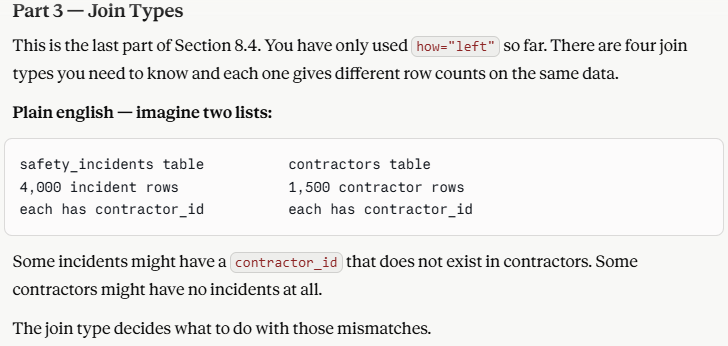

In [47]:
# Load a fresh small sample to make join types easy to see
# We will use claims and policies — claims has policy_id, policies has policy_id

policies = spark.read.jdbc(
    url=jdbc_url,
    table="policies",
    properties=jdbc_props
)

print("Claims rows:", claims.count())
print("Policies rows:", policies.count())
print("Claims columns:", claims.columns)
print("Policies columns:", policies.columns)

Claims rows: 2500
Policies rows: 600
Claims columns: ['claim_id', 'claim_number', 'policy_id', 'program_id', 'project_id', 'carrier_id', 'loss_date', 'report_date', 'claim_type', 'coverage_line', 'claimant_name', 'claimant_type', 'description', 'reserves', 'incurred_loss', 'status', 'adjuster_name', 'litigation', 'subrogation_potential', 'created_at']
Policies columns: ['policy_id', 'policy_number', 'program_id', 'project_id', 'carrier_id', 'broker_id', 'policy_type', 'effective_date', 'expiration_date', 'total_insured_value', 'annual_premium', 'deductible', 'status', 'created_at']


One thing to notice before we join — both tables have a status column. Claims has status meaning claim status (Open, Closed, Reserved). Policies has status meaning policy status (Active, Expired etc.). When you join them, Spark will have two columns both named status and will get confused. We handle that by renaming before joining.

In [48]:
# Rename ambiguous columns before joining
# so Spark does not get confused by duplicate column names
policies_renamed = policies.select(
    col("policy_id"),
    col("policy_number"),
    col("policy_type"),
    col("effective_date"),
    col("expiration_date"),
    col("annual_premium"),
    col("status").alias("policy_status")
)

print("policies_renamed columns:", policies_renamed.columns)

policies_renamed columns: ['policy_id', 'policy_number', 'policy_type', 'effective_date', 'expiration_date', 'annual_premium', 'policy_status']


Good. Now all four join types back to back so you can see exactly how they differ.

**INNER JOIN — only the perfect matches**

You go through every claim sticky note and look for its matching policy sticky note. If you find a match — you pin them together and keep them. If a claim has no matching policy — you throw that claim note away. If a policy has no matching claim — you throw that policy note away.
**You keep only the pairs where both sides matched.**

**When to use it:** When you only care about records that exist on BOTH sides. You want complete information — no nulls, no gaps. Use this when missing matches mean the row is useless to you.

**LEFT JOIN —** keep everything from the left, match where possible
You keep every single claim sticky note on the left wall. For each claim, you look for its matching policy on the right wall. If you find one — great, attach the policy details. If you do not find one — you keep the claim anyway but leave the policy columns blank (null).
**The left side is the boss. It never loses rows.**

**When to use it:** When the left table is your primary subject and the right table is just adding extra information. You never want to lose a row from the left side. Missing matches on the right just mean null values — not missing rows.

**RIGHT JOIN —** keep everything from the right, match where possible
The exact mirror of left join. You keep every single policy sticky note on the right wall. For each policy, you look for matching claims on the left. If found — attach the claim details. If not found — keep the policy anyway with null claim columns.
**The right side is the boss this time.**

**When to use it:** Honestly — almost never in practice. Any right join can be rewritten as a left join by swapping the table order. Most engineers just flip the tables and use left join because it reads more naturally — the primary subject is always on the left.

**ANTI JOIN — find the orphans**
You go through every claim sticky note and look for its matching policy. But this time you only keep the claims that have NO match. You are specifically hunting for the mismatches.
**You keep only the rows that failed to match.**

**When to use it:** Data quality checks. Finding records that should have a match but do not. Finding customers with no orders. Finding contractors with no enrollments. Finding claims with no policies — which would be a serious data integrity problem.

In [49]:
# INNER JOIN — only rows where policy_id exists in BOTH tables
inner = claims.join(policies_renamed, on="policy_id", how="inner")
print("Inner Join rows", inner.count())

# LEFT JOIN — all claims, matched policy info where available, null where not
left = claims.join(policies_renamed, on="policy_id", how="left")
print("Left Join rows", left.count())

# RIGHT JOIN — all policies, matched claims where available, null where not
right = claims.join(policies_renamed, on="policy_id", how="right")
print("Right join rows:", right.count())

# ANTI JOIN — claims that have NO matching policy at all
anti = claims.join(policies_renamed, on="policy_id", how="left_anti")
print("Anti join rows:", anti.count())

Inner Join rows 2500
Left Join rows 2500
Right join rows: 2507
Anti join rows: 0


# ── SECTION 8.4: Broadcast Join ─────────────────────────

Plain english:
When joining a large DataFrame with a small one, copying the
small DataFrame to every executor is faster than shuffling
both sides across the network.

The small table is called the "broadcast" side.
Spark copies it once to every executor.
Each executor joins its own partition of the large table
locally — no network shuffle needed.

Rule: if one side has fewer than ~10 million rows or fits
under 200MB — broadcast it.

Perfect broadcast candidates in NovaBuild:
  carriers  — 15 rows
  brokers   — 40 rows
  sponsors  — 80 rows

You already loaded carriers earlier in the session.
Load brokers and sponsors now.

In [50]:
# Load small lookup tables
brokers  = spark.read.jdbc(url=jdbc_url, table="brokers",  properties=jdbc_props)
sponsors = spark.read.jdbc(url=jdbc_url, table="sponsors", properties=jdbc_props)

print("carriers rows:", carriers.count())
print("brokers rows: ", brokers.count())
print("sponsors rows:", sponsors.count())

carriers rows: 15
brokers rows:  40
sponsors rows: 80


**Cell 2 — Regular join vs Broadcast join, side by side**

Regular join vs Broadcast join — same result, different execution.

Regular join: Spark shuffles both sides across executors.
Broadcast join: Spark copies the small table to every executor.
               Large table never moves. No shuffle.

F.broadcast(small_df) — tells Spark to broadcast this DataFrame.
That is the only change in the code. Everything else is identical.

In [51]:
import time

# ── Regular join ─────────────────────────────────────────────
start = time.time()

regular = claims.join(carriers, on="carrier_id", how="left")
regular_count = regular.count()

regular_time = f"{time.time() - start:.2f}"

print(f"Regular join  — rows: {regular_count}, time: {regular_time}s")

# ── Broadcast join ────────────────────────────────────────────
start = time.time()

broadcast = claims.join(
    F.broadcast(carriers),
    on="carrier_id",
    how="left"
)
broadcast_count = broadcast.count()

broadcast_time = f"{time.time() - start:.2f}"
print(f"Broadcast join — rows: {broadcast_count}, time: {broadcast_time}s")

Regular join  — rows: 2500, time: 0.63s
Broadcast join — rows: 2500, time: 0.75s


**Cell 3 — Verify broadcast join worked using .explain()**

.explain() — prints the physical execution plan Spark will use.

This is how you verify a broadcast join actually happened.
You saw the execution plan visually in the Spark UI earlier.
.explain() gives you the same information as text in your notebook.

What to look for:
  BroadcastHashJoin   → broadcast join used. No shuffle. Good.
  SortMergeJoin       → shuffle join used. Expensive.
  BroadcastExchange   → the step where small table was copied

If you see BroadcastHashJoin — your broadcast worked.
If you see SortMergeJoin — Spark ignored your broadcast hint
and shuffled anyway (rare, happens when data is too large).

In [52]:
print("=" * 60)
print("REGULAR JOIN PLAN:")
print("=" * 60)
regular.explain()

print("\n")
print("=" * 60)
print("BROADCAST JOIN PLAN:")
print("=" * 60)
broadcast.explain()

REGULAR JOIN PLAN:
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [carrier_id#49, claim_id#44, claim_number#45, policy_id#46, program_id#47, project_id#48, loss_date#50, report_date#51, claim_type#52, coverage_line#53, claimant_name#54, claimant_type#55, description#56, reserves#57, incurred_loss#58, status#59, adjuster_name#60, litigation#61, subrogation_potential#62, created_at#63, carrier_name#562, am_best_rating#563, state_licensed#564, contact_name#565, contact_email#566, ... 2 more fields]
   +- SortMergeJoin [carrier_id#49], [carrier_id#561], LeftOuter
      :- Sort [carrier_id#49 ASC NULLS FIRST], false, 0
      :  +- Exchange hashpartitioning(carrier_id#49, 200), ENSURE_REQUIREMENTS, [plan_id=2647]
      :     +- Scan JDBCRelation(claims) [numPartitions=1] [claim_id#44,claim_number#45,policy_id#46,program_id#47,project_id#48,carrier_id#49,loss_date#50,report_date#51,claim_type#52,coverage_line#53,claimant_name#54,claimant_type#55,description#56,reserves#57,

── BROADCAST JOIN SUMMARY ───────────────────────────────────

What it is:
  Copy the small DataFrame to every executor once.
  Each executor joins its partition of the large DataFrame
  locally — no network shuffle needed.

When to use:
  One side of the join is small — under ~10M rows or 200MB.
  NovaBuild candidates: carriers(15), brokers(40), sponsors(80)

Syntax:
  large_df.join(F.broadcast(small_df), on="key", how="left")
  Only change from a regular join: wrap small_df in F.broadcast()

How to verify it worked:
  df.explain() — look for BroadcastHashJoin in the plan
  Regular join shows: SortMergeJoin + Exchange (shuffle)
  Broadcast join shows: BroadcastHashJoin + BroadcastExchange

What you saw in NovaBuild:
  Regular join:   SortMergeJoin — both claims and carriers shuffled
  Broadcast join: BroadcastHashJoin — carriers copied, claims stayed
  Result: broadcast join was ~2x faster even on 2,500 rows
  On millions of rows the difference is 10-100x

Production habit:
  Every time you join a fact table with a dimension table,
  ask yourself: is this dimension small enough to broadcast?
  carriers, brokers, sponsors, states, lookup tables → always broadcast
  claims, safety_incidents, certificates → never broadcast (too large)

# ── SECTION 8.4: Window Functions ───────────────────────

Plain english:

You know groupBy — it collapses 4,000 rows into a few summary rows.
Window functions are different. They calculate something across a
group of related rows BUT keep every row intact. No collapsing.

Example:
  groupBy("tier").agg(avg("emr"))
  → 4 rows. One per tier. Individual contractors gone.

  row_number().over(Window.partitionBy("tier").orderBy("emr"))
  → 1,500 rows. Every contractor stays.
    Each row gets a new column: its rank within its tier.

Three things every window function needs:
  1. PARTITION BY — defines the groups (like GROUP BY but no collapse)
  2. ORDER BY     — how to sort rows within each group
  3. The function — row_number, rank, dense_rank, lag, lead

Four ranking functions:
  ROW_NUMBER  — always unique. Ties broken arbitrarily. 1,2,3,4,5
  RANK        — ties get same rank. Skips numbers.    1,2,2,4,5
  DENSE_RANK  — ties get same rank. No skipping.      1,2,2,3,4
  LAG/LEAD    — value from previous/next row

In [53]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

print("Window functions ready.")



Window functions ready.


ROW_NUMBER — assign a unique sequential number to each row
within a group, ordered by a column.

Business question:
Within each contractor tier, rank every contractor by their
EMR score. Highest EMR = rank 1 (most risky).

Use case: find the top N riskiest contractors per tier.
An underwriter uses this to flag the worst contractor in
each tier for review before policy renewal.

In [54]:
# Step 1 — define the window
# partitionBy("tier")  = one group per tier
# orderBy emr desc     = highest EMR gets rank 1

window_by_tier = Window\
  .partitionBy("tier")\
  .orderBy(F.col("emr").desc())

# Step 2 — apply row_number over that window

contractors_ranked = contractors.withColumn(
    "rank_in_tier",
    F.row_number().over(window_by_tier)
)

# Step 3 — show result
contractors_ranked.select(
    "company_name",
    "tier",
    "emr",
    "rank_in_tier"
).orderBy("tier", "rank_in_tier").show(20)

+--------------------+-----------+----+------------+
|        company_name|       tier| emr|rank_in_tier|
+--------------------+-----------+----+------------+
|Premier Landscapi...|Conditional|2.00|           1|
|Summit Steel Buil...|Conditional|1.99|           2|
|American Electric...|Conditional|1.99|           3|
|Premier Glass Con...|Conditional|1.99|           4|
|Heritage Plumbing...|Conditional|1.99|           5|
|Global Roofing Pr...|Conditional|1.98|           6|
|Central HVAC Proj...|Conditional|1.98|           7|
|National Roofing ...|Conditional|1.97|           8|
|Global HVAC Const...|Conditional|1.97|           9|
|Heritage Masonry ...|Conditional|1.97|          10|
|Global Roofing Bu...|Conditional|1.97|          11|
|Pacific General C...|Conditional|1.97|          12|
|Summit Demolition...|Conditional|1.96|          13|
|Allied Landscapin...|Conditional|1.95|          14|
|Pacific Elevator ...|Conditional|1.95|          15|
|National Concrete...|Conditional|1.94|       

**Cell 3 — ROW_NUMBER vs RANK vs DENSE_RANK side by side**

Comparing all three ranking functions on the same data.

ROW_NUMBER  — always unique. Ties broken arbitrarily.
              Use when: you need exactly N rows (top 3 per tier)

RANK        — ties get same rank. Skips numbers after a tie.
              Use when: ties matter, Olympic style ranking.
              Example: two EMR 1.99 both get rank 2, next gets rank 4.

DENSE_RANK  — ties get same rank. Does NOT skip numbers.
              Use when: ties matter but you want no gaps in sequence.
              Example: two EMR 1.99 both get rank 2, next gets rank 3.

Best way to understand the difference: see all three on the same
group of contractors where EMR values are identical.

In [55]:
# Same window — partitioned by tier, ordered by emr descending

window_compare = Window\
  .partitionBy("tier")\
  .orderBy(F.col("emr").desc())

# Apply all three ranking functions in one withColumn chain

contractors_compared = contractors\
  .withColumn("row_number", F.row_number().over(window_compare))\
  .withColumn("rank", F.rank().over(window_compare))\
  .withColumn("dense_rank", F.dense_rank().over(window_compare))

# Filter to Conditional tier only — it has tied EMR values (1.99)
# so the difference between the three functions is clearly visible

contractors_compared \
  .filter(F.col("tier") == "Conditional") \
  .select(
        "company_name",
        "emr",
        "row_number",
        "rank",
        "dense_rank"
  )\
  .orderBy("row_number")\
  .show(20)


+--------------------+----+----------+----+----------+
|        company_name| emr|row_number|rank|dense_rank|
+--------------------+----+----------+----+----------+
|Premier Landscapi...|2.00|         1|   1|         1|
|Summit Steel Buil...|1.99|         2|   2|         2|
|American Electric...|1.99|         3|   2|         2|
|Premier Glass Con...|1.99|         4|   2|         2|
|Heritage Plumbing...|1.99|         5|   2|         2|
|Global Roofing Pr...|1.98|         6|   6|         3|
|Central HVAC Proj...|1.98|         7|   6|         3|
|National Roofing ...|1.97|         8|   8|         4|
|Global HVAC Const...|1.97|         9|   8|         4|
|Heritage Masonry ...|1.97|        10|   8|         4|
|Global Roofing Bu...|1.97|        11|   8|         4|
|Pacific General C...|1.97|        12|   8|         4|
|Summit Demolition...|1.96|        13|  13|         5|
|Allied Landscapin...|1.95|        14|  14|         6|
|Pacific Elevator ...|1.95|        15|  14|         6|
|National 

**Cell 4 — LAG and LEAD**

LAG and LEAD — look backwards or forwards within a window.

LAG  — for each row, give me the value from the PREVIOUS row.
LEAD — for each row, give me the value from the NEXT row.

Plain english:
Imagine your claims sorted by loss_date within each claim_type.
LAG lets each row see the previous claim's incurred_loss.
You can then calculate: how much did loss change from last claim?

Real use cases:
  - Compare this month's loss to last month's
  - Find claims where loss jumped dramatically from previous claim
  - Calculate day-over-day or period-over-period changes

First row in each partition has no previous row → LAG returns null.
Last row in each partition has no next row → LEAD returns null.


In [56]:
# Window: partition by claim_type, ordered by loss_date ascending
# Each claim_type group is sorted oldest to newest

window_by_date = Window\
  .partitionBy("claim_type")\
  .orderBy("loss_date")

# Apply LAG and LEAD
claims_with_lag_lead = claims\
  .withColumn(
      "prev_loss",
      F.lag("incurred_loss").over(window_by_date)
  )\
  .withColumn(
      "next_loss",
      F.lead("incurred_loss").over(window_by_date)
  )\
  .withColumn(
      "loss_change_from_prev",
      F.round(F.col("next_loss") - F.col("prev_loss"), 2)
  )

# Show result — filter to one claim_type so output is readable
claims_with_lag_lead \
  .filter(F.col("claim_type") == "Bodily Injury")\
  .select(
       "claim_id",
        "loss_date",
        "incurred_loss",
        "prev_loss",
        "next_loss",
        "loss_change_from_prev"
    ) \
    .orderBy("loss_date") \
    .show(10)

+---------+----------+-------------+----------+----------+---------------------+
| claim_id| loss_date|incurred_loss| prev_loss| next_loss|loss_change_from_prev|
+---------+----------+-------------+----------+----------+---------------------+
|CLM-01925|2020-12-28|    175639.60|      NULL|1291901.49|                 NULL|
|CLM-01666|2021-01-10|   1291901.49| 175639.60|1981510.36|           1805870.76|
|CLM-02219|2021-02-03|   1981510.36|1291901.49| 508877.26|           -783024.23|
|CLM-00498|2021-03-31|    508877.26|1981510.36|1898901.70|            -82608.66|
|CLM-01975|2021-04-22|   1898901.70| 508877.26| 492621.63|            -16255.63|
|CLM-00785|2021-05-05|    492621.63|1898901.70| 160297.91|          -1738603.79|
|CLM-00262|2021-05-07|    160297.91| 492621.63| 254830.29|           -237791.34|
|CLM-01124|2021-05-23|    254830.29| 160297.91|1381734.01|           1221436.10|
|CLM-01000|2021-06-08|   1381734.01| 254830.29| 385482.07|            130651.78|
|CLM-01532|2021-06-26|    38

**Cell 5 — Running Total**

Running Total — cumulative sum that grows with each row.

Plain english:
Instead of collapsing rows like groupBy, a running total
adds a new column showing the cumulative sum up to and
including each row.

Example on claims ordered by loss_date:
  Row 1: loss=175,000  cumulative=175,000
  Row 2: loss=1,291,000  cumulative=1,466,000
  Row 3: loss=1,981,000  cumulative=3,447,000

Real use cases:
  - Year to date cumulative loss
  - Running total of premiums collected
  - Progressive budget consumption

The key difference from other window functions:
  You need to define a FRAME — how many rows to include
  in the calculation for each row.

  Window.unboundedPreceding = from the very first row
  Window.currentRow         = up to and including this row

  Together they mean: sum everything from start to here.

In [57]:
# Window: ordered by loss_date, no partition
# No partitionBy = entire DataFrame is one window
# rowsBetween defines the frame: first row to current row

window_running = Window \
  .orderBy("loss_date")\
  .rowsBetween(Window.unboundedPreceding, Window.currentRow)

#Apply Runnig Total
claims_running = claims.withColumn(
    "cumulative_loss",
    F.round(F.sum("incurred_loss").over(window_running), 2)
)

claims_running.select(
    "claim_id",
    "loss_date",
    "incurred_loss",
    "cumulative_loss"
).orderBy("loss_date").show(10)

+---------+----------+-------------+---------------+
| claim_id| loss_date|incurred_loss|cumulative_loss|
+---------+----------+-------------+---------------+
|CLM-01925|2020-12-28|    175639.60|      175639.60|
|CLM-01666|2021-01-10|   1291901.49|     1467541.09|
|CLM-02110|2021-01-23|    676250.59|     2143791.68|
|CLM-02219|2021-02-03|   1981510.36|     4125302.04|
|CLM-00635|2021-03-03|    606750.42|     4732052.46|
|CLM-02250|2021-03-08|     99917.85|     4831970.31|
|CLM-02280|2021-03-10|    867985.99|     5699956.30|
|CLM-00893|2021-03-13|    253065.07|     5953021.37|
|CLM-00630|2021-03-21|    209286.79|     6162308.16|
|CLM-00372|2021-03-22|    443513.73|     6605821.89|
+---------+----------+-------------+---------------+
only showing top 10 rows


**Cell 6 — Filter top N per group using ROW_NUMBER**

Most common real use of window functions in production:
Get the top N rows per group.

In SQL you would use a subquery with WHERE rank <= 3.
In Spark you do the same — apply row_number, then filter.

Business question:
Find the 3 riskiest contractors in each tier.
These are the contractors an underwriter reviews first
before renewing the wrap program for next year.

This cannot be done with groupBy — groupBy collapses rows.
Window function keeps all rows so you can filter after ranking.

In [58]:
# Step 1 — define window and apply row_number

window_tier = Window \
  .partitionBy("tier")\
  .orderBy(F.col("emr").desc())

contractors_ranked = contractors.withColumn(
    "rank_in_tier",
    F.row_number().over(window_tier)
)

# Step 2 — filter to top 3 per tier
top3_per_tier = contractors_ranked.filter(
    F.col("rank_in_tier") <= 3
)
# Step 3 — show result ordered by tier and rank
top3_per_tier.select(
    "tier",
    "rank_in_tier",
    "company_name",
    "emr"
).orderBy("tier", "rank_in_tier").show()

+------------+------------+--------------------+----+
|        tier|rank_in_tier|        company_name| emr|
+------------+------------+--------------------+----+
| Conditional|           1|Premier Landscapi...|2.00|
| Conditional|           2|Summit Steel Buil...|1.99|
| Conditional|           3|American Electric...|1.99|
|   Preferred|           1|National Glass De...|2.00|
|   Preferred|           2|Heritage Demoliti...|1.99|
|   Preferred|           3|Central Plumbing ...|1.99|
|Probationary|           1|United Demolition...|2.00|
|Probationary|           2|Central Steel Bui...|1.99|
|Probationary|           3|Premier Plumbing ...|1.99|
|    Standard|           1|National Painting...|2.00|
|    Standard|           2|Central Elevator ...|1.99|
|    Standard|           3|Premier Plumbing ...|1.99|
+------------+------------+--------------------+----+



── WINDOW FUNCTIONS SUMMARY ─────────────────────────────────

Key difference from groupBy:
  groupBy   → collapses rows into summary. 1,500 rows → 4 rows.
  window fn → keeps all rows, adds a new calculated column.
              1,500 rows stays 1,500 rows.

Three things every window function needs:
  1. partitionBy — defines groups (no collapse)
  2. orderBy     — sort within each group
  3. .over(window) — connects function to the window

Four ranking functions:
  row_number()  — always unique. 1,2,3,4,5
                  Use for: top N per group
  rank()        — ties same rank, skips after. 1,2,2,4,5
                  Use for: Olympic style ranking
  dense_rank()  — ties same rank, no skip. 1,2,2,3,4
                  Use for: leaderboards, no gaps needed

LAG and LEAD:
  lag("col", 1)  — value from previous row. Null for first row.
                   Use for: period over period comparison
  lead("col", 1) — value from next row. Null for last row.
                   Use for: look ahead comparisons

Running Total:
  Window.rowsBetween(Window.unboundedPreceding, Window.currentRow)
  F.sum("col").over(window)
  Use for: YTD totals, cumulative metrics

Production pattern — top N per group:
  Step 1: rank with row_number().over(window)
  Step 2: filter where rank <= N
  Cannot do this with groupBy — window function required.
"""

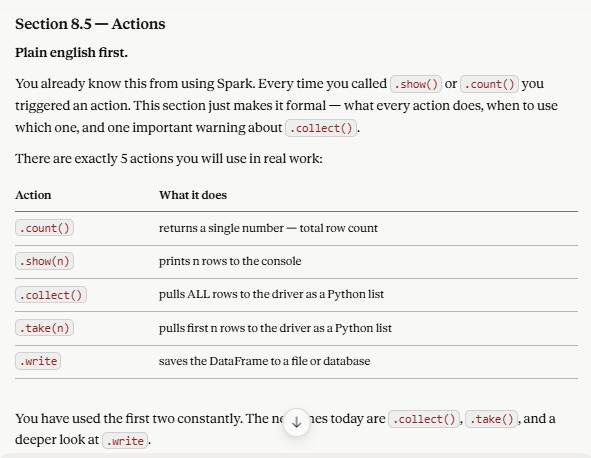

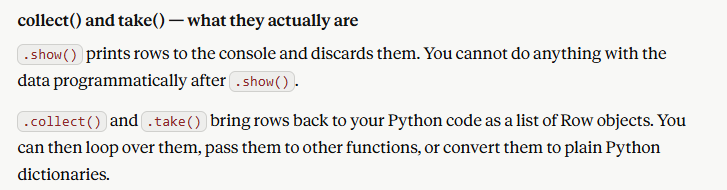

In [59]:
# take() — bring first 3 rows to Python as a list
sample = claims.take(3)

print(type(sample))        # Python list
print(type(sample[0]))     # Spark Row object
print(sample[0])           # the full row
print(sample[0]["claim_id"])   # access a specific column
print(sample[0]["incurred_loss"])

<class 'list'>
<class 'pyspark.sql.types.Row'>
Row(claim_id='CLM-00001', claim_number='CLM-68960689', policy_id='POL-00489', program_id='WRP-00081', project_id='PRJ-00081', carrier_id='CAR-00004', loss_date=datetime.date(2022, 11, 20), report_date=datetime.date(2022, 12, 15), claim_type='Workers Comp', coverage_line='Excess Liability', claimant_name='Thomas Jackson', claimant_type='Employee', description='Property Damage claim from Electrical', reserves=Decimal('307619.74'), incurred_loss=Decimal('120752.80'), status='Open', adjuster_name='Lisa Johnson', litigation=False, subrogation_potential=False, created_at=datetime.date(2022, 12, 15))
CLM-00001
120752.80


In [60]:
# collect() — brings EVERY row to the driver
all_claims = claims.collect()

print(f"Type: {type(all_claims)}")
print(f"Row count: {len(all_claims)}")
print(f"First claim_id: {all_claims[0]['claim_id']}")
print(f"First incurred_loss: {all_claims[0]['incurred_loss']}")

Type: <class 'list'>
Row count: 2500
First claim_id: CLM-00001
First incurred_loss: 120752.80


In [61]:
# This does NOTHING — just a plan
filtered = claims.filter(claims["status"] == "Open")

# This ALSO does nothing — still just a plan
grouped = filtered.groupBy("claim_type").count()

# THIS triggers everything — Spark now actually runs both steps above
grouped.show()

+--------------------+-----+
|          claim_type|count|
+--------------------+-----+
|Third Party Liabi...|  103|
|      Fire/Explosion|  131|
|     Property Damage|  102|
|     Equipment Theft|  105|
|        Workers Comp|  115|
|       Bodily Injury|  119|
|        Water Damage|  105|
+--------------------+-----+



**Confirm .take() makes sense:**

In [62]:
# Bring 3 open claims into Python as a list
open_claims = claims.filter(claims["status"] == "Open").take(5)

# Loop over them like a normal Python list
for row in open_claims:
    print(f"{row['claim_id']} | {row['claim_type']} | ${row['incurred_loss']}")

CLM-00001 | Workers Comp | $120752.80
CLM-00002 | Water Damage | $1096690.44
CLM-00005 | Bodily Injury | $442918.90
CLM-00009 | Equipment Theft | $1043447.44
CLM-00010 | Workers Comp | $274108.61


**Confirm .write makes sense:**

In [63]:
from ast import alias
from pyspark.sql import functions as F

# Summarise open claims by type
open_summary = claims \
  .filter(claims['status'] == "Open")\
  .groupBy("claim_type")\
  .agg(
      F.count("claim_id").alias("open_count"),
      F.round(F.sum("incurred_loss"), 2).alias("total_open_loss")
    )

# Save to Parquet
open_summary.write\
  .mode("overwrite")\
  .parquet("/content/novabuild_parquet/open_claims_summary")
print("Saved.")

Saved.


In [64]:
spark.read.parquet("/content/novabuild_parquet/open_claims_summary").show()

+--------------------+----------+---------------+
|          claim_type|open_count|total_open_loss|
+--------------------+----------+---------------+
|Third Party Liabi...|       103|    74470228.83|
|      Fire/Explosion|       131|    89122513.39|
|     Property Damage|       102|    76005132.32|
|     Equipment Theft|       105|    86734922.81|
|        Workers Comp|       115|    93802571.98|
|       Bodily Injury|       119|    84489229.42|
|        Water Damage|       105|    84828224.70|
+--------------------+----------+---------------+



# ── SECTION 8.6: Spark SQL ───────────────────────

Plain english first.

Everything you did in Module 4 SQL — SELECT, WHERE, GROUP BY, JOIN, CTEs, window functions — you can write word for word in Spark using spark.sql().
The only extra step before you can do that — you need to register your DataFrames as temporary views. A temp view is just a name that Spark SQL can reference. Think of it like telling Spark — "from now on, when I write FROM claims in SQL, I mean this DataFrame."

After that, you write normal SQL. Spark executes it and returns a DataFrame.
Why use Spark SQL instead of the DataFrame API?
Both produce identical execution plans — the optimizer sees them exactly the same way. Performance is equal. The choice is readability:

Complex multi-table joins with CTEs → SQL is cleaner
Simple column transformations → DataFrame API is cleaner
Your SQL team can contribute without learning PySpark → SQL
You already know SQL from Module 4 → SQL feels natural

In real work you use both. You will see both in every production codebase.

Plain english:
Spark SQL lets you write standard SQL against your Spark
DataFrames. The only setup step: register each DataFrame
as a temporary view so Spark SQL knows what name to use.

createOrReplaceTempView("name"):
  Registers the DataFrame as a view called "name".
  Only exists for the current session — if you restart
  Colab, you need to re-register.
  "OrReplace" — if the view already exists, replace it.
  No error if you re-run the cell.

After registering, you use the view name in SQL exactly
like a table name in PostgreSQL.

In [65]:
# Register all loaded DataFrames as temp views
claims.createOrReplaceTempView("claims")
contractors.createOrReplaceTempView("contractors")
safety_incidents.createOrReplaceTempView("safety_incidents")
certificates.createOrReplaceTempView("certificates")
policies.createOrReplaceTempView("policies")
carriers.createOrReplaceTempView("carriers")
brokers.createOrReplaceTempView("brokers")
sponsors.createOrReplaceTempView("sponsors")

# Verify all views are registered
print("Registered views:")
for table in spark.catalog.listTables():
    print(f"  {table.name:<30} isTemporary: {table.isTemporary}")

Registered views:
  brokers                        isTemporary: True
  carriers                       isTemporary: True
  certificates                   isTemporary: True
  claims                         isTemporary: True
  contractors                    isTemporary: True
  policies                       isTemporary: True
  safety_incidents               isTemporary: True
  sponsors                       isTemporary: True


Line by line:

claims.createOrReplaceTempView("claims") — registers the claims DataFrame as a view named "claims". From now on SELECT * FROM claims in any spark.sql() call refers to this DataFrame.

spark.catalog.listTables() — lists all registered views in the current session. spark.catalog is Spark's metadata manager — it knows about all registered views, databases, and tables.

table.name — the view name. table.isTemporary — True for temp views (session only), False for permanent tables registered in a database.

**Cell 2 — Basic SELECT, WHERE, ORDER BY, LIMIT**

Basic SQL queries in Spark — identical syntax to PostgreSQL.
spark.sql() takes a SQL string and returns a Spark DataFrame.
You can chain any DataFrame operation on the result.

In [66]:
# Q1: Top 10 claims by incurred loss

spark.sql("""
  SELECT
    claim_id,
    claim_type,
    incurred_loss,
    status
  FROM claims
  ORDER BY incurred_loss DESC
  LIMIT 10

""").show()

# Q2: Open claims above 500,000
spark.sql("""
    SELECT
        claim_id,
        claim_type,
        incurred_loss,
        status
    FROM claims
    WHERE status = 'Open'
      AND incurred_loss > 500000.00
    ORDER BY incurred_loss DESC
""").show(10)

# Q3: Claims filed in 2023

spark.sql("""
  SELECT
    claim_id,
    claim_type,
    incurred_loss
  FROM claims
  WHERE YEAR(loss_date) = 2023
  ORDER BY loss_date DESC
  LIMIT 10

""").show()

+---------+--------------------+-------------+---------+
| claim_id|          claim_type|incurred_loss|   status|
+---------+--------------------+-------------+---------+
|CLM-00949|     Property Damage|   2297610.10|Litigated|
|CLM-00693|      Fire/Explosion|   2273950.55|   Denied|
|CLM-00878|     Property Damage|   2268240.43|     Open|
|CLM-02213|        Water Damage|   2268072.21|   Closed|
|CLM-00121|        Workers Comp|   2260772.97|     Open|
|CLM-01978|      Fire/Explosion|   2258152.58|   Closed|
|CLM-00617|Third Party Liabi...|   2228884.91| Reserved|
|CLM-00436|     Property Damage|   2185756.63|     Open|
|CLM-00618|     Equipment Theft|   2185463.01| Reserved|
|CLM-00718|Third Party Liabi...|   2172063.71|   Closed|
+---------+--------------------+-------------+---------+

+---------+---------------+-------------+------+
| claim_id|     claim_type|incurred_loss|status|
+---------+---------------+-------------+------+
|CLM-00878|Property Damage|   2268240.43|  Open|
|CLM-

Line by line:

spark.sql(""" ... """) — triple quoted string lets you write multi-line SQL cleanly. Spark parses and executes it. Returns a DataFrame.

ORDER BY incurred_loss DESC — identical to PostgreSQL. Descending order.
LIMIT 10 — identical to PostgreSQL. Return only first 10 rows.

WHERE status = 'Open' AND incurred_loss > 500000 — multiple conditions with AND. Single quotes for string values — same as PostgreSQL.

YEAR(loss_date) — Spark SQL has the same date functions as PostgreSQL. YEAR(), MONTH(), DAY(), DATEDIFF(), DATE_ADD() all work identically.
.show(10) — action on the returned DataFrame. Prints 10 rows.

In [67]:
# Check what status values exist in claims
spark.sql("""
    SELECT DISTINCT status, COUNT(*) as count
    FROM claims
    GROUP BY status
    ORDER BY count DESC
""").show()

+---------+-----+
|   status|count|
+---------+-----+
|   Closed| 1101|
|     Open|  780|
| Reserved|  317|
|Litigated|  194|
|   Denied|  108|
+---------+-----+



In [68]:
# Check how many Open claims exist above 500,000
spark.sql("""
    SELECT COUNT(*) as count,
           MIN(incurred_loss) as min_loss,
           MAX(incurred_loss) as max_loss
    FROM claims
    WHERE status = 'Open'
""").show()

+-----+--------+----------+
|count|min_loss|  max_loss|
+-----+--------+----------+
|  780| 2469.71|2268240.43|
+-----+--------+----------+



**Cell 3 — GROUP BY, HAVING, aggregate functions**


GROUP BY and HAVING in Spark SQL — identical to PostgreSQL.

HAVING filters groups after aggregation.

WHERE filters rows before aggregation.

In [69]:
# Q4: Total and average loss by claim type

spark.sql("""
  SELECT
    claim_type,
    COUNT(*) AS claim_count,
    ROUND(SUM(incurred_loss), 2) AS total_loss,
    ROUND(AVG(incurred_loss), 2) AS avg_loss,
    ROUND(MIN(incurred_loss), 2) AS min_loss,
    ROUND(MAX(incurred_loss), 2) AS max_losss
  FROM claims
  GROUP BY claim_type
  ORDER BY total_loss DESC


""").show()


# Q5: Claim types where average loss exceeds 750,000
# HAVING filters after grouping — WHERE cannot do this

spark.sql("""
    SELECT
        claim_type,
        COUNT(*)                        AS claim_count,
        ROUND(AVG(incurred_loss), 2)    AS avg_loss
    FROM claims
    GROUP BY claim_type
    HAVING AVG(incurred_loss) > 750000.00
    ORDER BY avg_loss DESC
""").show()
# Q6: Contractor tier summary — count, avg EMR, avg years in business
spark.sql("""
    SELECT
        tier,
        COUNT(*)                            AS contractor_count,
        ROUND(AVG(emr), 2)                  AS avg_emr,
        ROUND(AVG(years_in_business), 1)    AS avg_years
    FROM contractors
    GROUP BY tier
    ORDER BY avg_emr DESC
""").show()

+--------------------+-----------+------------+---------+--------+----------+
|          claim_type|claim_count|  total_loss| avg_loss|min_loss| max_losss|
+--------------------+-----------+------------+---------+--------+----------+
|       Bodily Injury|        393|296442492.80|754306.60| 4347.34|2095938.26|
|      Fire/Explosion|        369|281560104.53|763035.51| 9054.78|2273950.55|
|        Water Damage|        348|275881241.47|792762.19| 2469.71|2268072.21|
|     Equipment Theft|        355|272433399.35|767418.03| 2794.51|2185463.01|
|     Property Damage|        354|269512867.70|761335.78| 2483.52|2297610.10|
|        Workers Comp|        343|265971706.02|775427.71|11525.63|2260772.97|
|Third Party Liabi...|        338|249287909.74|737538.19|17298.19|2228884.91|
+--------------------+-----------+------------+---------+--------+----------+

+---------------+-----------+---------+
|     claim_type|claim_count| avg_loss|
+---------------+-----------+---------+
|   Water Damage|    

**Cell 4 — JOINs in Spark SQL**

JOINs in Spark SQL — identical syntax to PostgreSQL.
INNER JOIN, LEFT JOIN, RIGHT JOIN all work the same way.

One important habit in Spark SQL:
Always alias your tables when joining — col names can clash.
Use table_alias.column_name to be explicit.

In [70]:
# Q7: Claims with carrier name — INNER JOIN
spark.sql("""
    SELECT
        cl.claim_id,
        cl.claim_type,
        cl.incurred_loss,
        ca.carrier_name,
        ca.am_best_rating
    FROM claims cl
    INNER JOIN carriers ca ON cl.carrier_id = ca.carrier_id
    ORDER BY cl.incurred_loss DESC
    LIMIT 10
""").show()

# Q8: All claims with policy details — LEFT JOIN
# Left join keeps all claims even if no matching policy
spark.sql("""
    SELECT
        cl.claim_id,
        cl.claim_type,
        cl.incurred_loss,
        pol.policy_number,
        pol.policy_type,
        pol.status AS policy_status
    FROM claims cl
    LEFT JOIN policies pol ON cl.policy_id = pol.policy_id
    ORDER BY cl.incurred_loss DESC
    LIMIT 10
""").show()

"""
JOINs in Spark SQL — identical syntax to PostgreSQL.
INNER JOIN, LEFT JOIN, RIGHT JOIN all work the same way.

One important habit in Spark SQL:
Always alias your tables when joining — col names can clash.
Use table_alias.column_name to be explicit.
"""

# Q7: Claims with carrier name — INNER JOIN
spark.sql("""
    SELECT
        cl.claim_id,
        cl.claim_type,
        cl.incurred_loss,
        ca.carrier_name,
        ca.am_best_rating
    FROM claims cl
    INNER JOIN carriers ca ON cl.carrier_id = ca.carrier_id
    ORDER BY cl.incurred_loss DESC
    LIMIT 10
""").show()

# Q8: All claims with policy details — LEFT JOIN
# Left join keeps all claims even if no matching policy
spark.sql("""
    SELECT
        cl.claim_id,
        cl.claim_type,
        cl.incurred_loss,
        pol.policy_number,
        pol.policy_type,
        pol.status AS policy_status
    FROM claims cl
    LEFT JOIN policies pol ON cl.policy_id = pol.policy_id
    ORDER BY cl.incurred_loss DESC
    LIMIT 10
""").show()

# Q9: Three table join — claims + carriers + policies
spark.sql("""
    SELECT
        cl.claim_id,
        cl.claim_type,
        ROUND(cl.incurred_loss, 2)  AS incurred_loss,
        ca.carrier_name,
        pol.policy_type,
        pol.status                  AS policy_status
    FROM claims cl
    LEFT JOIN carriers ca  ON cl.carrier_id = ca.carrier_id
    LEFT JOIN policies pol ON cl.policy_id  = pol.policy_id
    ORDER BY cl.incurred_loss DESC
    LIMIT 10
""").show()

+---------+--------------------+-------------+--------------------+--------------+
| claim_id|          claim_type|incurred_loss|        carrier_name|am_best_rating|
+---------+--------------------+-------------+--------------------+--------------+
|CLM-00949|     Property Damage|   2297610.10|  Markel Corporation|             A|
|CLM-00693|      Fire/Explosion|   2273950.55|Berkshire Hathawa...|            A+|
|CLM-00878|     Property Damage|   2268240.43|Berkshire Hathawa...|            A+|
|CLM-02213|        Water Damage|   2268072.21|Cincinnati Financial|            A-|
|CLM-00121|        Workers Comp|   2260772.97|      Liberty Mutual|            B+|
|CLM-01978|      Fire/Explosion|   2258152.58|Berkshire Hathawa...|            A+|
|CLM-00617|Third Party Liabi...|   2228884.91|Zurich North America|           A++|
|CLM-00436|     Property Damage|   2185756.63|Berkshire Hathawa...|            A+|
|CLM-00618|     Equipment Theft|   2185463.01|      Liberty Mutual|            B+|
|CLM

**Cell 5 — Subqueries**

Subqueries in Spark SQL — identical to PostgreSQL.
A subquery is a SELECT inside another SELECT.
Used when you need to filter based on an aggregated value
that you cannot reference directly in WHERE.

Two types:
  1. Subquery in WHERE — filter using a calculated value
  2. Subquery in FROM — treat a query result as a table

In [71]:
# Q10: Claims above the average incurred loss
# Cannot write WHERE incurred_loss > AVG(incurred_loss) directly
# AVG is an aggregate — needs a subquery

spark.sql("""
  SELECT
    claim_id,
    claim_type,
    incurred_loss,
    status
  FROM claims
  WHERE incurred_loss > (
    SELECT
      AVG(incurred_loss)
    FROM claims
  )
  ORDER BY incurred_loss DESC
  LIMIT 10

""").show()

# Q11: Contractors with more than average number of incidents

spark.sql("""
    SELECT
        con.company_name,
        con.tier,
        con.emr,
        COUNT(si.incident_id) AS total_incidents
    FROM contractors con
    JOIN safety_incidents si ON con.contractor_id = si.contractor_id
    GROUP BY con.company_name, con.tier, con.emr, con.contractor_id
    HAVING COUNT(si.incident_id) > (
        SELECT AVG(incident_count)
        FROM (
            SELECT COUNT(*) AS incident_count
            FROM safety_incidents
            GROUP BY contractor_id
        )
    )
    ORDER BY total_incidents DESC
    LIMIT 10
""").show()

+---------+--------------------+-------------+---------+
| claim_id|          claim_type|incurred_loss|   status|
+---------+--------------------+-------------+---------+
|CLM-00949|     Property Damage|   2297610.10|Litigated|
|CLM-00693|      Fire/Explosion|   2273950.55|   Denied|
|CLM-00878|     Property Damage|   2268240.43|     Open|
|CLM-02213|        Water Damage|   2268072.21|   Closed|
|CLM-00121|        Workers Comp|   2260772.97|     Open|
|CLM-01978|      Fire/Explosion|   2258152.58|   Closed|
|CLM-00617|Third Party Liabi...|   2228884.91| Reserved|
|CLM-00436|     Property Damage|   2185756.63|     Open|
|CLM-00618|     Equipment Theft|   2185463.01| Reserved|
|CLM-00718|Third Party Liabi...|   2172063.71|   Closed|
+---------+--------------------+-------------+---------+

+--------------------+------------+----+---------------+
|        company_name|        tier| emr|total_incidents|
+--------------------+------------+----+---------------+
|Global Concrete P...|Probatio

**Cell 6 — CTEs**

CTEs — WITH clause in Spark SQL.
Identical syntax to PostgreSQL.

A CTE gives a name to a subquery so you can reference it
like a table. Makes complex queries readable by breaking
them into named steps.

Same query as Q11 but rewritten with a CTE.
Read it top to bottom — each CTE builds on the previous one.

In [72]:
# Q12: Same as Q11 — contractors above average incidents
# Rewritten with CTE — much more readable

spark.sql("""
    WITH incident_counts AS (
      SELECT
        contractor_id,
          COUNT(*) AS total_incidents
      FROM safety_incidents
      GROUP BY contractor_id
    ),
    avg_threshold AS (
      SELECT AVG(total_incidents) AS avg_incidents
      FROM incident_counts
    )
    SELECT
      con.company_name,
      con.tier,
      con.emr,
      ic.total_incidents
    FROM contractors con
    JOIN incident_counts ic
      ON con.contractor_id = ic.contractor_id
    JOIN avg_threshold at
      ON ic.total_incidents > at.avg_incidents
    ORDER BY ic.total_incidents DESC
    LIMIT 10
""").show()

# Q13: Multi-step CTE — loss ratio analysis
# Step 1: total loss per carrier
# Step 2: total premium per carrier
# Step 3: calculate loss ratio

spark.sql(
    """
    WITH loss_by_carrier AS(
      SELECT
        carrier_id,
        COUNT(*) AS claim_count,
        ROUND(SUM(incurred_loss), 2) AS total_loss
      FROM claims
      GROUP BY carrier_id
    ),

    premium_by_carrier AS(
      SELECT
        carrier_id,
        ROUND(SUM(annual_premium), 2) AS total_premium
      FROM policies
      GROUP BY carrier_id
    )
    SELECT
      ca.carrier_name,
      lc.claim_count,
      lc.total_loss,
      pc.total_premium,
      ROUND(lc.total_loss / NULLIF(pc.total_premium, 0) * 100, 2) AS loss_ratio_pct
    FROM loss_by_carrier lc
    JOIN premium_by_carrier pc
      ON lc.carrier_id = pc.carrier_id
    JOIN carriers ca
      ON lc.carrier_id = ca.carrier_id

    ORDER BY loss_ratio_pct DESC
    """
).show()




+--------------------+------------+----+---------------+
|        company_name|        tier| emr|total_incidents|
+--------------------+------------+----+---------------+
|Global Concrete P...|Probationary|1.89|             13|
|Allied Painting I...|   Preferred|1.39|             12|
|Heritage Concrete...| Conditional|0.68|             11|
|Central Elevator ...| Conditional|0.64|             11|
|Heritage Steel Bu...|Probationary|0.71|             11|
|Heritage Electric...|Probationary|1.34|             11|
|Allied HVAC Build...|Probationary|0.81|             10|
|United Plumbing P...| Conditional|1.45|              9|
|Summit Electrical...| Conditional|1.35|              9|
|Global Glass Proj...|Probationary|0.57|              9|
+--------------------+------------+----+---------------+

+--------------------+-----------+------------+-------------+--------------+
|        carrier_name|claim_count|  total_loss|total_premium|loss_ratio_pct|
+--------------------+-----------+------------+

In [73]:
spark.sql(
    """
    WITH loss_by_carrier AS(
      SELECT
        carrier_id,
        COUNT(*) AS claim_count,
        ROUND(SUM(incurred_loss), 2) AS total_loss
      FROM claims
      GROUP BY carrier_id
    ),

    premium_by_carrier AS(
      SELECT
        carrier_id,
        ROUND(SUM(annual_premium), 2) AS total_premium
      FROM policies
      GROUP BY carrier_id
    )
    SELECT
      ca.carrier_name,
      lc.claim_count,
      lc.total_loss,
      pc.total_premium,
      ROUND(lc.total_loss / NULLIF(pc.total_premium, 0) * 100, 2) AS loss_ratio_pct
    FROM loss_by_carrier lc
    JOIN premium_by_carrier pc
      ON lc.carrier_id = pc.carrier_id
    JOIN carriers ca
      ON lc.carrier_id = ca.carrier_id

    ORDER BY loss_ratio_pct DESC
    """
).show()

+--------------------+-----------+------------+-------------+--------------+
|        carrier_name|claim_count|  total_loss|total_premium|loss_ratio_pct|
+--------------------+-----------+------------+-------------+--------------+
|Berkshire Hathawa...|        351|268090894.53| 177278555.91|        151.23|
| Westfield Insurance|        210|162912470.40| 115567169.29|        140.97|
|       Chubb Limited|        153|111449947.16|  81515277.88|        136.72|
|    AIG Construction|        119| 94279144.55|  71139436.37|        132.53|
|  Hartford Financial|        197|158543874.90| 120480708.53|        131.59|
|        Tokio Marine|        176|135003172.69| 104162494.20|        129.61|
|  Markel Corporation|         74| 61697016.26|  48431870.11|        127.39|
|Cincinnati Financial|        156|113097968.80|  88964777.35|        127.13|
|       CNA Financial|        132| 93578056.40|  75091254.58|        124.62|
|Nationwide Insurance|        217|176041385.98| 145844666.98|        120.70|

**Cell 7 — Window Functions in Spark SQL**

Window functions in Spark SQL — identical syntax to PostgreSQL.
OVER (PARTITION BY ... ORDER BY ...) works exactly the same.

This cell covers:

  ROW_NUMBER, RANK, DENSE_RANK  — ranking

  LAG, LEAD                     — look back / look forward

  NTILE                         — divide rows into N equal buckets

  Running total                 — cumulative sum

  Moving average                — average over a sliding window

NTILE is new — not covered in the DataFrame API section.

NTILE(4) divides rows into 4 equal buckets (quartiles).

NTILE(10) divides into 10 buckets (deciles).

Used for: percentile bands, risk tiers, performance buckets.

In [74]:
# Q14: ROW_NUMBER, RANK, DENSE_RANK — all three side by side
spark.sql("""
    SELECT
        company_name,
        tier,
        emr,
        ROW_NUMBER() OVER (PARTITION BY tier ORDER BY emr DESC) AS row_num,
        RANK()       OVER (PARTITION BY tier ORDER BY emr DESC) AS rank,
        DENSE_RANK() OVER (PARTITION BY tier ORDER BY emr DESC) AS dense_rank
    FROM contractors
    WHERE tier = 'Conditional'
    ORDER BY emr DESC
    LIMIT 15
""").show()

+--------------------+-----------+----+-------+----+----------+
|        company_name|       tier| emr|row_num|rank|dense_rank|
+--------------------+-----------+----+-------+----+----------+
|Premier Landscapi...|Conditional|2.00|      1|   1|         1|
|Summit Steel Buil...|Conditional|1.99|      2|   2|         2|
|American Electric...|Conditional|1.99|      3|   2|         2|
|Premier Glass Con...|Conditional|1.99|      4|   2|         2|
|Heritage Plumbing...|Conditional|1.99|      5|   2|         2|
|Global Roofing Pr...|Conditional|1.98|      6|   6|         3|
|Central HVAC Proj...|Conditional|1.98|      7|   6|         3|
|National Roofing ...|Conditional|1.97|      8|   8|         4|
|Global HVAC Const...|Conditional|1.97|      9|   8|         4|
|Heritage Masonry ...|Conditional|1.97|     10|   8|         4|
|Global Roofing Bu...|Conditional|1.97|     11|   8|         4|
|Pacific General C...|Conditional|1.97|     12|   8|         4|
|Summit Demolition...|Conditional|1.96| 

In [75]:
# Q15: NTILE — divide contractors into EMR quartiles
# NTILE(4) = 4 buckets
# Bucket 1 = lowest EMR (safest)
# Bucket 4 = highest EMR (riskiest)
spark.sql("""
    SELECT
        company_name,
        tier,
        emr,
        NTILE(4) OVER (ORDER BY emr ASC) AS emr_quartile
    FROM contractors
    ORDER BY emr ASC
    LIMIT 20
""").show()

+--------------------+------------+----+------------+
|        company_name|        tier| emr|emr_quartile|
+--------------------+------------+----+------------+
|Pacific Excavatio...|Probationary|0.50|           1|
|Heritage Demoliti...|   Preferred|0.50|           1|
|Premier Concrete ...|Probationary|0.50|           1|
|Heritage Painting...| Conditional|0.50|           1|
|American Demoliti...| Conditional|0.51|           1|
|National Masonry ...|   Preferred|0.51|           1|
|American Masonry ...|   Preferred|0.51|           1|
|American Fire Pro...|    Standard|0.51|           1|
|Pacific Electrica...|   Preferred|0.51|           1|
|Pacific General C...|Probationary|0.51|           1|
|Central Elevator ...|Probationary|0.51|           1|
|Global Painting I...| Conditional|0.51|           1|
|United HVAC Build...|Probationary|0.51|           1|
|Allied Excavation...|    Standard|0.51|           1|
|National Painting...|    Standard|0.51|           1|
|Heritage HVAC Con...|Probat

In [76]:
# Q16: NTILE with business label
spark.sql("""
    SELECT
        company_name,
        tier,
        emr,
        emr_quartile,
        CASE emr_quartile
            WHEN 1 THEN 'Low Risk'
            WHEN 2 THEN 'Medium-Low Risk'
            WHEN 3 THEN 'Medium-High Risk'
            WHEN 4 THEN 'High Risk'
        END AS risk_band
    FROM (
        SELECT
            company_name,
            tier,
            emr,
            NTILE(4) OVER (ORDER BY emr ASC) AS emr_quartile
        FROM contractors
    )
    ORDER BY emr DESC
    LIMIT 15
""").show()

+--------------------+------------+----+------------+---------+
|        company_name|        tier| emr|emr_quartile|risk_band|
+--------------------+------------+----+------------+---------+
|National Painting...|    Standard|2.00|           4|High Risk|
|United Demolition...|Probationary|2.00|           4|High Risk|
|National Glass De...|   Preferred|2.00|           4|High Risk|
|Premier Landscapi...| Conditional|2.00|           4|High Risk|
|Central Plumbing ...|   Preferred|1.99|           4|High Risk|
|Premier Glass Con...| Conditional|1.99|           4|High Risk|
|Premier Plumbing ...|Probationary|1.99|           4|High Risk|
|Heritage Plumbing...| Conditional|1.99|           4|High Risk|
|Summit Steel Buil...| Conditional|1.99|           4|High Risk|
|Summit Electrical...|   Preferred|1.99|           4|High Risk|
|American Electric...| Conditional|1.99|           4|High Risk|
|Allied General Co...|   Preferred|1.99|           4|High Risk|
|Central Steel Bui...|Probationary|1.99|

In [77]:
"""
LAG, LEAD, running total, and moving average in Spark SQL.

Moving average is new — not covered in DataFrame API section.
A moving average smooths out fluctuations by averaging
the current row and N previous rows.

Used for: trend analysis, smoothing noisy time series data.
Example: 3-claim moving average of incurred_loss shows the
trend in claim severity more clearly than raw values.

ROWS BETWEEN syntax:
  ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
  = include 2 rows before current row + current row
  = window of 3 rows total
  = 3-period moving average

ROWS BETWEEN vs RANGE BETWEEN:
  ROWS BETWEEN  — counts physical rows. Exact row positions.
                  2 PRECEDING = exactly 2 rows back.
  RANGE BETWEEN — counts logical range based on ORDER BY value.
                  2 PRECEDING = all rows where value is within
                  2 units of current row's value.
  Use ROWS BETWEEN for moving averages — always exact.
  Use RANGE BETWEEN for value-based windows (rare in practice).
"""

# Q17: LAG and LEAD — claim loss trend by claim type
spark.sql("""
    SELECT
        claim_id,
        claim_type,
        loss_date,
        incurred_loss,
        LAG(incurred_loss, 1)  OVER (
            PARTITION BY claim_type
            ORDER BY loss_date
        ) AS prev_loss,
        LEAD(incurred_loss, 1) OVER (
            PARTITION BY claim_type
            ORDER BY loss_date
        ) AS next_loss,
        ROUND(
            incurred_loss - LAG(incurred_loss, 1) OVER (
                PARTITION BY claim_type
                ORDER BY loss_date
            ), 2
        ) AS loss_change
    FROM claims
    WHERE claim_type = 'Bodily Injury'
    ORDER BY loss_date
    LIMIT 10
""").show()

# Q18: Running total of incurred loss ordered by loss_date
spark.sql("""
    SELECT
        claim_id,
        loss_date,
        incurred_loss,
        ROUND(
            SUM(incurred_loss) OVER (
                ORDER BY loss_date
                ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
            ), 2
        ) AS cumulative_loss
    FROM claims
    ORDER BY loss_date
    LIMIT 10
""").show()

# Q19: 3-claim moving average of incurred loss per claim type
# ROWS BETWEEN 2 PRECEDING AND CURRENT ROW = window of 3 rows
spark.sql("""
    SELECT
        claim_id,
        claim_type,
        loss_date,
        incurred_loss,
        ROUND(
            AVG(incurred_loss) OVER (
                PARTITION BY claim_type
                ORDER BY loss_date
                ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
            ), 2
        ) AS moving_avg_3
    FROM claims
    WHERE claim_type = 'Bodily Injury'
    ORDER BY loss_date
    LIMIT 10
""").show()

+---------+-------------+----------+-------------+----------+----------+-----------+
| claim_id|   claim_type| loss_date|incurred_loss| prev_loss| next_loss|loss_change|
+---------+-------------+----------+-------------+----------+----------+-----------+
|CLM-01925|Bodily Injury|2020-12-28|    175639.60|      NULL|1291901.49|       NULL|
|CLM-01666|Bodily Injury|2021-01-10|   1291901.49| 175639.60|1981510.36| 1116261.89|
|CLM-02219|Bodily Injury|2021-02-03|   1981510.36|1291901.49| 508877.26|  689608.87|
|CLM-00498|Bodily Injury|2021-03-31|    508877.26|1981510.36|1898901.70|-1472633.10|
|CLM-01975|Bodily Injury|2021-04-22|   1898901.70| 508877.26| 492621.63| 1390024.44|
|CLM-00785|Bodily Injury|2021-05-05|    492621.63|1898901.70| 160297.91|-1406280.07|
|CLM-00262|Bodily Injury|2021-05-07|    160297.91| 492621.63| 254830.29| -332323.72|
|CLM-01124|Bodily Injury|2021-05-23|    254830.29| 160297.91|1381734.01|   94532.38|
|CLM-01000|Bodily Injury|2021-06-08|   1381734.01| 254830.29| 385

**Line by line:**

LAG(incurred_loss, 1) OVER (PARTITION BY claim_type ORDER BY loss_date) — identical to PostgreSQL LAG syntax. Returns previous row's loss within the same claim type ordered by date.

ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW — defines the window frame for running total. UNBOUNDED PRECEDING means from the very first row. CURRENT ROW means up to here. Together: sum everything from start to this row.

ROWS BETWEEN 2 PRECEDING AND CURRENT ROW — defines a sliding window of 3 rows. For each row include itself and the 2 rows before it. The average of these 3 rows is the moving average. First row — only 1 row in window, average of 1. Second row — 2 rows in window. Third row onwards — full 3-row window.

ROWS BETWEEN vs RANGE BETWEEN — the key difference:

ROWS BETWEEN 2 PRECEDING AND CURRENT ROW — always exactly 2 physical rows back regardless of values.

RANGE BETWEEN 2 PRECEDING AND CURRENT ROW — goes back to all rows where the ORDER BY column value is within 2 units of the current row's value. If two rows have the same date, both are included.

This can give unexpected results for moving averages — use ROWS BETWEEN instead.

**Cell 9 — Store SQL result as DataFrame and write to Parquet**

spark.sql() always returns a Spark DataFrame.
You can store it in a variable and use it like any other DataFrame.
Chain transformations, write to Parquet, register as another view.

This is important in production pipelines:

  Step 1: Run SQL to build a complex aggregation

  Step 2: Store result as DataFrame
  
  Step 3: Write to Parquet or Delta for downstream consumers
"""

In [78]:
# Build loss ratio result and store as DataFrame
loss_ratio_df = spark.sql("""
    WITH loss_by_carrier AS (
        SELECT
            carrier_id,
            COUNT(*)                        AS claim_count,
            ROUND(SUM(incurred_loss), 2)    AS total_loss
        FROM claims
        GROUP BY carrier_id
    ),
    premium_by_carrier AS (
        SELECT
            carrier_id,
            ROUND(SUM(annual_premium), 2)   AS total_premium
        FROM policies
        GROUP BY carrier_id
    )
    SELECT
        ca.carrier_name,
        lc.claim_count,
        lc.total_loss,
        pc.total_premium,
        ROUND(lc.total_loss / NULLIF(pc.total_premium, 0) * 100, 2) AS loss_ratio_pct
    FROM loss_by_carrier lc
    JOIN premium_by_carrier pc ON lc.carrier_id  = pc.carrier_id
    JOIN carriers ca            ON lc.carrier_id  = ca.carrier_id
    ORDER BY loss_ratio_pct DESC
""")

# Confirm it is a DataFrame
print("Type:", type(loss_ratio_df))
print("Rows:", loss_ratio_df.count())


# Add a derived column using DataFrame API
# Spark SQL result + DataFrame transformation chained together
loss_ratio_flagged = loss_ratio_df.withColumn(
    "profitability",
    F.when(F.col("loss_ratio_pct") > 100, "Unprofitable")
    .when(F.col("loss_ratio_pct") > 75,  "Marginal")
    .otherwise("Profitable")
)
loss_ratio_flagged.show()

# Write to Parquet for downstream use
loss_ratio_flagged.write \
    .mode("overwrite") \
    .parquet("/content/novabuild_parquet/loss_ratio_by_carrier")

print("Written to Parquet.")

# Register as a new temp view for further SQL queries
loss_ratio_flagged.createOrReplaceTempView("loss_ratio_summary")

# Query the new view
spark.sql("""
    SELECT
      profitability,
      COUNT(*) AS carrier_count
    FROM loss_ratio_summary
    GROUP BY profitability
    ORDER BY carrier_count DESC
""").show()

Type: <class 'pyspark.sql.classic.dataframe.DataFrame'>
Rows: 15
+--------------------+-----------+------------+-------------+--------------+-------------+
|        carrier_name|claim_count|  total_loss|total_premium|loss_ratio_pct|profitability|
+--------------------+-----------+------------+-------------+--------------+-------------+
|Berkshire Hathawa...|        351|268090894.53| 177278555.91|        151.23| Unprofitable|
| Westfield Insurance|        210|162912470.40| 115567169.29|        140.97| Unprofitable|
|       Chubb Limited|        153|111449947.16|  81515277.88|        136.72| Unprofitable|
|    AIG Construction|        119| 94279144.55|  71139436.37|        132.53| Unprofitable|
|  Hartford Financial|        197|158543874.90| 120480708.53|        131.59| Unprofitable|
|        Tokio Marine|        176|135003172.69| 104162494.20|        129.61| Unprofitable|
|  Markel Corporation|         74| 61697016.26|  48431870.11|        127.39| Unprofitable|
|Cincinnati Financial|   

**Cell 10 — EXPLAIN: SQL vs DataFrame API produce identical plans**

EXPLAIN — verify SQL and DataFrame API produce identical plans.

This is the [ADDED] topic from the curriculum update.

Key point: Spark SQL and DataFrame API are two interfaces
to the same optimizer. Catalyst sees them identically.
Performance is equal. Choose based on readability.

We will run the same aggregation two ways and compare plans.

In [79]:
# Same query — DataFrame API
df_api_query = claims \
    .groupBy("claim_type") \
    .agg(
        F.count("claim_id").alias("claim_count"),
        F.round(F.sum("incurred_loss"), 2).alias("total_loss")
    ) \
    .orderBy("total_loss", ascending=False)

# Same query — Spark SQL
sql_query = spark.sql("""
    SELECT
        claim_type,
        COUNT(claim_id)                 AS claim_count,
        ROUND(SUM(incurred_loss), 2)    AS total_loss
    FROM claims
    GROUP BY claim_type
    ORDER BY total_loss DESC
""")

print("DataFrame API plan:")
print("=" * 60)
df_api_query.explain()

print("\nSpark SQL plan:")
print("=" * 60)
sql_query.explain()

DataFrame API plan:
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [total_loss#2579 DESC NULLS LAST], true, 0
   +- Exchange rangepartitioning(total_loss#2579 DESC NULLS LAST, 200), ENSURE_REQUIREMENTS, [plan_id=7348]
      +- HashAggregate(keys=[claim_type#52], functions=[count(claim_id#44), sum(incurred_loss#58)])
         +- Exchange hashpartitioning(claim_type#52, 200), ENSURE_REQUIREMENTS, [plan_id=7345]
            +- HashAggregate(keys=[claim_type#52], functions=[partial_count(claim_id#44), partial_sum(incurred_loss#58)])
               +- Scan JDBCRelation(claims) [numPartitions=1] [claim_id#44,claim_type#52,incurred_loss#58] PushedFilters: [], ReadSchema: struct<claim_id:string,claim_type:string,incurred_loss:decimal(18,2)>



Spark SQL plan:
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [total_loss#2603 DESC NULLS LAST], true, 0
   +- Exchange rangepartitioning(total_loss#2603 DESC NULLS LAST, 200), ENSURE_REQUIREMENTS, [plan_id=7368]
      

**Cell 11 — Global Temp Views vs Session Temp Views**

Two types of temp views in Spark:

Session temp view — createOrReplaceTempView()
  Only exists in the current SparkSession.
  If you restart Colab or create a new SparkSession, it is gone.
  Referenced as: SELECT * FROM view_name

Global temp view — createOrReplaceGlobalTempView()

  Survives across multiple SparkSessions in the same application.
  Stored in a special database called global_temp.
  Referenced as: SELECT * FROM global_temp.view_name
  Note: Still lost when the entire application restarts.

In production:
  Session views — most common. Use for intermediate results
                  within a pipeline run.

  Global views  — use when multiple notebooks in the same
                  Databricks cluster need to share a view.
                  On Databricks, global views survive notebook
                  boundaries within the same cluster session.

In Colab local mode, global views work across SparkSessions
created in the same Python process — rare in practice.

In [80]:
# Create a global temp view
claims.createOrReplaceGlobalTempView("claims_global")

# Query it — must prefix with global_temp.
spark.sql("""
    SELECT claim_type, COUNT(*) AS count
    FROM global_temp.claims_global
    GROUP BY claim_type
    ORDER BY count DESC
""").show()

# List all views — session and global
print("Session views:")
for t in spark.catalog.listTables():
    print(f"  {t.name:<30} isTemporary: {t.isTemporary}")

print("\nGlobal temp views are in global_temp database.")
print("Access with: SELECT * FROM global_temp.view_name")

+--------------------+-----+
|          claim_type|count|
+--------------------+-----+
|       Bodily Injury|  393|
|      Fire/Explosion|  369|
|     Equipment Theft|  355|
|     Property Damage|  354|
|        Water Damage|  348|
|        Workers Comp|  343|
|Third Party Liabi...|  338|
+--------------------+-----+

Session views:
  brokers                        isTemporary: True
  carriers                       isTemporary: True
  certificates                   isTemporary: True
  claims                         isTemporary: True
  contractors                    isTemporary: True
  loss_ratio_summary             isTemporary: True
  policies                       isTemporary: True
  safety_incidents               isTemporary: True
  sponsors                       isTemporary: True

Global temp views are in global_temp database.
Access with: SELECT * FROM global_temp.view_name


In [81]:
"""
spark.catalog — Spark's metadata manager.

Lets you inspect everything registered in your Spark session:
  - Tables and views
  - Columns of any table or view
  - Databases available
  - Functions available

In production you use spark.catalog to:
  - Verify a view was registered before querying it
  - Check column names and types programmatically
  - List all available tables in a database
  - Check if a table exists before trying to read it
"""

# List all databases
print("Available databases:")
for db in spark.catalog.listDatabases():
    print(f"  {db.name:<20} location: {db.locationUri}")

# List all tables in current session
print("\nAll registered views:")
for t in spark.catalog.listTables():
    print(f"  {t.name:<30} database: {t.database}  isTemporary: {t.isTemporary}")

# List columns of the claims view
print("\nColumns in claims view:")
for col in spark.catalog.listColumns("claims"):
    print(f"  {col.name:<25} type: {col.dataType}")

# Check if a table exists — useful before querying
claims_exists = spark.catalog.tableExists("claims")
missing_exists = spark.catalog.tableExists("nonexistent_table")

print(f"\nclaims exists:            {claims_exists}")
print(f"nonexistent_table exists: {missing_exists}")

# Get current database
print(f"\nCurrent database: {spark.catalog.currentDatabase()}")

Available databases:
  default              location: file:/content/spark-warehouse

All registered views:
  brokers                        database: None  isTemporary: True
  carriers                       database: None  isTemporary: True
  certificates                   database: None  isTemporary: True
  claims                         database: None  isTemporary: True
  contractors                    database: None  isTemporary: True
  loss_ratio_summary             database: None  isTemporary: True
  policies                       database: None  isTemporary: True
  safety_incidents               database: None  isTemporary: True
  sponsors                       database: None  isTemporary: True

Columns in claims view:
  claim_id                  type: string
  claim_number              type: string
  policy_id                 type: string
  program_id                type: string
  project_id                type: string
  carrier_id                type: string
  loss_date        

"""
── SECTION 8.6 SPARK SQL SUMMARY ────────────────────────────

Setup:
  df.createOrReplaceTempView("name") — register as session view
  df.createOrReplaceGlobalTempView("name") — register as global view
  spark.sql("SELECT ...") — run any SQL, returns DataFrame
  Always use 500000.00 not 500000 for decimal column comparisons

SQL covered — all identical to PostgreSQL:
  SELECT, WHERE, ORDER BY, LIMIT
  GROUP BY, HAVING, aggregate functions
  INNER JOIN, LEFT JOIN — multi-table joins
  Subqueries — in WHERE and FROM clause
  CTEs — WITH clause, chained CTEs, cleaner than nested subqueries
  Window functions:
    ROW_NUMBER, RANK, DENSE_RANK
    NTILE(n) — divide rows into n equal buckets
    LAG, LEAD — look back / look forward
    Running total — ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    Moving average — ROWS BETWEEN 2 PRECEDING AND CURRENT ROW

ROWS BETWEEN vs RANGE BETWEEN:
  ROWS BETWEEN — exact physical row count. Use for moving averages.
  RANGE BETWEEN — value-based range. Rarely used in practice.

SQL result is always a DataFrame:
  Store as variable → chain DataFrame transformations
  Write to Parquet → register as new view → query again
  This is the production pattern

SQL vs DataFrame API:
  Identical execution plans — proven with .explain()
  Same performance — Catalyst optimizer sees them the same way
  Choose based on readability:
    Complex multi-table CTEs → SQL
    Simple column transformations → DataFrame API

spark.catalog:
  listDatabases()          — available databases
  listTables()             — all registered views
  listColumns("view")      — columns and types of a view
  tableExists("name")      — check before reading
  currentDatabase()        — active database name
"""

print("Section 8.6 complete.")

**Section 8.7 — UDFs (User Defined Functions)**

Plain english first.

Spark has hundreds of built-in functions — F.when(), F.round(), F.concat(), F.sum(). These cover 90% of what you need. But sometimes your business logic is too complex or too specific to express with built-in functions alone.
That is when you write a UDF.

A UDF is a plain Python function that you register with Spark. Once registered, Spark can apply it to a column — row by row — across all partitions in parallel. From Spark's perspective it is just another column function. From your perspective it is regular Python code.

**Real NovaBuild example:**
Injala needs a composite risk score for each contractor that combines EMR, tier, years in business, and incident history into one number. No single built-in function can calculate this. You write a Python function and register it as a UDF.

Before we write any code — the most important thing about UDFs:
UDFs are slower than built-in functions. This is not a small difference. It can be 10x slower on large datasets.
Why?

Three reasons:

**Reason 1 — Black box to Catalyst.**
Spark's optimizer can see inside F.when() and optimise it. It cannot see inside your Python function. It has to treat it as a black box and execute it exactly as written, no optimisation possible.

**Reason 2 — Serialization overhead.**
Spark runs on the JVM (Java). Your Python function runs in Python. For every single row, Spark has to convert the data from JVM format to Python format, send it to your function, get the result back, and convert it back to JVM format. This back-and-forth is called serialization and it happens millions of times on large datasets.

**Reason 3 — No vectorization.**
Built-in functions process entire columns at once using optimised JVM code. Python UDFs process one row at a time.

**The rule:**
Always try to solve the problem with F.when() and built-in functions first. Only write a UDF when no built-in combination can solve it cleanly.

**Cell 1 — Your first UDF: Risk Flag**

# ── SECTION 8.7: UDFs — User Defined Functions ───────────────

Plain english:
A UDF is a plain Python function registered with Spark so it
can be applied to a DataFrame column row by row.

Three steps every UDF follows:

  Step 1: Write a plain Python function

  Step 2: Register it with Spark using F.udf()

  Step 3: Apply it to a column using withColumn()

Return type must be declared when registering — Spark needs
to know what data type your function returns so it can
allocate memory correctly.

Common return types:

  StringType()  — text

  DoubleType()  — decimal number

  IntegerType() — whole number
  
  BooleanType() — True/False

In [82]:
# ── Step 1: Plain Python function ────────────────────────────
# This is just Module 1 Python — if/elif/else
# Nothing Spark-specific here at all

from pyspark.sql.types import StringType, DoubleType, IntegerType

def risk_flag(emr):
  if emr is None:
    return "Unknown"
  if emr > 1.5:
    return "Critical"
  elif emr > 1.25:
    return "High"
  elif emr >= 1.0:
    return "Medium"
  else:
    return "Low"

# ── Step 2: Register with Spark ───────────────────────────────
# Tell Spark: this function takes a value and returns a StringType
risk_flag_udf = F.udf(risk_flag, StringType())

# ── Step 3: Apply to the emr column ──────────────────────────
contractors_flagged = contractors.withColumn(
    "risk_flag",
    risk_flag_udf(F.col("emr"))
)

contractors_flagged.select(
    "company_name",
    "tier",
    "emr",
    "risk_flag"
).orderBy("emr", ascending=False).show(10)

+--------------------+------------+----+---------+
|        company_name|        tier| emr|risk_flag|
+--------------------+------------+----+---------+
|United Demolition...|Probationary|2.00| Critical|
|National Glass De...|   Preferred|2.00| Critical|
|Premier Landscapi...| Conditional|2.00| Critical|
|National Painting...|    Standard|2.00| Critical|
|Summit Steel Buil...| Conditional|1.99| Critical|
|Premier Plumbing ...|    Standard|1.99| Critical|
|Central Plumbing ...|   Preferred|1.99| Critical|
|Central Steel Bui...|Probationary|1.99| Critical|
|American Electric...| Conditional|1.99| Critical|
|Heritage Plumbing...| Conditional|1.99| Critical|
+--------------------+------------+----+---------+
only showing top 10 rows


Line by line:

def risk_flag(emr) — plain Python function. Takes one value — the EMR for one row. Returns a string. This is exactly what you wrote in Module 1.

if emr is None — always check for nulls inside a UDF. If you do not and a null arrives, your UDF crashes and the entire job fails. This is UDF error handling — always handle None explicitly as the first check.

F.udf(risk_flag, StringType()) — wraps your Python function as a Spark UDF.

First argument is the function. Second argument is the return type.

StringType() tells Spark your function returns a string.

risk_flag_udf(F.col("emr")) — calls the UDF on the emr column. Spark applies it to every row across all partitions. Each row's EMR value gets passed into your Python function one at a time.

**Cell 2 — UDF vs F.when() — same result, different performance**

Same risk flag logic — two approaches side by side.
This proves when NOT to use a UDF.

In production: always prefer F.when() over a UDF for
conditional column logic. Identical result, faster execution,
Catalyst can optimise it.

The UDF is shown here only so you understand the comparison.
In a real interview if asked "when would you use a UDF?" —
this is exactly the example you give for when NOT to use one.

In [83]:
"""
Same risk flag logic — two approaches side by side.
This proves when NOT to use a UDF.

In production: always prefer F.when() over a UDF for
conditional column logic. Identical result, faster execution,
Catalyst can optimise it.

The UDF is shown here only so you understand the comparison.
In a real interview if asked "when would you use a UDF?" —
this is exactly the example you give for when NOT to use one.
"""

import time

# Approach 1 — UDF (already built above)
start = time.time()
contractors.withColumn(
    "risk_flag_udf",
    risk_flag_udf(F.col("emr"))
).count()
udf_time = f"{time.time() - start:.2f}"

# Approach 2 — F.when() built-in
start = time.time()
contractors.withColumn(
    "risk_flag_builtin",
    F.when(F.col("emr") > 1.5,  "Critical")
    .when(F.col("emr") > 1.25, "High")
    .when(F.col("emr") >= 1.0, "Medium")
    .otherwise("Low")
).count()
builtin_time = f"{time.time() - start:.2f}"

print(f"UDF time:     {udf_time} seconds")
print(f"Built-in time: {builtin_time} seconds")

# Verify both produce identical results
udf_result = contractors.withColumn(
    "risk_flag_udf",
    risk_flag_udf(F.col("emr"))
).select("contractor_id", "emr", "risk_flag_udf")

builtin_result = contractors.withColumn(
    "risk_flag_builtin",
    F.when(F.col("emr") > 1.5,  "Critical")
    .when(F.col("emr") > 1.25, "High")
    .when(F.col("emr") >= 1.0, "Medium")
    .otherwise("Low")
).select("contractor_id", "emr", "risk_flag_builtin")

# Join and find rows where results differ
mismatch_count = udf_result.join(
    builtin_result,
    on="contractor_id"
).filter(
    F.col("risk_flag_udf") != F.col("risk_flag_builtin")
).count()

print(f"\nRows where UDF and built-in disagree: {mismatch_count}")
print("0 = both approaches produce identical results")

UDF time:     0.19 seconds
Built-in time: 0.14 seconds

Rows where UDF and built-in disagree: 0
0 = both approaches produce identical results


**Cell 3 — A real UDF use case: Composite Risk Score**

This is a genuine UDF use case — logic that cannot be
expressed cleanly with built-in functions alone.

Business requirement from Injala:

Calculate a composite risk score for each contractor
combining four factors:
  1. EMR score (40% weight)
  2. Tier risk level (30% weight)
  3. Years in business — experience reduces risk (20% weight)
  4. Incident rate — incidents per year (10% weight)

The scoring rules involve multiple lookups, arithmetic,
and business logic that would require deeply nested
F.when() chains referencing multiple columns.
A UDF is cleaner and more maintainable here.

This is the kind of UDF a DE at Injala would actually build.

In [84]:
from pyspark.sql.types import DoubleType
import builtins

def composite_risk_score(emr, tier, years_in_business):

    # ── Null check ───────────────────────────────────────────
    # If EMR or tier is missing we cannot calculate a score
    # Return None instead of crashing the entire job
    if emr is None or tier is None:
        return None

    # ── Type conversion ───────────────────────────────────────
    # PostgreSQL decimal columns arrive as Python decimal.Decimal
    # Cannot do arithmetic with Decimal and float together
    # Convert to plain Python float first — always do this in UDFs
    # that receive columns from a JDBC PostgreSQL source
    emr = float(emr)
    years = float(years_in_business) if years_in_business else 0.0

    # ── Factor 1: EMR component (contributes 40% to final score) ─
    # EMR ranges from 0.5 (safest) to 2.0 (riskiest) in NovaBuild
    # We convert this to a 0-4 scale using min-max normalization:
    #   Step 1: emr - 0.5    → shift range to start at 0
    #   Step 2: / 1.5        → divide by range width, gives 0-1
    #   Step 3: * 4          → scale up to 0-4
    #   Step 4: min(..., 4.0) → cap at 4.0 for safety
    # Result: EMR 0.5 → 0.0, EMR 1.25 → 2.0, EMR 2.0 → 4.0
    emr_component = builtins.min((emr - 0.5) / 1.5 * 4, 4.0)

    # ── Factor 2: Tier component (contributes 30% to final score) ─
    # Fixed penalty per tier based on Injala's risk classification
    # Preferred = already vetted and approved = 0 penalty
    # Standard  = average risk level = 1 penalty
    # Conditional = has concerns, under review = 2 penalty
    # Probationary = serious risk concerns = 3 penalty
    # .get(tier, 1.0) returns 1.0 if tier has an unexpected value
    tier_penalties = {
        "Preferred":    0.0,
        "Standard":     1.0,
        "Conditional":  2.0,
        "Probationary": 3.0
    }
    tier_component = tier_penalties.get(tier, 1.0)

    # ── Factor 3: Experience bonus (reduces score by 20%) ────────
    # More years in business = more experienced = safer contractor
    # Experience REDUCES the final score — it is subtracted not added
    # years / 20 * 2.0 converts years to 0-2 scale
    # min(..., 2.0) caps bonus at 2.0 — 40 years not double 20 years
    # Result: 0 years → 0.0 bonus, 20+ years → 2.0 bonus
    experience_bonus = builtins.min(years / 20 * 2.0, 2.0)

    # ── Combine all three factors with weights ────────────────────
    # EMR is most important — 40% weight
    # Tier is second — 30% weight
    # Experience reduces risk — 20% weight (subtracted)
    raw_score = (
        (emr_component    * 0.40) +
        (tier_component   * 0.30) -
        (experience_bonus * 0.20)
    )

    # ── Scale to 0-10 and return ──────────────────────────────────
    # raw_score is on roughly 0-4 scale
    # Multiply by 10/4 to bring to 0-10 scale
    # max(0.0, ...) ensures score never goes negative
    # round(..., 2) gives clean 2 decimal output like 7.25 not 7.2499999
    final_score = builtins.round(builtins.max(0.0, raw_score * 10 / 4), 2)

    return final_score


# ── Register with Spark ───────────────────────────────────────────
# Tell Spark this function returns a DoubleType (decimal number)
# Must re-register every time the function definition changes
composite_risk_udf = F.udf(composite_risk_score, DoubleType())


# ── Apply to contractors DataFrame ───────────────────────────────
# Pass three columns in the same order as the function parameters
# emr → emr, tier → tier, years_in_business → years_in_business
contractors_scored = contractors.withColumn(
    "composite_score",
    composite_risk_udf(
        F.col("emr"),
        F.col("tier"),
        F.col("years_in_business")
    )
)

# Show top 15 riskiest contractors by composite score
contractors_scored.select(
    "company_name",
    "tier",
    "emr",
    "years_in_business",
    "composite_score"
).orderBy("composite_score", ascending=False).show(15)

+--------------------+------------+----+-----------------+---------------+
|        company_name|        tier| emr|years_in_business|composite_score|
+--------------------+------------+----+-----------------+---------------+
|Summit Concrete B...|Probationary|1.98|                6|            5.9|
|Heritage Electric...|Probationary|1.88|                1|           5.88|
|United Glass Deve...|Probationary|1.92|                4|           5.84|
|Summit Excavation...|Probationary|1.90|                4|           5.78|
|Global Excavation...|Probationary|1.87|                3|           5.75|
|Pacific Roofing B...|Probationary|1.97|                9|           5.72|
|Summit Excavation...|Probationary|1.97|                9|           5.72|
|Heritage Glass Bu...|Probationary|1.95|                9|           5.67|
|National Glass Co...|Probationary|1.80|                1|           5.67|
|United Landscapin...|Probationary|1.88|                6|           5.63|
|Global Excavation...|Pro

**Cell 4 — Register UDF for Spark SQL**

Registering a UDF for Spark SQL use.

So far the UDF works only in the DataFrame API:
  contractors.withColumn("score", composite_risk_udf(F.col("emr"), ...))

To use it inside spark.sql() queries you need one extra step:
  spark.udf.register("function_name", python_function, return_type)

After registering, call it in SQL like any built-in function:
  SELECT composite_risk(emr, tier, years_in_business) FROM contractors

In [85]:
# Register for Spark SQL use
# First argument: name to use in SQL queries
# Second argument: the Python function
# Third argument: return type
spark.udf.register(
    "composite_risk",
    composite_risk_score,
    DoubleType()
)

print("UDF registered for Spark SQL.")

# Now use it directly in a SQL query
spark.sql("""
    SELECT
        company_name,
        tier,
        emr,
        years_in_business,
        ROUND(composite_risk(emr, tier, years_in_business), 2) AS risk_score
    FROM contractors
    ORDER BY risk_score DESC
    LIMIT 10
""").show()

UDF registered for Spark SQL.
+--------------------+------------+----+-----------------+----------+
|        company_name|        tier| emr|years_in_business|risk_score|
+--------------------+------------+----+-----------------+----------+
|Summit Concrete B...|Probationary|1.98|                6|       5.9|
|Heritage Electric...|Probationary|1.88|                1|      5.88|
|United Glass Deve...|Probationary|1.92|                4|      5.84|
|Summit Excavation...|Probationary|1.90|                4|      5.78|
|Global Excavation...|Probationary|1.87|                3|      5.75|
|Pacific Roofing B...|Probationary|1.97|                9|      5.72|
|Summit Excavation...|Probationary|1.97|                9|      5.72|
|Heritage Glass Bu...|Probationary|1.95|                9|      5.67|
|National Glass Co...|Probationary|1.80|                1|      5.67|
|United Landscapin...|Probationary|1.88|                6|      5.63|
+--------------------+------------+----+-----------------+--

Line by line:

spark.udf.register("composite_risk", composite_risk_score, DoubleType()) — registers the Python function under the name "composite_risk" in Spark's SQL context. Three arguments: the SQL name, the Python function, the return type.

composite_risk(emr, tier, years_in_business) — calling the UDF in SQL. Looks exactly like a built-in SQL function. Spark finds your registered Python function and applies it.

ROUND(..., 2) — Spark SQL's built-in ROUND. Wrapping the UDF result in ROUND is fine — you can nest functions in SQL the same way as PostgreSQL.

**Cell 5 — Pandas UDF (Vectorized UDF)**

Plain english first.

Remember why regular Python UDFs are slow — they process one row at a time, converting data back and forth between JVM and Python for every single row.

A Pandas UDF solves this. Instead of sending one row at a time, Spark sends an entire partition as a Pandas Series to your function. Your function processes the whole batch at once using vectorized Pandas operations. Then Spark gets the entire result back in one shot.


Regular Python UDF:

  Row 1 → Python → result → JVM

  Row 2 → Python → result → JVM

  Row 3 → Python → result → JVM

  ... 1,500 times

Pandas UDF:
  All 750 rows in partition 1 → Python as Pandas Series → all results → JVM
  
  All 750 rows in partition 2 → Python as Pandas Series → all results → JVM
  ... 2 times (one per partition)

The technology that makes this fast is called **Apache Arrow** — a columnar memory format that both JVM and Python understand natively. No conversion needed. Data is passed directly as a memory buffer.

**How much faster?**

On large datasets — 10x to 100x faster than a regular Python UDF. This is why every senior DE interview asks about Pandas UDFs.

In [86]:
"""
Pandas UDF — vectorized UDF using Apache Arrow.

Instead of processing one row at a time, Spark sends an entire
partition as a Pandas Series. Your function processes the whole
batch using Pandas vectorized operations.

Much faster than regular Python UDFs on large datasets.
Uses Apache Arrow for zero-copy data transfer between JVM and Python.

Decorator syntax:
@F.pandas_udf(return_type)
def function_name(series: pd.Series) -> pd.Series:
    ...

The function receives a Pandas Series and must return a Pandas Series
of the same length. Every element in the input maps to one element
in the output.
"""

import pandas as pd

# Pandas UDF — risk flag based on EMR
# Receives entire EMR column as a Pandas Series
# Returns entire result column as a Pandas Series

@F.pandas_udf(StringType())

def risk_flag_pandas(emr_series: pd.Series) -> pd.Series:
  # Apply vectorized Pandas conditions — no loop needed
  # pd.cut divides values into labeled bins

  return pd.cut(
      emr_series.astype(float),
      bins=[0, 1.0, 1.25, 1.5, float('inf')],
      labels=["Low", "Medium", "High", "Critical"],
      right=True
  ).astype(str)
  # Apply Pandas UDF — identical syntax to regular UDF
contractors_pandas_flagged = contractors.withColumn(
    "risk_flag_pandas",
    risk_flag_pandas(F.col("emr"))
)

contractors_pandas_flagged.select(
    "company_name",
    "tier",
    "emr",
    "risk_flag_pandas"
).orderBy("emr", ascending=False).show(10)

+--------------------+------------+----+----------------+
|        company_name|        tier| emr|risk_flag_pandas|
+--------------------+------------+----+----------------+
|United Demolition...|Probationary|2.00|        Critical|
|National Glass De...|   Preferred|2.00|        Critical|
|Premier Landscapi...| Conditional|2.00|        Critical|
|National Painting...|    Standard|2.00|        Critical|
|Summit Steel Buil...| Conditional|1.99|        Critical|
|Premier Plumbing ...|    Standard|1.99|        Critical|
|Central Plumbing ...|   Preferred|1.99|        Critical|
|Central Steel Bui...|Probationary|1.99|        Critical|
|American Electric...| Conditional|1.99|        Critical|
|Heritage Plumbing...| Conditional|1.99|        Critical|
+--------------------+------------+----+----------------+
only showing top 10 rows


**Cell 6 — Speed comparison: Python UDF vs Pandas UDF**

In [87]:
"""
Speed comparison — Python UDF vs Pandas UDF on same operation.

On 1,500 rows the difference is small.
On millions of rows Pandas UDF wins by 10-100x.
The comparison here proves the concept — same result, faster execution.
"""

import time

# Python UDF — processes one row at a time
start = time.time()
for _ in range(10):  # run 10 times to amplify the difference
    contractors.withColumn(
        "flag",
        risk_flag_udf(F.col("emr"))
    ).count()
python_udf_time = f"{time.time() - start:.2f}"

# Pandas UDF — processes entire partition at once
start = time.time()
for _ in range(10):
    contractors.withColumn(
        "flag",
        risk_flag_pandas(F.col("emr"))
    ).count()
pandas_udf_time = f"{time.time() - start:.2f}"

print(f"Python UDF (10 runs): {python_udf_time} seconds")
print(f"Pandas UDF (10 runs): {pandas_udf_time} seconds")
print(f"\nOn large datasets Pandas UDF is 10-100x faster.")
print(f"Difference is small here because data is only 1,500 rows.")

Python UDF (10 runs): 1.63 seconds
Pandas UDF (10 runs): 2.21 seconds

On large datasets Pandas UDF is 10-100x faster.
Difference is small here because data is only 1,500 rows.


"""
── SECTION 8.7 UDFs SUMMARY ─────────────────────────────────

What is a UDF:
  A plain Python function registered with Spark so it can be
  applied to a DataFrame column row by row across all partitions.

Three steps — always the same:
  Step 1: Write a plain Python function
  Step 2: Register with F.udf(function, ReturnType())
  Step 3: Apply with withColumn("col", udf(F.col("input")))

To use in Spark SQL:
  spark.udf.register("sql_name", function, ReturnType())
  Then: SELECT sql_name(column) FROM table

Return types to know:
  StringType()  — text output
  DoubleType()  — decimal number output
  IntegerType() — whole number output
  BooleanType() — True/False output

Critical habits inside every UDF:
  1. Always check for None first — unhandled nulls crash the job
  2. Always convert Decimal to float — PostgreSQL JDBC sends
     decimal columns as decimal.Decimal, not plain float
     Fix: emr = float(emr)
  3. Use builtins.round(), builtins.min(), builtins.max()
     inside UDFs — Spark imports shadow Python built-ins

When to use a UDF vs F.when():
  F.when()  → always prefer

**Section 8.8 — Partitioning and Performance**

Plain english first.

You already know what a partition is — a chunk of data processed by one executor core. Everything in 8.8 is about controlling how data is split across partitions and making your jobs run faster.

Think of it like a construction crew. You have 4 workers (executor cores) and 2,500 bricks (rows) to move.

Bad scenario: All 2,500 bricks are given to worker 1. Workers 2, 3, 4 sit idle. Job takes 4x longer than it should.

Good scenario: 625 bricks per worker. All 4 workers busy simultaneously. Job finishes in quarter the time.

Partitioning is about making sure work is distributed evenly across all your workers so nobody sits idle and nobody is overloaded.

In [88]:
"""
# ── SECTION 8.8: Partitioning and Performance ────────────────

Plain english:
Every DataFrame is split into partitions. Each partition is
processed by one executor core. More partitions = more
parallelism = faster processing (up to your core count).

The problem with JDBC reads:
When Spark reads from PostgreSQL via JDBC, it uses a single
database connection by default. One connection = one partition.
All data flows through one thread. No parallelism at all.

This is fine for small tables like carriers (15 rows).
This is a problem for large tables like safety_incidents
(4,000 rows) or certificates (9,000 rows) in production.

In real production tables with millions of rows,
a single JDBC partition means one executor core does all
the work while the rest sit idle.

First step: always check partition counts after reading data.
"""

# Check current partition counts for all loaded tables
print("Current partition counts:")
print(f"  claims:            {claims.rdd.getNumPartitions()}")
print(f"  contractors:       {contractors.rdd.getNumPartitions()}")
print(f"  safety_incidents:  {safety_incidents.rdd.getNumPartitions()}")
print(f"  certificates:      {certificates.rdd.getNumPartitions()}")
print(f"  carriers:          {carriers.rdd.getNumPartitions()}")
print(f"  policies:          {policies.rdd.getNumPartitions()}")

# Check how many cores Spark is using
print(f"\nSpark cores available: {spark.sparkContext.defaultParallelism}")
print(f"Ideal partition count: {spark.sparkContext.defaultParallelism}")
print(f"\nAll tables show 1 partition — JDBC single connection default.")
print(f"All data processed by 1 core. Other cores sit idle.")

Current partition counts:
  claims:            1
  contractors:       1
  safety_incidents:  1
  certificates:      1
  carriers:          1
  policies:          1

Spark cores available: 2
Ideal partition count: 2

All tables show 1 partition — JDBC single connection default.
All data processed by 1 core. Other cores sit idle.


**Cell 2 — repartition() vs coalesce()**

Two tools to change partition count:

repartition(n):

  Can INCREASE or DECREASE partitions.
  Causes a full shuffle — all data redistributed across partitions.
  Data distributed evenly — each partition gets roughly equal rows.
  Use when: increasing partitions, or when you need even distribution.

coalesce(n):

  Can only DECREASE partitions.
  No full shuffle — merges existing partitions together.
  Faster than repartition for reducing partitions.
  May produce uneven partitions — some bigger than others.
  Use when: reducing partitions before writing to get fewer output files.

Rule:

  Increasing partitions  → always repartition()

  Decreasing partitions  → always coalesce()

In [89]:
import time

# ── repartition() — increase from 1 to 4 ─────────────────────
claims_4 = claims.repartition(4)
print(f"After repartition(4):{claims_4.rdd.getNumPartitions()} partitions")

# Verify row count unchanged — repartition moves data, never drops it
print(f"Original row count:{claims.count()}")
print(f"After Repartition:{claims_4.count()}")

# ── coalesce() — decrease from 4 to 2 ────────────────────────
claims_2 = claims_4.coalesce(2)
print(f"\nAfter coalesce(2): {claims_2.rdd.getNumPartitions()} partitions")
print(f"Row count preserved:  {claims_2.count()}")

# ── coalesce to 1 — standard before writing single output file ─
claims_1 = claims_2.coalesce(1)
print(f"\nAfter coalesce(1): {claims_1.rdd.getNumPartitions()} partitions")


# ── Performance: 1 partition vs 4 partitions ─────────────────
# Run same aggregation on 1 vs 4 partitions
# 4 partitions uses both cores simultaneously

start = time.time()
claims.repartition(1)\
  .groupBy("claim_type")\
  .agg(F.round(F.sum("incurred_loss"), 2).alias("total"))\
  .count()
time_1 = f"{time.time() - start:.2f}"

start = time.time()
claims.repartition(4)\
  .groupBy("claim_type")\
  .agg(F.round(F.sum("incurred_loss"), 2).alias("total"))\
  .count()
time_4 = f"{time.time() - start:.2f}"

print(f"\nSame aggregation:")
print(f"  1 partition:  {time_1} seconds")
print(f"  4 partitions: {time_4} seconds")

After repartition(4):4 partitions
Original row count:2500
After Repartition:2500

After coalesce(2): 2 partitions
Row count preserved:  2500

After coalesce(1): 1 partitions

Same aggregation:
  1 partition:  0.50 seconds
  4 partitions: 0.63 seconds


**Cell 3 — partitionBy() for data lake writes**

partitionBy() — write data to disk partitioned by a column value.

When you write a DataFrame with partitionBy("column"), Spark
creates one folder per unique value of that column on disk.

Example: partitionBy("claim_type") creates:

  /claims/claim_type=Bodily Injury/part-0.parquet

  /claims/claim_type=Water Damage/part-0.parquet

  /claims/claim_type=Fire Explosion/part-0.parquet
  
  ... one folder per claim type

Why this matters — partition pruning:
When you later read with a filter on claim_type, Spark reads
ONLY the relevant folder. It skips all other folders entirely.

Without partitionBy: reading Bodily Injury claims scans all
2,500 rows across all files then filters.

With partitionBy: reading Bodily Injury claims opens only
the Bodily Injury folder — reads only those ~393 rows.

On a data lake with 500 million rows this is the difference
between a 30 second query and a 5 minute query.

This is one of the most important performance techniques
in production data lake pipelines.

In [90]:
import os

# Write claims partitioned by claim_type

claims.write\
  .mode("overwrite")\
  .partitionBy("claim_type")\
  .parquet("/content/novabuild_parquet/claims_partitioned")

print("Written with partitionBy('claim_type')")

# See what folders were created on disk
print("\n Folders Created:")
folders = sorted(os.listdir("/content/novabuild_parquet/claims_partitioned"))
for f in folders:
  print(f"{f}")

# Read back with filter — Spark uses partition pruning
# Only reads the Bodily Injury folder — skips everything else

bodily_injured = spark.read\
  .parquet("/content/novabuild_parquet/claims_partitioned")\
  .filter(F.col("claim_type") == "Bodily Injury")

print(f"\nBodyily Injury rows: {bodily_injured.count()}")
print(f"Spark read only 1 folder out of {len(folders)} total folders")

Written with partitionBy('claim_type')

 Folders Created:
._SUCCESS.crc
_SUCCESS
claim_type=Bodily Injury
claim_type=Equipment Theft
claim_type=Fire%2FExplosion
claim_type=Property Damage
claim_type=Third Party Liability
claim_type=Water Damage
claim_type=Workers Comp

Bodyily Injury rows: 393
Spark read only 1 folder out of 9 total folders


**Cell 4 — cache() vs persist()**

Plain english:

Every time you call an action on a DataFrame, Spark recomputes
it from scratch — re-reads the source, re-applies all
transformations. This is fine for one-off queries.

But if you use the same DataFrame multiple times in a pipeline,
recomputing it every time is wasteful. cache() tells Spark:
"after computing this DataFrame once, keep it in memory so
the next action can reuse it without recomputing."

cache() and persist() — store a DataFrame in memory for reuse.

Plain english:
Every time you call an action on a DataFrame, Spark recomputes
it from scratch — re-reads the source, re-applies all
transformations. This is fine for one-off queries.

But if you use the same DataFrame multiple times in a pipeline,
recomputing it every time is wasteful. cache() tells Spark:
"after computing this DataFrame once, keep it in memory so
the next action can reuse it without recomputing."

cache() vs persist():

  cache()                    — stores in RAM only

                               same as persist(MEMORY_ONLY)

                               fast to read back, but if RAM fills

                               up Spark evicts it and recomputes

  persist(StorageLevel.X)    — gives you control over storage:

    MEMORY_ONLY              — RAM only (same as cache())
    MEMORY_AND_DISK          — RAM first, spills to disk if full
                               safer for large DataFrames
    DISK_ONLY                — disk only, slowest but always available
    MEMORY_ONLY_SER          — RAM but serialized, uses less memory
                               slightly slower to read back

When to use:

  Use cache() or persist() when a DataFrame is used in
  multiple actions in the same pipeline.
  Always unpersist() when done — releases memory for other jobs.

NovaBuild example:

  incidents_with_tier is used in 5 different aggregations.
  Without cache: Spark re-reads safety_incidents and contractors
  from PostgreSQL and re-does the join 5 times.
  With cache: computed once, reused 5 times.


In [91]:
"""
cache() and persist() — store a DataFrame in memory for reuse.

Plain english:
Every time you call an action on a DataFrame, Spark recomputes
it from scratch — re-reads the source, re-applies all
transformations. This is fine for one-off queries.

But if you use the same DataFrame multiple times in a pipeline,
recomputing it every time is wasteful. cache() tells Spark:
"after computing this DataFrame once, keep it in memory so
the next action can reuse it without recomputing."

cache() vs persist():
  cache()                    — stores in RAM only
                               same as persist(MEMORY_ONLY)
                               fast to read back, but if RAM fills
                               up Spark evicts it and recomputes

  persist(StorageLevel.X)    — gives you control over storage:
    MEMORY_ONLY              — RAM only (same as cache())
    MEMORY_AND_DISK          — RAM first, spills to disk if full
                               safer for large DataFrames
    DISK_ONLY                — disk only, slowest but always available
    MEMORY_ONLY_SER          — RAM but serialized, uses less memory
                               slightly slower to read back

When to use:
  Use cache() or persist() when a DataFrame is used in
  multiple actions in the same pipeline.
  Always unpersist() when done — releases memory for other jobs.

NovaBuild example:
  incidents_with_tier is used in 5 different aggregations.
  Without cache: Spark re-reads safety_incidents and contractors
  from PostgreSQL and re-does the join 5 times.
  With cache: computed once, reused 5 times.
"""

from pyspark.storagelevel import StorageLevel
import time

# ── Without cache — recomputes join every time ───────────────
start = time.time()
for _ in range(3):
    incidents_with_tier.count()
no_cache_time = f"{time.time() - start:.2f}"

# ── With cache() ──────────────────────────────────────────────
incidents_with_tier.cache()

# First action after cache() — computes AND stores in memory
incidents_with_tier.count()

# Subsequent actions — reads from memory, no recomputation
start = time.time()
for _ in range(3):
    incidents_with_tier.count()
cache_time = f"{time.time() - start:.2f}"

print(f"Without cache (3 runs): {no_cache_time} seconds")
print(f"With cache    (3 runs): {cache_time} seconds")

# ── Check what is cached ──────────────────────────────────────
print("\nCached DataFrames:")
for rdd in spark.sparkContext._jsc.getPersistentRDDs().items():
    print(f"  RDD id: {rdd[0]}")

# ── persist() with MEMORY_AND_DISK ───────────────────────────
# Safer option for larger DataFrames
claims.persist(StorageLevel.MEMORY_AND_DISK)
claims.count()  # trigger computation and storage
print("\nclaims persisted with MEMORY_AND_DISK")

# ── Always unpersist when done ────────────────────────────────
incidents_with_tier.unpersist()
claims.unpersist()
print("Both unpersisted — memory released.")

# ── persist() storage levels reference ───────────────────────
print("""
Storage levels:
  MEMORY_ONLY       — RAM only. Fast. Evicted if RAM full.
  MEMORY_AND_DISK   — RAM first, spills to disk if full. Safer.
  DISK_ONLY         — Disk only. Slowest. Always available.
  MEMORY_ONLY_SER   — Serialized in RAM. Less memory, slower read.
""")

Without cache (3 runs): 1.31 seconds
With cache    (3 runs): 7.24 seconds

Cached DataFrames:
  RDD id: 1152

claims persisted with MEMORY_AND_DISK
Both unpersisted — memory released.

Storage levels:
  MEMORY_ONLY       — RAM only. Fast. Evicted if RAM full.
  MEMORY_AND_DISK   — RAM first, spills to disk if full. Safer.
  DISK_ONLY         — Disk only. Slowest. Always available.
  MEMORY_ONLY_SER   — Serialized in RAM. Less memory, slower read.



**Cell 5 — Adaptive Query Execution (AQE)**

AQE — Adaptive Query Execution — Spark 3.0+ feature.

Plain english:

Normally Spark builds an execution plan BEFORE running the job,
based on estimated statistics. These estimates are sometimes wrong
— especially for shuffle output sizes and skewed partitions.

AQE changes this. It re-optimizes the plan AT RUNTIME using
actual statistics collected during execution.

Three things AQE does automatically:

1. Coalesces small shuffle partitions
   After a shuffle, some partitions may be tiny (a few KB).
   AQE merges them into larger partitions automatically.
   You saw this in the Spark UI — AQEShuffleRead merging partitions.

2. Switches join strategies at runtime
   If Spark planned a SortMergeJoin but at runtime one side
   turns out to be small — AQE switches to BroadcastHashJoin
   automatically. No F.broadcast() needed.

3. Splits skewed partitions
   If one partition has 10x more data than others (data skew),
   AQE splits it into smaller partitions automatically.
   Prevents one slow task from holding up the entire job.

AQE is enabled by default in Spark 3.2+.
You should never disable it.
You can tune it with configuration settings.

In [92]:
# Check if AQE is enabled

print("AQE Enabled:",spark.conf.get("spark.sql.adaptive.enabled"))

# AQE configuration settings
print("\nAQE Configuration:")
print("spark.sq.adaptive.enabled:",spark.conf.get("spark.sql.adaptive.enabled"))

# Minimum partition size after coalescing
# Partitions smaller than this get merged
print("  spark.sql.adaptive.advisoryPartitionSizeInBytes:",
      spark.conf.get("spark.sql.adaptive.advisoryPartitionSizeInBytes"))

# Skew threshold — partition is skewed if it is this many times
# larger than the median partition size
print("  spark.sql.adaptive.skewJoin.skewedPartitionThresholdInBytes:",
      spark.conf.get(
          "spark.sql.adaptive.skewJoin.skewedPartitionThresholdInBytes"
      ))

# ── Tune AQE for your workload ────────────────────────────────
# On Colab with small data, reduce shuffle partitions
# Default is 200 — way too many for 2,500 rows
# AQE will coalesce them anyway but setting it lower reduces overhead
spark.conf.set("spark.sql.shuffle.partitions", "4")
print(f"\nspark.sql.shuffle.partitions set to: "
      f"{spark.conf.get('spark.sql.shuffle.partitions')}")

# Run a query and observe AQE coalescing in action
result = claims \
    .groupBy("claim_type", "status") \
    .agg(
        F.count("claim_id").alias("count"),
        F.round(F.sum("incurred_loss"), 2).alias("total_loss")
    ) \
    .orderBy("total_loss", ascending=False)

result.show(10)

# Check the execution plan — look for AQEShuffleRead
print("\nExecution plan:")
result.explain()

AQE Enabled: true

AQE Configuration:
spark.sq.adaptive.enabled: true
  spark.sql.adaptive.advisoryPartitionSizeInBytes: 67108864b
  spark.sql.adaptive.skewJoin.skewedPartitionThresholdInBytes: 268435456b

spark.sql.shuffle.partitions set to: 4
+--------------------+------+-----+------------+
|          claim_type|status|count|  total_loss|
+--------------------+------+-----+------------+
|       Bodily Injury|Closed|  173|140604574.20|
|      Fire/Explosion|Closed|  164|140215952.17|
|     Property Damage|Closed|  167|125816385.07|
|        Water Damage|Closed|  148|118421273.27|
|Third Party Liabi...|Closed|  151|113408285.15|
|     Equipment Theft|Closed|  153|110394489.54|
|        Workers Comp|Closed|  145|110357375.08|
|        Workers Comp|  Open|  115| 93802571.98|
|      Fire/Explosion|  Open|  131| 89122513.39|
|     Equipment Theft|  Open|  105| 86734922.81|
+--------------------+------+-----+------------+
only showing top 10 rows

Execution plan:
== Physical Plan ==
Adaptiv

**Cell 6 — Data Skew and Salting**

Data Skew — the most common performance problem in Spark.

Plain english:

Data skew happens when one partition has far more rows than
the others. One executor core gets 80% of the work while
others sit idle. One slow task holds up the entire job.

Example without skew — 4 partitions, 2,500 rows:

  Partition 0: 625 rows  → Task 0: 0.5 seconds

  Partition 1: 625 rows  → Task 1: 0.5 seconds

  Partition 2: 625 rows  → Task 2: 0.5 seconds

  Partition 3: 625 rows  → Task 3: 0.5 seconds

  Total time: 0.5 seconds (all parallel)

Example with skew — groupBy on skewed data:

  Partition 0: 2,000 rows → Task 0: 1.6 seconds  ← bottleneck

  Partition 1: 200 rows   → Task 1: 0.16 seconds

  Partition 2: 200 rows   → Task 2: 0.16 seconds

  Partition 3: 100 rows   → Task 3: 0.08 seconds

  Total time: 1.6 seconds (bottleneck task determines total)

How to detect skew:

  Spark UI → Stages tab → look at task duration metrics
  If Max duration >> Median duration → skew exists
  Example: Median task 0.1s, Max task 10s → severe skew

How to fix skew — Salting:

  Add a random number (0 to N-1) to the skewed join key.
  This splits one large group into N smaller groups.
  Each smaller group goes to a different executor.
  Work is distributed evenly.
  After joining, remove the salt suffix.

NovaBuild skew scenario:

  claims has 7 claim types but they are roughly equal in size.
  Let us simulate skew by creating an artificial imbalance
  and show how salting fixes it.

**Simple Explanation For Skewed and Salt**

**First — just understand F.explode(). Nothing else.**

Run this tiny example:

In [93]:
# F.explode — turns one row into multiple rows
# Imagine you have one row with a list inside it
# explode creates one row per item in the list

test = spark.createDataFrame(
    [("A",[0,1,2,3])],
    ["key","numbers"]
)
print("Befor Explode")
test.show()

print("After Explode:")
test.withColumn("number", F.explode(F.col("numbers"))).show()

Befor Explode
+---+------------+
|key|     numbers|
+---+------------+
|  A|[0, 1, 2, 3]|
+---+------------+

After Explode:
+---+------------+------+
|key|     numbers|number|
+---+------------+------+
|  A|[0, 1, 2, 3]|     0|
|  A|[0, 1, 2, 3]|     1|
|  A|[0, 1, 2, 3]|     2|
|  A|[0, 1, 2, 3]|     3|
+---+------------+------+



In [94]:
# F.array — creates a list column from individual values
# This is how you create the [0,1,2,3] list inside Spark

test2 = spark.createDataFrame(
    [("A", "Alpha"), ("B", "Beta")],
    ["key", "label"]
)

print("Before array + explode:")
test2.show()

# Add a list column [0,1,2,3] to every row
# Then explode it — creates 4 rows per original row

test2_exploded = test2\
  .withColumn(
      "numbers",
      F.array(F.lit(0), F.lit(1), F.lit(2), F.lit(3))
  )\
  .withColumn(
      "salt",
      F.explode(F.col("numbers"))
  )\
  .drop("numbers")

print("After array + explode:")
test2_exploded.show()

Before array + explode:
+---+-----+
|key|label|
+---+-----+
|  A|Alpha|
|  B| Beta|
+---+-----+

After array + explode:
+---+-----+----+
|key|label|salt|
+---+-----+----+
|  A|Alpha|   0|
|  A|Alpha|   1|
|  A|Alpha|   2|
|  A|Alpha|   3|
|  B| Beta|   0|
|  B| Beta|   1|
|  B| Beta|   2|
|  B| Beta|   3|
+---+-----+----+



In [95]:
# F.concat — joins two column values into one string
# This creates the salted key: "A_0", "A_1" etc.

test3 = test2_exploded.withColumn(
    "salt_key",
    F.concat(
        F.col("key"),
        F.lit("_"),
        F.col("salt").cast("string")
    )
)
print("After adding salted_key:")
test3.show()

After adding salted_key:
+---+-----+----+--------+
|key|label|salt|salt_key|
+---+-----+----+--------+
|  A|Alpha|   0|     A_0|
|  A|Alpha|   1|     A_1|
|  A|Alpha|   2|     A_2|
|  A|Alpha|   3|     A_3|
|  B| Beta|   0|     B_0|
|  B| Beta|   1|     B_1|
|  B| Beta|   2|     B_2|
|  B| Beta|   3|     B_3|
+---+-----+----+--------+



In [96]:
# The skewed data — 800 rows with key A, 50 each for B, C, D

skewed_data = spark.createDataFrame(
    [("A", i) for i in range(800)] +
    [("B", i) for i in range(50)] +
    [("C", i) for i in range(50)] +
    [("D", i) for i in range(50)],
    ["key", "value"]
)

print("Distribution Before Salting:")
skewed_data.groupBy("key")\
  .count()\
  .orderBy("count", ascending = False)\
  .show()

Distribution Before Salting:
+---+-----+
|key|count|
+---+-----+
|  A|  800|
|  B|   50|
|  C|   50|
|  D|   50|
+---+-----+



In [97]:
# Add random salt 0-3 to every row
# rand() = random decimal 0.0 to 1.0
# * 4    = random decimal 0.0 to 4.0
# cast integer = drops decimal, gives 0, 1, 2, or 3

skewed_salted = skewed_data.withColumn(
    "salt",
    (F.rand() * 4).cast("integer")
)\
.withColumn(
    "salt_key",
    F.concat(
        F.col("key"),
        F.lit("_"),
        F.col("salt").cast("string")
    )
)
# Show how A is now split across 4 groups
print("Distribution after salting:")
skewed_salted.groupBy("salt_key") \
    .count() \
    .orderBy("salt_key") \
    .show()

Distribution after salting:
+--------+-----+
|salt_key|count|
+--------+-----+
|     A_0|  192|
|     A_1|  177|
|     A_2|  207|
|     A_3|  224|
|     B_0|   11|
|     B_1|   13|
|     B_2|   15|
|     B_3|   11|
|     C_0|   11|
|     C_1|   18|
|     C_2|   10|
|     C_3|   11|
|     D_0|   14|
|     D_1|   10|
|     D_2|   13|
|     D_3|   13|
+--------+-----+



In [98]:
# Lookup table — maps key to label
lookup = spark.createDataFrame(
    [("A", "Alpha"), ("B", "Beta"), ("C", "Charlie"), ("D", "Delta")],
    ["key", "label"]
)

# Expand lookup table — create 4 rows per key (one per salt value)
# A becomes A_0, A_1, A_2, A_3 — each mapped to "Alpha"
lookup_exploded = lookup \
    .withColumn(
        "numbers",
        F.array(F.lit(0), F.lit(1), F.lit(2), F.lit(3))
    ) \
    .withColumn("salt", F.explode(F.col("numbers"))) \
    .drop("numbers") \
    .withColumn(
        "salt_key",
        F.concat(F.col("key"), F.lit("_"), F.col("salt").cast("string"))
    )

print("Expanded lookup table:")
lookup_exploded.show()

# Join on salt_key — work distributed evenly across executors
result = skewed_salted.join(
    lookup_exploded.select("salt_key", "label"),
    on="salt_key",
    how="left"
).drop("salt", "salt_key")  # remove temporary columns

print("Final result — same as without salting but processed evenly:")
result.groupBy("key", "label").count().orderBy("key").show()
print(f"Total rows: {result.count()}")

Expanded lookup table:
+---+-------+----+--------+
|key|  label|salt|salt_key|
+---+-------+----+--------+
|  A|  Alpha|   0|     A_0|
|  A|  Alpha|   1|     A_1|
|  A|  Alpha|   2|     A_2|
|  A|  Alpha|   3|     A_3|
|  B|   Beta|   0|     B_0|
|  B|   Beta|   1|     B_1|
|  B|   Beta|   2|     B_2|
|  B|   Beta|   3|     B_3|
|  C|Charlie|   0|     C_0|
|  C|Charlie|   1|     C_1|
|  C|Charlie|   2|     C_2|
|  C|Charlie|   3|     C_3|
|  D|  Delta|   0|     D_0|
|  D|  Delta|   1|     D_1|
|  D|  Delta|   2|     D_2|
|  D|  Delta|   3|     D_3|
+---+-------+----+--------+

Final result — same as without salting but processed evenly:
+---+-------+-----+
|key|  label|count|
+---+-------+-----+
|  A|  Alpha|  800|
|  B|   Beta|   50|
|  C|Charlie|   50|
|  D|  Delta|   50|
+---+-------+-----+

Total rows: 950


**Section 8.8 Summary cell**

── SECTION 8.8 PARTITIONING AND PERFORMANCE SUMMARY ─────────

repartition(n) vs coalesce(n):

  repartition(n) — increase OR decrease partitions
                   causes full shuffle, even distribution
                   use when: increasing partitions


  coalesce(n)    — decrease only, no full shuffle
                   faster, may be uneven
                   use when: reducing before write

partitionBy("column") for data lake writes:

  Creates one folder per unique value on disk
  Future reads with filter on that column skip irrelevant folders
  Called partition pruning — automatic, no extra code needed
  Most important write optimization for large data lakes

cache() vs persist():

  cache()                      — RAM only

  persist(MEMORY_AND_DISK)     — RAM with disk fallback, safer

  Always unpersist() when done — releases memory

  Use when: same DataFrame used in multiple actions


AQE — Adaptive Query Execution:

  Enabled by default in Spark 3.2+. Never disable it.
  Does three things automatically:

    1. Merges small shuffle partitions
    2. Switches to broadcast join when one side is small
    3. Splits skewed partitions
  Tune: spark.conf.set("spark.sql.shuffle.partitions", "4")
        for small data — default 200 is too many

Data Skew:

  Problem: one partition has far more rows than others
  Symptom: Stages tab in Spark UI — Max task >> Median task
  Fix 1: Broadcast the small side (if join skew)
  Fix 2: Salting — add random number to skewed key

Salting — 4 steps:
  1. Add random salt (0 to N-1) to every row's key
     skewed_key = concat(key, "_", random 0-3)
  2. Expand lookup table — one row per salt value
     explode array [0,1,2,3] to create A_0, A_1, A_2, A_3
  3. Join on salted key — work distributed evenly
  4. Drop salt columns — result identical to unsalted join

spark.sql.shuffle.partitions:
  Default: 200 (designed for large clusters)
  For small data in Colab: set to 4
  spark.conf.set("spark.sql.shuffle.partitions", "4")
"""

print("Section 8.8 complete.")

# ── SECTION 8.9: Delta Lake ───────────────────────────────────

Delta Lake = Parquet files + transaction log (_delta_log folder)

The transaction log records every operation ever performed:
  - Every write
  - Every update
  - Every delete
  - Every schema change

This gives you:
  ACID transactions  — no partial writes, no corruption
  UPDATE / DELETE    — change individual rows in place
  Time travel        — query any previous version
  Schema evolution   — add columns without breaking anything

Delta is the default table format in Databricks.
In Colab we install delta-spark to use it.

IMPORTANT: Delta Lake requires a new SparkSession with
Delta extensions enabled. The current session does not
have Delta configured. Run this cell to restart with Delta.



**Cell 1 — Install Delta Lake and start a Delta-enabled SparkSession**


In [99]:
# Install Delta Lake
!pip install delta-spark==4.0.0rc1 --quiet
print("Delta Lake installed.")

Delta Lake installed.


In [100]:
# Stop existing SparkSession
spark.stop()

# Start new SparkSession with Delta Lake extensions
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import pandas as pd

spark = SparkSession.builder \
    .appName("NovaBuild-Delta") \
    .master("local[2]") \
    .config("spark.jars", "/content/postgresql-jdbc.jar") \
    .config("spark.sql.extensions",
            "io.delta.sql.DeltaSparkSessionExtension") \
    .config("spark.sql.catalog.spark_catalog",
            "org.apache.spark.sql.delta.catalog.DeltaCatalog") \
    .getOrCreate()

print("Delta-enabled SparkSession started.")
print("Spark version:", spark.version)

Delta-enabled SparkSession started.
Spark version: 4.0.2


Line by line:

spark.stop() — stops the existing SparkSession. Delta Lake extensions must be configured at startup — you cannot add them to a running session.

.config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension") — loads the Delta Lake SQL extension. This adds Delta-specific SQL commands like DESCRIBE HISTORY and VACUUM to Spark SQL.

.config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog") — replaces Spark's default catalog with Delta's catalog.

This makes Delta the default table format when you create tables.
Both config lines together = Delta Lake fully enabled.

In [101]:
# Run this in a fresh cell — then restart Colab runtime
!pip install pyspark==3.5.3 delta-spark==3.2.0 --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.3/317.3 MB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 12.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.3 which is incompatible.


In [1]:
# Cell 1 — After runtime restart, run this first
# Start PostgreSQL
import subprocess
subprocess.Popen(["service", "postgresql", "start"])
import time
time.sleep(3)
print("PostgreSQL started.")

# Start Delta-enabled SparkSession
from delta import configure_spark_with_delta_pip
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import pandas as pd

builder = SparkSession.builder \
    .appName("NovaBuild-Delta") \
    .master("local[2]") \
    .config("spark.jars", "/content/postgresql-jdbc.jar") \
    .config("spark.sql.extensions",
            "io.delta.sql.DeltaSparkSessionExtension") \
    .config("spark.sql.catalog.spark_catalog",
            "org.apache.spark.sql.delta.catalog.DeltaCatalog") \
    .config("spark.sql.shuffle.partitions", "4")

spark = configure_spark_with_delta_pip(builder).getOrCreate()
print("Spark version:", spark.version)

# Test Delta
test_df = spark.range(5)
test_df.write.format("delta").mode("overwrite").save("/content/delta_test")
print("Delta write test PASSED.")

PostgreSQL started.
Spark version: 3.5.3
Delta write test PASSED.


In [2]:
# Reload all tables
jdbc_url = "jdbc:postgresql://localhost:5432/novabuilds"
jdbc_props = {
    "user": "saas_user",
    "password": "saas_pass",
    "driver": "org.postgresql.Driver"
}

claims = spark.read.jdbc(url=jdbc_url, table="claims", properties=jdbc_props)
contractors = spark.read.jdbc(url=jdbc_url, table="contractors", properties=jdbc_props)
safety_incidents = spark.read.jdbc(url=jdbc_url, table="safety_incidents", properties=jdbc_props)
certificates = spark.read.jdbc(url=jdbc_url, table="certificates", properties=jdbc_props)
policies = spark.read.jdbc(url=jdbc_url, table="policies", properties=jdbc_props)
carriers = spark.read.jdbc(url=jdbc_url, table="carriers", properties=jdbc_props)
brokers = spark.read.jdbc(url=jdbc_url, table="brokers", properties=jdbc_props)
sponsors = spark.read.jdbc(url=jdbc_url, table="sponsors", properties=jdbc_props)

print("claims:", claims.count())
print("contractors:", contractors.count())
print("safety_incidents:", safety_incidents.count())
print("All tables loaded.")

claims: 2500
contractors: 1500
safety_incidents: 4000
All tables loaded.


**Cell 2 — Write your first Delta table**

Writing a Delta table is identical to writing Parquet.
The only change: .format("delta") instead of .format("parquet")

When you write as Delta, Spark creates two things on disk:
  1. Parquet files — the actual data (same as plain Parquet)
  2. _delta_log folder — the transaction log

The _delta_log folder is what makes Delta special.
Every operation creates a new JSON file inside it.
Each JSON file is called a commit — it records exactly
what changed: which files were added, which were removed,
what the schema looks like, when it happened.

Think of it like a Git commit history for your data.

In [3]:
# Define Delta table path
DELTA_PATH = "/content/novabuild_delta/claims"

# Write claims as Delta table
claims.write \
    .format("delta") \
    .mode("overwrite") \
    .save(DELTA_PATH)

print("Claims written as Delta table.")

# See what Delta created on disk
import os
print("\nFiles created:")
for item in sorted(os.listdir(DELTA_PATH)):
    print(f"  {item}")

# Look inside the transaction log
print("\nTransaction log contents:")
delta_log_path = f"{DELTA_PATH}/_delta_log"
for item in sorted(os.listdir(delta_log_path)):
    print(f"  {item}")

Claims written as Delta table.

Files created:
  .part-00000-d6cf109a-6d38-45ce-a0c3-b5691656b8e2-c000.snappy.parquet.crc
  _delta_log
  part-00000-d6cf109a-6d38-45ce-a0c3-b5691656b8e2-c000.snappy.parquet

Transaction log contents:
  .00000000000000000000.json.crc
  00000000000000000000.json
  _commits


**Cell 3 — Read from Delta and check history**

Reading from Delta — identical to reading Parquet.
.format("delta") instead of .format("parquet")

history() — shows every operation ever performed on the table.
This is your full audit trail. Every write, update, delete
appears here with timestamp, operation type, and who did it.

In production this answers:

  "When was this table last updated?"

  "Who changed this data and when?"
  
  "What happened between version 2 and version 3?"

In [4]:
from delta.tables import DeltaTable

# Read Delta table
claims_delta = spark.read.format("delta").load(DELTA_PATH)
print("Rows in Delta Table", claims_delta.count())

print("\nSchema")
claims_delta.printSchema()

# Show full history of the table
print("\n Table History")
delta_table = DeltaTable.forPath(spark, DELTA_PATH)
delta_table.history().select(
    "version",
    "timestamp",
    "operation",
    "operationParameters"
).show(truncate = False)

Rows in Delta Table 2500

Schema
root
 |-- claim_id: string (nullable = true)
 |-- claim_number: string (nullable = true)
 |-- policy_id: string (nullable = true)
 |-- program_id: string (nullable = true)
 |-- project_id: string (nullable = true)
 |-- carrier_id: string (nullable = true)
 |-- loss_date: date (nullable = true)
 |-- report_date: date (nullable = true)
 |-- claim_type: string (nullable = true)
 |-- coverage_line: string (nullable = true)
 |-- claimant_name: string (nullable = true)
 |-- claimant_type: string (nullable = true)
 |-- description: string (nullable = true)
 |-- reserves: decimal(18,2) (nullable = true)
 |-- incurred_loss: decimal(18,2) (nullable = true)
 |-- status: string (nullable = true)
 |-- adjuster_name: string (nullable = true)
 |-- litigation: boolean (nullable = true)
 |-- subrogation_potential: boolean (nullable = true)
 |-- created_at: date (nullable = true)


 Table History
+-------+-----------------------+---------+--------------------------------

**Cell 4 — UPDATE rows in Delta**

Plain english first.

Remember the filing cabinet story. With plain Parquet you cannot change one folder. With Delta you can. An UPDATE in Delta works like this:

Delta does not actually modify the existing Parquet file. Instead it marks the old file as deleted in the transaction log and writes a new Parquet file with the updated rows. The old file stays on disk until you run VACUUM to clean it up. This is how Delta maintains history — the old data is still there, just marked as superseded.


UPDATE — change rows in place without rewriting the entire table.

Business scenario:
The claims adjuster team has closed all Reserved claims.
Update every claim where status = 'Reserved' to status = 'Closed'.

In plain Parquet: impossible. You would have to rewrite all 2,500 rows.
In Delta: update only the matching rows. Fast, atomic, tracked in history.


In [5]:
from delta.tables import DeltaTable

delta_table = DeltaTable.forPath(spark, DELTA_PATH)

# Check how many Reserved claims exist before update
print("Befor Update")

spark.read.format("delta").load(DELTA_PATH)\
  .groupBy("status").count()\
  .orderBy("status").show()

# UPDATE — change Reserved to Closed

delta_table.update(
    condition = F.col("status") == "Reserved",
    set = {
        "status": F.lit("Closed"),
        "adjuster_name": F.lit("System Auto-Closed")
    }
)

# Check after update
print("After update:")
spark.read.format("delta").load(DELTA_PATH) \
    .groupBy("status").count() \
    .orderBy("status").show()

# Check history — new version should appear
print("Updated history:")
delta_table.history().select(
    "version", "timestamp", "operation", "operationParameters"
).show(truncate=False)

Befor Update
+---------+-----+
|   status|count|
+---------+-----+
|   Closed| 1101|
|   Denied|  108|
|Litigated|  194|
|     Open|  780|
| Reserved|  317|
+---------+-----+

After update:
+---------+-----+
|   status|count|
+---------+-----+
|   Closed| 1418|
|   Denied|  108|
|Litigated|  194|
|     Open|  780|
+---------+-----+

Updated history:
+-------+-----------------------+---------+-------------------------------------------+
|version|timestamp              |operation|operationParameters                        |
+-------+-----------------------+---------+-------------------------------------------+
|1      |2026-06-22 07:50:00.985|UPDATE   |{predicate -> ["(status#1641 = Reserved)"]}|
|0      |2026-06-22 07:49:37.401|WRITE    |{mode -> Overwrite, partitionBy -> []}     |
+-------+-----------------------+---------+-------------------------------------------+



In [6]:
# Also check how many Open claims exist before 2022

print("Open claims before 2022:")
spark.read.format("delta").load(DELTA_PATH) \
    .filter(
        (F.col("status") == "Denied") &
        (F.col("loss_date") < F.lit("2022-01-01"))
    ) \
    .groupBy("status").count()\
    .orderBy("status").show()



Open claims before 2022:
+------+-----+
|status|count|
+------+-----+
|Denied|   10|
+------+-----+



In [7]:
# Update Open claims filed before 2022 to Closed
delta_table.update(
    condition = (F.col("status") == "Open") &
                (F.col("loss_date") < F.lit("2022-01-01")),
    set = {
        "status": F.lit("Closed"),
        "adjuster_name": F.lit("System Auto-Close")
    }
)

print("After update:")
spark.read.format("delta").load(DELTA_PATH) \
    .groupBy("status").count() \
    .orderBy("status").show()

delta_table.history().select(
    "version", "timestamp", "operation", "operationParameters"
).show(truncate=False)

After update:
+---------+-----+
|   status|count|
+---------+-----+
|   Closed| 1466|
|   Denied|  108|
|Litigated|  194|
|     Open|  732|
+---------+-----+

+-------+-----------------------+---------+---------------------------------------------------------------------------+
|version|timestamp              |operation|operationParameters                                                        |
+-------+-----------------------+---------+---------------------------------------------------------------------------+
|2      |2026-06-22 07:50:17.457|UPDATE   |{predicate -> ["((status#1641 = Open) AND (loss_date#1632 < 2022-01-01))"]}|
|1      |2026-06-22 07:50:00.985|UPDATE   |{predicate -> ["(status#1641 = Reserved)"]}                                |
|0      |2026-06-22 07:49:37.401|WRITE    |{mode -> Overwrite, partitionBy -> []}                                     |
+-------+-----------------------+---------+---------------------------------------------------------------------------+



**Cell 5 — Time Travel**

Plain english first.

You just updated 48 claims from Open to Closed. But what if you need to see the data as it was before that update? Maybe a compliance team needs to audit the original state. Maybe you realised the update was wrong and need to go back.

With plain Parquet — impossible. The old data is gone.

**With Delta** — you just ask for version 0 or version 1. Delta reads the transaction log, figures out which files contained the original data, and returns it to you. The old Parquet files are still on disk — Delta never deletes them automatically.

Time Travel — query any previous version of the table.

**Two ways to time travel:**

  **versionAsOf**   — query by version number

  **timestampAsOf** — query by timestamp

**Use cases in production:**

  **Audit**: "Show me the claims table as it was on Jan 1st"

  **Recovery**: "The pipeline wrote bad data, restore yesterday's version"

  **Debugging**: "Why did the Open count change overnight?"

In [8]:
# Version 0 — original data before any updates
claims_v0 = spark.read \
  .format("delta")\
  .option("versionAsOf",0)\
  .load(DELTA_PATH)

# Version 2 — current state after both updates
claims_v2 = spark.read \
  .format("delta") \
  .option("versionAsOf", 2)\
  .load(DELTA_PATH)

print("Version 0 - Original State:")
claims_v0.groupBy("status").count().orderBy("status").show()

print("Version 2 - After Updates:")
claims_v2.groupBy("status").count().orderBy("status").show()

# Compare Open counts across versions
v0_Open = claims_v0.filter(F.col("status") == "Open").count()
v2_Open = claims_v2.filter(F.col("status") == "Open").count()

print(f"Open claims in version 0: {v0_Open}")
print(f"Open claims in version 2: {v2_Open}")
print(f"Claims closed by updates: {v0_Open - v2_Open}")

Version 0 - Original State:
+---------+-----+
|   status|count|
+---------+-----+
|   Closed| 1101|
|   Denied|  108|
|Litigated|  194|
|     Open|  780|
| Reserved|  317|
+---------+-----+

Version 2 - After Updates:
+---------+-----+
|   status|count|
+---------+-----+
|   Closed| 1466|
|   Denied|  108|
|Litigated|  194|
|     Open|  732|
+---------+-----+

Open claims in version 0: 780
Open claims in version 2: 732
Claims closed by updates: 48


**Practice Question**

Using time travel, write a query that shows the status distribution at every version side by side — version 0, version 1, and version 2 — so you can see exactly how the data changed at each step.

Hint — you already know how to read each version. Read all three, add a version column to each using withColumn("version", F.lit(0)), then union them together using .union().
Write it and paste your code here.

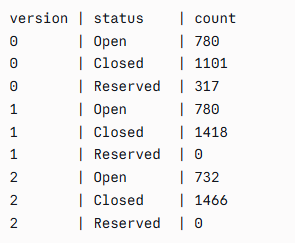

In [9]:
#Step 1 — Read each version and count by status. You already know this:

# Version 0 — original data before any updates
v0 = spark.read \
  .format("delta")\
  .option("versionAsOf",0)\
  .load(DELTA_PATH).groupBy("status").count()

v1 = spark.read.format("delta").option("versionAsOf", 1).load(DELTA_PATH)\
      .groupBy("status").count()

v2 = spark.read.format("delta").option("versionAsof", 2).load(DELTA_PATH)\
      .groupBy("status").count()


#Step 2 — Add a version number column to each so you know which is which:

v0 = v0.withColumn("version", F.lit(0))
v1 = v1.withColumn("version", F.lit(1))
v2 = v2.withColumn("version", F.lit(2))

#Step 3 — Stack all three DataFrames on top of each other using union:

all_versions = v0.union(v1).union(v2)
all_versions.orderBy("version", "status").show()


+---------+-----+-------+
|   status|count|version|
+---------+-----+-------+
|   Closed| 1101|      0|
|   Denied|  108|      0|
|Litigated|  194|      0|
|     Open|  780|      0|
| Reserved|  317|      0|
|   Closed| 1418|      1|
|   Denied|  108|      1|
|Litigated|  194|      1|
|     Open|  780|      1|
|   Closed| 1466|      2|
|   Denied|  108|      2|
|Litigated|  194|      2|
|     Open|  732|      2|
+---------+-----+-------+



**Cell 6 — Schema Evolution**

Schema Evolution — add a new column to an existing Delta table
without breaking anything.

Plain english:
Imagine you have been storing claims data for 2 years.
Now the business wants to add a fraud_score column to every claim.

With plain Parquet — you cannot. The existing files do not have
that column. Any attempt to append new data with a new column
throws a schema mismatch error.

With Delta — you tell it to merge the new schema.
Existing rows get null for the new column.
New rows get the actual value.
No data loss. No pipeline failure.

This is called schema evolution — the table schema grows
over time as business requirements change.

In [10]:
from pyspark.sql.types import DoubleType
import builtins

# Add a fraud_score column to a subset of claims
# Simulate: fraud team scored 500 claims, rest not yet scored

# Real fraud scoring logic based on claim characteristics
def fraud_score_fn(incurred_loss, claim_type, litigation, claimant_type):
  if incurred_loss is None:
    return 0.0

  score = 0.0
  loss = float(incurred_loss)

  # Factor 1: Loss amount — higher loss = higher suspicion
  # Scale: loss above 1M = 30 points, above 500k = 20, above 100k = 10

  if loss > 10000000:
    score += 30.0
  elif loss > 500000:
    score += 20.0
  elif loss > 100000:
    score += 10.0

  # Factor 2: Claim type — Bodily Injury and Workers Comp
  # are most commonly fraudulent in construction insurance

  if claim_type in ("Bodily Injury", "Workers Comp"):
    score += 25.0
  elif claim_type == "Third Party Liability":
    score += 15.0

  # Factor 3: Litigation flag — already in legal dispute
  # significantly increases fraud probability

  if litigation:
    score += 30.0

  # Factor 4: Employee claimant with high loss
  # Employees filing large claims is a known fraud pattern
  if claimant_type == "Employee" and loss > 500000:
        score += 15.0

  # Cap at 100
  return builtins.round(builtins.min(score, 100.0), 1)

fraud_score_udf = F.udf(fraud_score_fn, DoubleType())

# Apply to first 500 claims
claims_with_fraud = spark.read.format("delta").load(DELTA_PATH) \
    .limit(500) \
    .withColumn(
        "fraud_score",
        fraud_score_udf(
            F.col("incurred_loss"),
            F.col("claim_type"),
            F.col("litigation"),
            F.col("claimant_type")
        )
    )

print("Fraud scores based on real claim characteristics:")
claims_with_fraud.select(
    "claim_id",
    "claim_type",
    "incurred_loss",
    "litigation",
    "claimant_type",
    "fraud_score"
).orderBy("fraud_score", ascending=False).show(10)

# Distribution of fraud scores
print("Fraud score distribution:")
claims_with_fraud.select(
    F.count(F.when(F.col("fraud_score") >= 70, 1)).alias("high_risk"),
    F.count(F.when(
        (F.col("fraud_score") >= 40) &
        (F.col("fraud_score") < 70), 1)).alias("medium_risk"),
    F.count(F.when(F.col("fraud_score") < 40, 1)).alias("low_risk")
).show()

Fraud scores based on real claim characteristics:
+---------+--------------+-------------+----------+--------------+-----------+
| claim_id|    claim_type|incurred_loss|litigation| claimant_type|fraud_score|
+---------+--------------+-------------+----------+--------------+-----------+
|CLM-00079|  Workers Comp|   1060483.17|      true|      Employee|       90.0|
|CLM-00308|  Workers Comp|   1641396.15|      true|      Employee|       90.0|
|CLM-00434|  Workers Comp|   1479245.48|      true|      Employee|       90.0|
|CLM-00019| Bodily Injury|    738102.60|      true|Property Owner|       75.0|
|CLM-00254|  Workers Comp|    692011.04|      true|   Third Party|       75.0|
|CLM-00361|  Workers Comp|   1191213.54|      true|Property Owner|       75.0|
|CLM-00404|  Workers Comp|    517493.21|      true|Property Owner|       75.0|
|CLM-00498| Bodily Injury|    508877.26|      true|Property Owner|       75.0|
|CLM-00061| Bodily Injury|    291059.50|      true|   Third Party|       65.0|
|C

In [11]:
claims_with_fraud.write \
    .format("delta") \
    .mode("append") \
    .option("mergeSchema", "true") \
    .save(DELTA_PATH)

print("Appended with fraud_score.")

result = spark.read.format("delta").load(DELTA_PATH)
print(f"Total rows after append: {result.count()}")

print("\nFraud score null vs scored:")
result.select(
    F.count(F.when(F.col("fraud_score").isNull(), 1)).alias("not_scored"),
    F.count(F.when(F.col("fraud_score").isNotNull(), 1)).alias("scored")
).show()

Appended with fraud_score.
Total rows after append: 3000

Fraud score null vs scored:
+----------+------+
|not_scored|scored|
+----------+------+
|      2500|   500|
+----------+------+



Practice Question
Write a query on the current Delta table that shows:

Only the 500 scored claims
Group by claim_type
Show count, average fraud score, and how many are high risk (score ≥ 70)
Order by average fraud score descending

You know all the functions needed — filter, groupBy, agg, F.count, F.when, F.round, F.avg, orderBy. Write it and paste your code.

In [12]:
result = spark.read.format("delta").load(DELTA_PATH)

scored_only = result.filter(F.col("fraud_score").isNotNull())
print("Scored Claim", scored_only.count())

scored_only.groupBy("claim_type")\
  .agg(
      F.count("claim_id").alias("total_claims"),
      F.round(F.avg("fraud_score"), 1).alias("avg_fraud_score"),
      F.count(F.when(F.col("fraud_score")>=70, F.col("claim_id"))).alias("high_risk_count")
  ).orderBy("avg_fraud_score", ascending = False).show()


Scored Claim 500
+--------------------+------------+---------------+---------------+
|          claim_type|total_claims|avg_fraud_score|high_risk_count|
+--------------------+------------+---------------+---------------+
|        Workers Comp|          70|           47.0|              6|
|       Bodily Injury|          75|           44.0|              2|
|Third Party Liabi...|          67|           34.6|              0|
|     Equipment Theft|          78|           21.0|              0|
|     Property Damage|          69|           19.7|              0|
|        Water Damage|          70|           19.1|              0|
|      Fire/Explosion|          71|           18.8|              0|
+--------------------+------------+---------------+---------------+



Practice Question 2

Using the same Delta table, write a query that shows:

Only the 2,500 unscored claims (fraud_score is null)

Group by status

Show total count and total incurred loss per status

Order by total incurred loss descending

Same patterns — filter, groupBy, agg, F.sum, F.round, orderBy.

This time write the full query yourself without breaking it into steps. You just did it — you know the pattern.

In [13]:
non_scored = result.filter(F.col("fraud_score").isNull())
print("Non_Scored Claim", non_scored.count())

non_scored.groupBy("status").agg(
    F.count("claim_id").alias("total_claims_count"),
    F.round(F.sum("incurred_loss"), 2).alias("total_loss")
)\
.orderBy("total_loss", ascending=False).show()

Non_Scored Claim 2500
+---------+------------------+-------------+
|   status|total_claims_count|   total_loss|
+---------+------------------+-------------+
|   Closed|              1466|1130660453.89|
|     Open|               732| 554499782.08|
|Litigated|               194| 142786599.36|
|   Denied|               108|  83142886.28|
+---------+------------------+-------------+



Practice Question 3 — Think harder Using the Delta table, write a single query that:

Reads the current Delta table

Joins with the carriers DataFrame on carrier_id

For scored claims only (fraud_score not null) — group by carrier_name

Show:

Total scored claims per carrier

Average fraud score per carrier

Count of high risk claims (fraud_score ≥ 70)

Total incurred loss for high risk claims only

Only show carriers that have at least 1 high risk claim

Order by total high risk loss descending

You need: filter, join, F.broadcast, groupBy, agg, F.count, F.when, F.avg, F.sum, F.round, having equivalent in Spark — which is .filter() after .agg().

Write the full query. No hints this time.

In [14]:
scored_only = result.filter(F.col("fraud_score").isNotNull())
print("Scored Claim", scored_only.count())

scored_with_carrier = scored_only.join(
    F.broadcast(carriers), on="carrier_id", how="left"
)

scored_with_carrier.groupBy("carrier_name")\
  .agg(
      F.count("claim_id").alias("total_claims"),
      F.round(F.avg("fraud_score"), 1).alias("avg_fraud_score"),
      F.count(F.when(F.col("fraud_score")>=70, F.col("claim_id"))).alias("high_risk_count"),
      F.round(F.sum(F.when(F.col("fraud_score") >= 70, F.col("incurred_loss"))), 2).alias("high_risk_loss")
  )\
  .filter(F.col("high_risk_count") > 0)\
  .orderBy("high_risk_loss", ascending = False).show()

Scored Claim 500
+--------------------+------------+---------------+---------------+--------------+
|        carrier_name|total_claims|avg_fraud_score|high_risk_count|high_risk_loss|
+--------------------+------------+---------------+---------------+--------------+
|Berkshire Hathawa...|          62|           26.9|              3|    2490596.81|
|           FM Global|          38|           31.1|              1|    1641396.15|
| Travelers Companies|          28|           30.4|              1|    1479245.48|
|  Hartford Financial|          37|           31.5|              1|    1191213.54|
|Zurich North America|          23|           30.9|              1|     517493.21|
| Westfield Insurance|          41|           31.2|              1|     508877.26|
+--------------------+------------+---------------+---------------+--------------+



**Cell 7 — MERGE (Upsert)**

**Plain english first.**

MERGE is the most important Delta operation in production. It combines INSERT and UPDATE into one atomic operation.

Think of it like this. Every night at midnight, your source system sends you a file of claim updates. Some of those claims already exist in your Delta table and need to be updated. Some are brand new claims that need to be inserted. You do not know which is which — the file just has claims.
Without MERGE you would have to:

1. Read the update file
2. Check each claim — does it exist or not?
3. Update existing ones separately
4. Insert new ones separately
5. Hope nothing goes wrong between steps 3 and 4

With MERGE you do all of this in one statement. Spark handles the matching, updating, and inserting atomically. Either the whole thing succeeds or the whole thing fails. No partial writes.

**The three conditions in a MERGE:**

1. WHEN MATCHED AND condition  → UPDATE the existing row
2. WHEN MATCHED               → UPDATE the existing row (no condition)
3. WHEN NOT MATCHED           → INSERT as a new row

Real NovaBuild scenario:

Every morning Injala receives a batch update file from the claims management system. It contains:

Updated status and loss amounts for existing claims
New claims filed overnight

One MERGE handles all of it.

In [15]:
"""
MERGE — insert new rows and update existing rows in one operation.

Syntax:
  delta_table.alias("target")
  .merge(source_df.alias("source"), "target.key = source.key")
  .whenMatchedUpdate(set={...})
  .whenNotMatchedInsertAll()
  .execute()

Three parts:
  alias("target") — name the existing Delta table "target"
  alias("source") — name the incoming update DataFrame "source"
  merge condition — how to match rows between target and source
                   usually the primary key: target.claim_id = source.claim_id

Three actions:
  whenMatchedUpdate — row exists in both → update it
  whenNotMatchedInsert — row only in source → insert it
  whenNotMatchedBySource — row only in target → optionally delete it
"""

# ── Step 1: Create simulated incoming update batch ────────────
# This represents claims data arriving from the source system
# Contains:
#   - 10 existing claims with updated status and loss amounts
#   - 3 brand new claims filed overnight

from pyspark.sql.types import StructType, StructField, StringType, DateType, DecimalType
from datetime import date
from decimal import Decimal

# 10 existing claims — updated values
existing_updated = [
    ("CLM-00001", "Closed",    Decimal("125000.00"), "Lisa Johnson"),
    ("CLM-00002", "Litigated", Decimal("1100000.00"), "Mike Smith"),
    ("CLM-00003", "Closed",    Decimal("230000.00"), "Sarah Davis"),
    ("CLM-00004", "Denied",    Decimal("0.00"),       "Tom Wilson"),
    ("CLM-00005", "Closed",    Decimal("445000.00"), "Lisa Johnson"),
    ("CLM-00006", "Litigated", Decimal("660000.00"), "Mike Smith"),
    ("CLM-00007", "Closed",    Decimal("185000.00"), "Sarah Davis"),
    ("CLM-00008", "Closed",    Decimal("400000.00"), "Tom Wilson"),
    ("CLM-00009", "Litigated", Decimal("1050000.00"), "Lisa Johnson"),
    ("CLM-00010", "Closed",    Decimal("275000.00"), "Mike Smith"),
]

# 3 brand new claims
new_claims = [
    ("CLM-99001", "Open", Decimal("350000.00"), "Sarah Davis"),
    ("CLM-99002", "Open", Decimal("780000.00"), "Tom Wilson"),
    ("CLM-99003", "Open", Decimal("120000.00"), "Lisa Johnson"),
]

# Combine into one update batch
update_schema = StructType([
    StructField("claim_id",      StringType(),       True),
    StructField("status",        StringType(),       True),
    StructField("incurred_loss", DecimalType(18,2),  True),
    StructField("adjuster_name", StringType(),       True),
])

update_batch = spark.createDataFrame(
    existing_updated + new_claims,
    schema=update_schema
)

print("Incoming update batch:")
update_batch.show()
print(f"Total in batch: {update_batch.count()}")
print(f"  Existing claims to update: {len(existing_updated)}")
print(f"  New claims to insert:      {len(new_claims)}")

Incoming update batch:
+---------+---------+-------------+-------------+
| claim_id|   status|incurred_loss|adjuster_name|
+---------+---------+-------------+-------------+
|CLM-00001|   Closed|    125000.00| Lisa Johnson|
|CLM-00002|Litigated|   1100000.00|   Mike Smith|
|CLM-00003|   Closed|    230000.00|  Sarah Davis|
|CLM-00004|   Denied|         0.00|   Tom Wilson|
|CLM-00005|   Closed|    445000.00| Lisa Johnson|
|CLM-00006|Litigated|    660000.00|   Mike Smith|
|CLM-00007|   Closed|    185000.00|  Sarah Davis|
|CLM-00008|   Closed|    400000.00|   Tom Wilson|
|CLM-00009|Litigated|   1050000.00| Lisa Johnson|
|CLM-00010|   Closed|    275000.00|   Mike Smith|
|CLM-99001|     Open|    350000.00|  Sarah Davis|
|CLM-99002|     Open|    780000.00|   Tom Wilson|
|CLM-99003|     Open|    120000.00| Lisa Johnson|
+---------+---------+-------------+-------------+

Total in batch: 13
  Existing claims to update: 10
  New claims to insert:      3


In [16]:
"""
MERGE — match source rows against target rows using claim_id.
For each source row:
  If claim_id EXISTS in target   → UPDATE status, incurred_loss, adjuster_name
  If claim_id NOT in target      → INSERT as a brand new row

This is called an upsert — update + insert in one operation.
"""

# Check target before merge
print("Target BEFORE merge:")
spark.read.format("delta").load(DELTA_PATH) \
    .filter(F.col("claim_id").isin(
        "CLM-00001", "CLM-00002", "CLM-99001", "CLM-99002"
    )) \
    .select("claim_id", "status", "incurred_loss", "adjuster_name") \
    .show()

print(f"Total rows before merge: {spark.read.format('delta').load(DELTA_PATH).count()}")

# ── The MERGE operation ───────────────────────────────────────
delta_table = DeltaTable.forPath(spark, DELTA_PATH)

delta_table.alias("target") \
    .merge(
        update_batch.alias("source"),
        "target.claim_id = source.claim_id"
    ) \
    .whenMatchedUpdate(set={
        "status":        "source.status",
        "incurred_loss": "source.incurred_loss",
        "adjuster_name": "source.adjuster_name"
    }) \
    .whenNotMatchedInsert(values={
        "claim_id":      "source.claim_id",
        "status":        "source.status",
        "incurred_loss": "source.incurred_loss",
        "adjuster_name": "source.adjuster_name"
    }) \
    .execute()

# Check target after merge
print("\nTarget AFTER merge:")
spark.read.format("delta").load(DELTA_PATH) \
    .filter(F.col("claim_id").isin(
        "CLM-00001", "CLM-00002", "CLM-99001", "CLM-99002"
    )) \
    .select("claim_id", "status", "incurred_loss", "adjuster_name") \
    .show()

print(f"Total rows after merge: {spark.read.format('delta').load(DELTA_PATH).count()}")

# History
print("\nHistory after merge:")
delta_table.history() \
    .select("version", "timestamp", "operation") \
    .show()

Target BEFORE merge:
+---------+------+-------------+-------------+
| claim_id|status|incurred_loss|adjuster_name|
+---------+------+-------------+-------------+
|CLM-00001|  Open|    120752.80| Lisa Johnson|
|CLM-00002|  Open|   1096690.44| Linda Garcia|
|CLM-00001|  Open|    120752.80| Lisa Johnson|
|CLM-00002|  Open|   1096690.44| Linda Garcia|
+---------+------+-------------+-------------+

Total rows before merge: 3000

Target AFTER merge:
+---------+---------+-------------+-------------+
| claim_id|   status|incurred_loss|adjuster_name|
+---------+---------+-------------+-------------+
|CLM-00001|   Closed|    125000.00| Lisa Johnson|
|CLM-00001|   Closed|    125000.00| Lisa Johnson|
|CLM-00002|Litigated|   1100000.00|   Mike Smith|
|CLM-00002|Litigated|   1100000.00|   Mike Smith|
|CLM-99001|     Open|    350000.00|  Sarah Davis|
|CLM-99002|     Open|    780000.00|   Tom Wilson|
+---------+---------+-------------+-------------+

Total rows after merge: 3003

History after merge:

**Extending the example with larger data**

**Create 200 Existing Claims For Updates**

In [17]:
update_rows = (
    spark.read.format("delta")\
    .load(DELTA_PATH)\
    .select(
        "claim_id",
        "status",
        "incurred_loss",
        "adjuster_name"
    )\
    .limit(200)

)

print("Rows in Update Batch:",update_rows.count())
update_rows.show(10, truncate = False)

Rows in Update Batch: 200
+---------+---------+-------------+-------------+
|claim_id |status   |incurred_loss|adjuster_name|
+---------+---------+-------------+-------------+
|CLM-00001|Closed   |125000.00    |Lisa Johnson |
|CLM-00001|Closed   |125000.00    |Lisa Johnson |
|CLM-00002|Litigated|1100000.00   |Mike Smith   |
|CLM-00002|Litigated|1100000.00   |Mike Smith   |
|CLM-00003|Closed   |230000.00    |Sarah Davis  |
|CLM-00003|Closed   |230000.00    |Sarah Davis  |
|CLM-00004|Denied   |0.00         |Tom Wilson   |
|CLM-00004|Denied   |0.00         |Tom Wilson   |
|CLM-00005|Closed   |445000.00    |Lisa Johnson |
|CLM-00005|Closed   |445000.00    |Lisa Johnson |
+---------+---------+-------------+-------------+
only showing top 10 rows



Checking the duplicated values

Checking the howmany duplicated values are there:

In [18]:
spark.read.format("delta").load(DELTA_PATH)\
  .agg(
      F.count("*").alias("total_claim_counts"),
      F.countDistinct("claim_id").alias("unique_claim_id")
  )\
  .show()

update_rows.groupBy("claim_id").count() \
    .filter(F.col("count") > 1) \
    .show()

+------------------+---------------+
|total_claim_counts|unique_claim_id|
+------------------+---------------+
|              3003|           2503|
+------------------+---------------+

+---------+-----+
| claim_id|count|
+---------+-----+
|CLM-00001|    2|
|CLM-00002|    2|
|CLM-00003|    2|
|CLM-00004|    2|
|CLM-00005|    2|
|CLM-00006|    2|
|CLM-00007|    2|
|CLM-00008|    2|
|CLM-00009|    2|
|CLM-00010|    2|
|CLM-00011|    2|
|CLM-00012|    2|
|CLM-00013|    2|
|CLM-00014|    2|
|CLM-00015|    2|
|CLM-00016|    2|
|CLM-00017|    2|
|CLM-00018|    2|
|CLM-00019|    2|
|CLM-00020|    2|
+---------+-----+
only showing top 20 rows



**Let's identify exactly which claims are duplicated.**

In [19]:
duplicates = (
    spark.read.format("delta").load(DELTA_PATH)\
    .groupBy("claim_id")\
    .count()\
    .filter(F.col("count") > 1)
)

print("Duplicated Claim IDs:", duplicates.count())

Duplicated Claim IDs: 500


Now dropping duplicated and again counting the rows

In [20]:
update_rows = spark.read.format("delta").load(DELTA_PATH)\
  .dropDuplicates(["claim_id"])\
  .select(
      "claim_id",
      "status",
      "incurred_loss",
      "adjuster_name"
  )\
  .limit(200)

print("Rows:", update_rows.count())
print(
    "Unique Claim IDs:",
    update_rows.select("claim_id").distinct().count()
)

Rows: 200
Unique Claim IDs: 200


**Create the Update Feed**

In [21]:
from pyspark.sql import functions as F

update_feed = (
    update_rows.withColumn(
        "status",
        F.when(
            F.col("status").isin("Open", "Reserved"),
            "Litigated"
        ).otherwise("Closed")
    )
    .withColumn(
        "incurred_loss",
        F.round(F.col("incurred_loss")*1.10, 2)
    )
    .withColumn(
        "adjuster_name",
        F.lit("Senior Adjuster Team")
    )
)
update_feed.show(10, truncate=False)

+---------+------+-------------+--------------------+
|claim_id |status|incurred_loss|adjuster_name       |
+---------+------+-------------+--------------------+
|CLM-00001|Closed|137500.0     |Senior Adjuster Team|
|CLM-00002|Closed|1210000.0    |Senior Adjuster Team|
|CLM-00003|Closed|253000.0     |Senior Adjuster Team|
|CLM-00004|Closed|0.0          |Senior Adjuster Team|
|CLM-00005|Closed|489500.0     |Senior Adjuster Team|
|CLM-00006|Closed|726000.0     |Senior Adjuster Team|
|CLM-00007|Closed|203500.0     |Senior Adjuster Team|
|CLM-00008|Closed|440000.0     |Senior Adjuster Team|
|CLM-00009|Closed|1155000.0    |Senior Adjuster Team|
|CLM-00010|Closed|302500.0     |Senior Adjuster Team|
+---------+------+-------------+--------------------+
only showing top 10 rows



Checking update_row and update_feed to see the changes:

In [22]:
update_rows.show(5, truncate=False)
update_feed.show(5, truncate=False)

+---------+---------+-------------+-------------+
|claim_id |status   |incurred_loss|adjuster_name|
+---------+---------+-------------+-------------+
|CLM-00001|Closed   |125000.00    |Lisa Johnson |
|CLM-00002|Litigated|1100000.00   |Mike Smith   |
|CLM-00003|Closed   |230000.00    |Sarah Davis  |
|CLM-00004|Denied   |0.00         |Tom Wilson   |
|CLM-00005|Closed   |445000.00    |Lisa Johnson |
+---------+---------+-------------+-------------+
only showing top 5 rows

+---------+------+-------------+--------------------+
|claim_id |status|incurred_loss|adjuster_name       |
+---------+------+-------------+--------------------+
|CLM-00001|Closed|137500.0     |Senior Adjuster Team|
|CLM-00002|Closed|1210000.0    |Senior Adjuster Team|
|CLM-00003|Closed|253000.0     |Senior Adjuster Team|
|CLM-00004|Closed|0.0          |Senior Adjuster Team|
|CLM-00005|Closed|489500.0     |Senior Adjuster Team|
+---------+------+-------------+--------------------+
only showing top 5 rows



**Create 100 New Claims**

In [23]:
import random
from pyspark.sql import Row

adjusters = [
    "Lisa Johnson",
    "Mike Smith",
    "Sarah Davis",
    "Tom Wilson",
    "Karen Brown",
    "David Lee"
]

statuses = [
    "Open",
    "Reserved",
    "Under Investigation"
]

new_claims_data = []

for i in range(99102,99203):
  new_claims_data.append(
      Row(
          claim_id = f"CLM-{i}",
          status = random.choice(statuses),
          incurred_loss = round(random.uniform(10000, 750000), 2),
          adjuster_name = random.choice(adjusters)
      )
  )

new_claims = spark.createDataFrame(new_claims_data)

print("New Claims:", new_claims.count())

new_claims.show(10, truncate=False)

New Claims: 101
+---------+-------------------+-------------+-------------+
|claim_id |status             |incurred_loss|adjuster_name|
+---------+-------------------+-------------+-------------+
|CLM-99102|Reserved           |156350.57    |Karen Brown  |
|CLM-99103|Open               |202741.24    |Lisa Johnson |
|CLM-99104|Reserved           |474464.47    |Tom Wilson   |
|CLM-99105|Under Investigation|624173.71    |Tom Wilson   |
|CLM-99106|Reserved           |726410.08    |Sarah Davis  |
|CLM-99107|Reserved           |302214.25    |Lisa Johnson |
|CLM-99108|Reserved           |530939.3     |David Lee    |
|CLM-99109|Open               |132927.61    |Tom Wilson   |
|CLM-99110|Reserved           |92519.75     |David Lee    |
|CLM-99111|Under Investigation|727674.28    |Mike Smith   |
+---------+-------------------+-------------+-------------+
only showing top 10 rows



**Build the final source feed**

In [24]:
source_feed = update_feed.unionByName(new_claims)

print("Source Feed Rows:", source_feed.count())

source_feed.show(10, truncate=False)

Source Feed Rows: 301
+---------+------+-------------+--------------------+
|claim_id |status|incurred_loss|adjuster_name       |
+---------+------+-------------+--------------------+
|CLM-00001|Closed|137500.0     |Senior Adjuster Team|
|CLM-00002|Closed|1210000.0    |Senior Adjuster Team|
|CLM-00003|Closed|253000.0     |Senior Adjuster Team|
|CLM-00004|Closed|0.0          |Senior Adjuster Team|
|CLM-00005|Closed|489500.0     |Senior Adjuster Team|
|CLM-00006|Closed|726000.0     |Senior Adjuster Team|
|CLM-00007|Closed|203500.0     |Senior Adjuster Team|
|CLM-00008|Closed|440000.0     |Senior Adjuster Team|
|CLM-00009|Closed|1155000.0    |Senior Adjuster Team|
|CLM-00010|Closed|302500.0     |Senior Adjuster Team|
+---------+------+-------------+--------------------+
only showing top 10 rows



**Now the Merge**

In [25]:
target_before = spark.read.format("delta").load(DELTA_PATH)

print("Rows Before Merge:", target_before.count())

Rows Before Merge: 3003


In [26]:
before_count = spark.read.format("delta").load(DELTA_PATH).count()
print(f"Rows before merge: {before_count}")

delta_table.alias("target") \
    .merge(
        source_feed.alias("source"),
        "target.claim_id = source.claim_id"
    ) \
    .whenMatchedUpdate(set={
        "status":        "source.status",
        "incurred_loss": "source.incurred_loss",
        "adjuster_name": "source.adjuster_name"
    }) \
    .whenNotMatchedInsert(values={
        "claim_id":      "source.claim_id",
        "status":        "source.status",
        "incurred_loss": "source.incurred_loss",
        "adjuster_name": "source.adjuster_name"
    }) \
    .execute()

after_count = spark.read.format("delta").load(DELTA_PATH).count()
print(f"Rows before: {before_count}")
print(f"Rows after:  {after_count}")
print(f"Rows added:  {after_count - before_count}")

# Verify new rows inserted
spark.read.format("delta").load(DELTA_PATH) \
    .filter(F.col("claim_id").like("CLM_NEW_%")) \
    .select("claim_id", "status", "incurred_loss", "adjuster_name") \
    .show(5)

# Verify updates applied
spark.read.format("delta").load(DELTA_PATH) \
    .filter(F.col("claim_id").isin("CLM-00001", "CLM-00002", "CLM-00003")) \
    .select("claim_id", "status", "incurred_loss", "adjuster_name") \
    .show()

delta_table.history() \
    .select("version", "timestamp", "operation") \
    .show(truncate=False)

Rows before merge: 3003
Rows before: 3003
Rows after:  3104
Rows added:  101
+--------+------+-------------+-------------+
|claim_id|status|incurred_loss|adjuster_name|
+--------+------+-------------+-------------+
+--------+------+-------------+-------------+

+---------+------+-------------+--------------------+
| claim_id|status|incurred_loss|       adjuster_name|
+---------+------+-------------+--------------------+
|CLM-00001|Closed|    137500.00|Senior Adjuster Team|
|CLM-00001|Closed|    137500.00|Senior Adjuster Team|
|CLM-00002|Closed|   1210000.00|Senior Adjuster Team|
|CLM-00002|Closed|   1210000.00|Senior Adjuster Team|
|CLM-00003|Closed|    253000.00|Senior Adjuster Team|
|CLM-00003|Closed|    253000.00|Senior Adjuster Team|
+---------+------+-------------+--------------------+

+-------+-----------------------+---------+
|version|timestamp              |operation|
+-------+-----------------------+---------+
|5      |2026-06-22 07:52:06.716|MERGE    |
|4      |2026-06-22 0

In [27]:
delta_table = DeltaTable.forPath(spark, DELTA_PATH)

delta_table.alias("target") \
    .merge(
        source_feed.alias("source"),
        "target.claim_id = source.claim_id"
    ) \
    .whenMatchedUpdate(set={
        "status":        "source.status",
        "incurred_loss": "source.incurred_loss",
        "adjuster_name": "source.adjuster_name"
    }) \
    .whenNotMatchedInsert(values={
        "claim_id":      "source.claim_id",
        "status":        "source.status",
        "incurred_loss": "source.incurred_loss",
        "adjuster_name": "source.adjuster_name"
    }) \
    .execute()

**The rule in production:**

**whenMatchedUpdate** with explicit columns — always. Only touch what you have new values for. Never null out existing good data.

**whenNotMatchedInsert** with explicit columns — for new records, only populate what you have. Other columns stay null until they are populated by future updates.

**whenMatchedUpdateAll** and whenNotMatchedInsertAll — only use when your source DataFrame has the complete schema with all columns and real values for every column.

Final Check if the Merge Succed or not

In [28]:
print(
    "Rows After Merge:",
    spark.read.format("delta")
    .load(DELTA_PATH)
    .count()
)

Rows After Merge: 3104


In [29]:
spark.read.format("delta").load(DELTA_PATH) \
    .filter(F.col("claim_id").startswith("CLM_NEW")) \
    .select("claim_id", "status", "incurred_loss", "adjuster_name") \
    .show(10)

+--------+------+-------------+-------------+
|claim_id|status|incurred_loss|adjuster_name|
+--------+------+-------------+-------------+
+--------+------+-------------+-------------+



In [30]:
# Check if duplicates exist
print("Duplicate claim_ids:")
spark.read.format("delta").load(DELTA_PATH) \
    .groupBy("claim_id") \
    .count() \
    .filter(F.col("count") > 1) \
    .orderBy("count", ascending=False) \
    .show(10)

Duplicate claim_ids:
+---------+-----+
| claim_id|count|
+---------+-----+
|CLM-00001|    2|
|CLM-00005|    2|
|CLM-00009|    2|
|CLM-00016|    2|
|CLM-00019|    2|
|CLM-00028|    2|
|CLM-00031|    2|
|CLM-00033|    2|
|CLM-00036|    2|
|CLM-00037|    2|
+---------+-----+
only showing top 10 rows



In [31]:
# Rewrite Delta table cleanly from PostgreSQL
claims.write \
    .format("delta") \
    .mode("overwrite") \
    .save(DELTA_PATH)

print("Delta table reset.")
print("Row count:", spark.read.format("delta").load(DELTA_PATH).count())

# Verify no duplicates
dup_count = spark.read.format("delta").load(DELTA_PATH) \
    .groupBy("claim_id").count() \
    .filter(F.col("count") > 1).count()
print(f"Duplicate claim_ids: {dup_count}")

Delta table reset.
Row count: 2500
Duplicate claim_ids: 0


**Complete Merge Drom Start to End.**

In [32]:
from pyspark.sql import functions as F
from pyspark.sql import Row
from delta.tables import DeltaTable
from decimal import Decimal
import random

# =====================================================
# STEP 1: Build 200 UPDATE records
# =====================================================

update_rows = (
    spark.read.format("delta")
    .load(DELTA_PATH)
    .dropDuplicates(["claim_id"])
    .select(
        "claim_id",
        "status",
        "incurred_loss",
        "adjuster_name"
    )
    .limit(200)
)

update_feed = (
    update_rows
    .withColumn(
        "status",
        F.when(
            F.col("status").isin("Open", "Reserved"),
            "Litigated"
        ).otherwise("Closed")
    )
    .withColumn(
        "incurred_loss",
        F.round(F.col("incurred_loss") * 1.10, 2)
    )
    .withColumn(
        "adjuster_name",
        F.lit("Senior Adjuster Team")
    )
)

print(f"Update Records: {update_feed.count()}")

# =====================================================
# STEP 2: Build 100 INSERT records
# =====================================================

adjusters = [
    "Lisa Johnson",
    "Mike Smith",
    "Sarah Davis",
    "Tom Wilson",
    "Karen Brown",
    "David Lee"
]

statuses = [
    "Open",
    "Reserved",
    "Under Investigation"
]

new_claims_data = []

for i in range(99001, 99101):

    new_claims_data.append(
        Row(
            claim_id=f"CLM_NEW_{i}",
            status=random.choice(statuses),
            incurred_loss=Decimal(
                str(
                    round(
                        random.uniform(10000, 750000),
                        2
                    )
                )
            ),
            adjuster_name=random.choice(adjusters)
        )
    )

new_claims = spark.createDataFrame(new_claims_data)

print(f"Insert Records: {new_claims.count()}")

# =====================================================
# STEP 3: Combine into Source Feed
# =====================================================

source_feed = update_feed.unionByName(new_claims)

print(f"Source Feed Rows: {source_feed.count()}")

# =====================================================
# STEP 4: Before Merge Counts
# =====================================================

before_count = (
    spark.read.format("delta")
    .load(DELTA_PATH)
    .count()
)

print(f"Rows Before Merge: {before_count}")

# =====================================================
# STEP 5: MERGE (UPSERT)
# =====================================================

delta_table = DeltaTable.forPath(
    spark,
    DELTA_PATH
)

delta_table.alias("target") \
    .merge(
        source_feed.alias("source"),
        "target.claim_id = source.claim_id"
    ) \
    .whenMatchedUpdate(set={
        "status": "source.status",
        "incurred_loss": "source.incurred_loss",
        "adjuster_name": "source.adjuster_name"
    }) \
    .whenNotMatchedInsert(values={
        "claim_id": "source.claim_id",
        "status": "source.status",
        "incurred_loss": "source.incurred_loss",
        "adjuster_name": "source.adjuster_name"
    }) \
    .execute()

# =====================================================
# STEP 6: After Merge Counts
# =====================================================

after_count = (
    spark.read.format("delta")
    .load(DELTA_PATH)
    .count()
)

print(f"Rows After Merge: {after_count}")
print(f"Rows Added: {after_count - before_count}")

# =====================================================
# STEP 7: Verify New Records
# =====================================================

print("Sample Inserted Records:")

spark.read.format("delta") \
    .load(DELTA_PATH) \
    .filter(F.col("claim_id").like("CLM_NEW_%")) \
    .select(
        "claim_id",
        "status",
        "incurred_loss",
        "adjuster_name"
    ) \
    .show(10, truncate=False)

# =====================================================
# STEP 8: Verify Updated Records
# =====================================================

print("Sample Updated Records:")

spark.read.format("delta") \
    .load(DELTA_PATH) \
    .filter(F.col("claim_id").isin(
        "CLM-00001",
        "CLM-00002",
        "CLM-00003",
        "CLM-00004",
        "CLM-00005"
    )) \
    .select(
        "claim_id",
        "status",
        "incurred_loss",
        "adjuster_name"
    ) \
    .show(truncate=False)

# =====================================================
# STEP 9: Delta History
# =====================================================

print("Delta History:")

delta_table.history() \
    .select(
        "version",
        "timestamp",
        "operation"
    ) \
    .show(truncate=False)

Update Records: 200
Insert Records: 100
Source Feed Rows: 300
Rows Before Merge: 2500
Rows After Merge: 2600
Rows Added: 100
Sample Inserted Records:
+-------------+-------------------+-------------+-------------+
|claim_id     |status             |incurred_loss|adjuster_name|
+-------------+-------------------+-------------+-------------+
|CLM_NEW_99001|Under Investigation|204715.58    |Sarah Davis  |
|CLM_NEW_99002|Under Investigation|106060.50    |David Lee    |
|CLM_NEW_99003|Under Investigation|240348.65    |Karen Brown  |
|CLM_NEW_99004|Reserved           |521630.44    |Lisa Johnson |
|CLM_NEW_99005|Under Investigation|386735.40    |Karen Brown  |
|CLM_NEW_99006|Open               |48861.36     |Sarah Davis  |
|CLM_NEW_99007|Open               |200497.73    |Sarah Davis  |
|CLM_NEW_99008|Under Investigation|239264.65    |David Lee    |
|CLM_NEW_99009|Under Investigation|265501.40    |Tom Wilson   |
|CLM_NEW_99010|Open               |59161.84     |David Lee    |
+-------------+---

In [33]:
from pyspark.sql import SparkSession

SparkSession.builder.getOrCreate()

In [34]:
spark.read.format("delta").load(DELTA_PATH).count()

2600

In [35]:
'DELTA_PATH' in globals()
'claims' in globals()

True

In [36]:
spark.catalog.listTables()

[]

**Checking for the Duplicates.**

In [37]:
print("Current row count:", spark.read.format("delta").load(DELTA_PATH).count())

from delta.tables import DeltaTable
delta_table = DeltaTable.forPath(spark, DELTA_PATH)
delta_table.history().select("version", "timestamp", "operation").show(truncate=False)

Current row count: 2600
+-------+-----------------------+---------+
|version|timestamp              |operation|
+-------+-----------------------+---------+
|8      |2026-06-22 07:52:48.372|MERGE    |
|7      |2026-06-22 07:52:33.426|WRITE    |
|6      |2026-06-22 07:52:22.215|MERGE    |
|5      |2026-06-22 07:52:06.716|MERGE    |
|4      |2026-06-22 07:51:31.42 |MERGE    |
|3      |2026-06-22 07:51:03.868|WRITE    |
|2      |2026-06-22 07:50:17.457|UPDATE   |
|1      |2026-06-22 07:50:00.985|UPDATE   |
|0      |2026-06-22 07:49:37.401|WRITE    |
+-------+-----------------------+---------+



In [38]:
dup_count = spark.read.format("delta").load(DELTA_PATH) \
    .groupBy("claim_id").count() \
    .filter(F.col("count") > 1).count()
print(f"Duplicate claim_ids: {dup_count}")

Duplicate claim_ids: 0


**Cell 8A — The Small File Problem & Why OPTIMIZE Exists**

Small File Problem

Spark performance degrades when a table contains many small files.

Each file requires metadata reads, file opening, and task scheduling overhead.

OPTIMIZE reduces the small-file problem by compacting many small files into fewer larger files.

Benefits:
- Faster reads
- Less metadata overhead
- Better query performance
- Lower file management cost

OPTIMIZE does not change the data.

It only reorganizes physical storage.

In [39]:
import os

delta_files = []

for root, dirs, files in os.walk(DELTA_PATH):
    for file in files:
        if file.endswith(".parquet"):
            delta_files.append(os.path.join(root, file))

print("Parquet Files:", len(delta_files))

for file in delta_files[:10]:
    print(file)

Parquet Files: 9
/content/novabuild_delta/claims/part-00000-c99733b4-0d13-410d-a8a9-ed164aef7644-c000.snappy.parquet
/content/novabuild_delta/claims/part-00000-7af74c15-32cc-4a9e-acdf-a729066034e7-c000.snappy.parquet
/content/novabuild_delta/claims/part-00000-66028c3d-49d1-4c33-a39d-f4013318f61e-c000.snappy.parquet
/content/novabuild_delta/claims/part-00000-548bd1a0-6723-4a17-b49d-f374d31d4e04-c000.snappy.parquet
/content/novabuild_delta/claims/part-00000-d6cf109a-6d38-45ce-a0c3-b5691656b8e2-c000.snappy.parquet
/content/novabuild_delta/claims/part-00000-5219a7ea-908c-4829-b08e-502d89724023-c000.snappy.parquet
/content/novabuild_delta/claims/part-00000-83dd846a-7c1d-47cf-8890-8810bdd4385d-c000.snappy.parquet
/content/novabuild_delta/claims/part-00000-085ae728-8816-423e-aa00-820824105ce7-c000.snappy.parquet
/content/novabuild_delta/claims/part-00000-53d9d602-e87e-427b-8fb0-b2ecbe86a4b2-c000.snappy.parquet


In [40]:
"""
OPTIMIZE — compact small Parquet files into fewer larger files.
ZORDER   — sort data within files by a column for faster filtered reads.

When to run in production:
  OPTIMIZE — after every large batch write or MERGE
             Keeps file count manageable
  ZORDER   — on columns you filter most often
             claim_type, status, loss_date for NovaBuild claims

On Databricks — OPTIMIZE runs automatically via Auto Optimize.
In Colab — you run it manually.
"""

import os

# Count files before OPTIMIZE
def count_parquet_files(path):
    count = 0
    for root, dirs, files in os.walk(path):
        for file in files:
            if file.endswith(".parquet"):
                count += 1
    return count

print(f"Parquet files BEFORE optimize: {count_parquet_files(DELTA_PATH)}")

# Run OPTIMIZE with ZORDER on claim_type and status
# These are the columns most commonly used in WHERE clauses
spark.sql(f"OPTIMIZE delta.`{DELTA_PATH}` ZORDER BY (claim_type, status)")

print(f"Parquet files AFTER optimize:  {count_parquet_files(DELTA_PATH)}")

# Show history — OPTIMIZE appears as a new version
delta_table.history() \
    .select("version", "timestamp", "operation") \
    .show(truncate=False)

Parquet files BEFORE optimize: 9
Parquet files AFTER optimize:  10
+-------+-----------------------+---------+
|version|timestamp              |operation|
+-------+-----------------------+---------+
|9      |2026-06-22 07:53:04.028|OPTIMIZE |
|8      |2026-06-22 07:52:48.372|MERGE    |
|7      |2026-06-22 07:52:33.426|WRITE    |
|6      |2026-06-22 07:52:22.215|MERGE    |
|5      |2026-06-22 07:52:06.716|MERGE    |
|4      |2026-06-22 07:51:31.42 |MERGE    |
|3      |2026-06-22 07:51:03.868|WRITE    |
|2      |2026-06-22 07:50:17.457|UPDATE   |
|1      |2026-06-22 07:50:00.985|UPDATE   |
|0      |2026-06-22 07:49:37.401|WRITE    |
+-------+-----------------------+---------+



**Cell 9 — VACUUM**

**Plain english first.**

VACUUM is the cleanup crew. After OPTIMIZE, you have old small files sitting on disk doing nothing except taking up space and supporting time travel for old versions. VACUUM deletes them permanently.

The default retention period is 7 days — meaning VACUUM will not delete any files that are less than 7 days old. This protects your time travel history. You can still query last week's data.

If you set retention to 0 hours — VACUUM deletes everything immediately. You lose all time travel history but reclaim disk space instantly. In production you never go below 7 days unless you have a specific reason.

In [41]:
"""
VACUUM — permanently delete old Parquet files no longer needed.

Default retention: 168 hours (7 days)
Files older than retention period get deleted permanently.
After VACUUM — time travel to deleted versions is no longer possible.

In production:
  Run VACUUM weekly or after large OPTIMIZE operations
  Never set retention below 7 days unless explicitly required
  On Databricks — VACUUM can be scheduled as a job
"""

print(f"Files BEFORE vacuum: {count_parquet_files(DELTA_PATH)}")

# Disable retention check for demo purposes
# In production NEVER do this — always keep at least 7 days
spark.conf.set("spark.databricks.delta.retentionDurationCheck.enabled", "false")

# Run VACUUM with 0 hour retention — deletes all old files immediately
# Only safe in development/learning. Never in production.
spark.sql(f"VACUUM delta.`{DELTA_PATH}` RETAIN 0 HOURS")

print(f"Files AFTER vacuum:  {count_parquet_files(DELTA_PATH)}")

# Verify time travel to old version now fails
print("\nAttempting time travel to version 0 after VACUUM:")
try:
    old_count = spark.read \
        .format("delta") \
        .option("versionAsOf", 0) \
        .load(DELTA_PATH) \
        .count()
    print(f"Version 0 row count: {old_count}")
except Exception as e:
    print(f"Time travel failed as expected: {str(e)[:150]}")

# Current data is still intact
print(f"\nCurrent row count still intact: {spark.read.format('delta').load(DELTA_PATH).count()}")

# History still shows all operations — log is never deleted by VACUUM
print("\nHistory still intact after VACUUM:")
delta_table.history() \
    .select("version", "timestamp", "operation") \
    .show(truncate=False)

Files BEFORE vacuum: 10
Files AFTER vacuum:  2

Attempting time travel to version 0 after VACUUM:
Version 0 row count: 2500

Current row count still intact: 2600

History still intact after VACUUM:
+-------+-----------------------+------------+
|version|timestamp              |operation   |
+-------+-----------------------+------------+
|11     |2026-06-22 07:55:01.829|VACUUM END  |
|10     |2026-06-22 07:54:51.809|VACUUM START|
|9      |2026-06-22 07:53:04.028|OPTIMIZE    |
|8      |2026-06-22 07:52:48.372|MERGE       |
|7      |2026-06-22 07:52:33.426|WRITE       |
|6      |2026-06-22 07:52:22.215|MERGE       |
|5      |2026-06-22 07:52:06.716|MERGE       |
|4      |2026-06-22 07:51:31.42 |MERGE       |
|3      |2026-06-22 07:51:03.868|WRITE       |
|2      |2026-06-22 07:50:17.457|UPDATE      |
|1      |2026-06-22 07:50:00.985|UPDATE      |
|0      |2026-06-22 07:49:37.401|WRITE       |
+-------+-----------------------+------------+



**Cell 10 Delta Transaction Log — what is actually inside it**

Plain english first.

You have seen _delta_log folder exist. You have seen 00000000000000000000.json files. But what is actually inside those JSON files?

Every single JSON file is a commit record. It answers one question completely — what changed in this version?

In [42]:
import os

log_path = f"{DELTA_PATH}/_delta_log"

# List all files in the _delta_log folder

all_files = os.listdir(log_path)
print("All files in _delta_log:")
for f in all_files:
  print(f" {f}")

All files in _delta_log:
 00000000000000000005.json
 00000000000000000004.json
 .00000000000000000006.json.crc
 .00000000000000000010.json.crc
 .00000000000000000010.checkpoint.parquet.crc
 00000000000000000003.json
 00000000000000000002.json
 .00000000000000000008.json.crc
 00000000000000000007.json
 _last_checkpoint
 .00000000000000000000.json.crc
 .00000000000000000007.json.crc
 00000000000000000010.checkpoint.parquet
 .00000000000000000011.json.crc
 _commits
 .00000000000000000009.json.crc
 .00000000000000000004.json.crc
 ._last_checkpoint.crc
 00000000000000000001.json
 .00000000000000000003.json.crc
 .00000000000000000001.json.crc
 .00000000000000000005.json.crc
 00000000000000000006.json
 00000000000000000010.json
 00000000000000000011.json
 00000000000000000000.json
 00000000000000000008.json
 .00000000000000000002.json.crc
 00000000000000000009.json


**Now Piece 2 — open commit 0 and read what is inside it:**

In [43]:
import json

# Open version 0 — the initial write

with open(f"{log_path}/00000000000000000000.json", "r") as f:
  content = f.read()

print(content)

{"commitInfo":{"timestamp":1782114577386,"operation":"WRITE","operationParameters":{"mode":"Overwrite","partitionBy":"[]"},"isolationLevel":"Serializable","isBlindAppend":false,"operationMetrics":{"numFiles":"1","numOutputRows":"2500","numOutputBytes":"124721"},"engineInfo":"Apache-Spark/3.5.3 Delta-Lake/3.2.0","txnId":"d30f8301-d1d6-4e5e-a930-d7547ec13f86"}}
{"metaData":{"id":"5653cbc6-3324-4feb-a087-6bb205522b81","format":{"provider":"parquet","options":{}},"schemaString":"{\"type\":\"struct\",\"fields\":[{\"name\":\"claim_id\",\"type\":\"string\",\"nullable\":true,\"metadata\":{\"isSigned\":false,\"scale\":0}},{\"name\":\"claim_number\",\"type\":\"string\",\"nullable\":true,\"metadata\":{\"isSigned\":false,\"scale\":0}},{\"name\":\"policy_id\",\"type\":\"string\",\"nullable\":true,\"metadata\":{\"isSigned\":false,\"scale\":0}},{\"name\":\"program_id\",\"type\":\"string\",\"nullable\":true,\"metadata\":{\"isSigned\":false,\"scale\":0}},{\"name\":\"project_id\",\"type\":\"string\",\"n

In [44]:
"""
ACID Transactions — what each letter means in Delta Lake.

A — Atomicity:   Either the entire operation succeeds or nothing changes.
                 No partial writes. If your job crashes mid-write,
                 Delta rolls back completely. The table is unchanged.

C — Consistency: The table is always in a valid state.
                 Schema is enforced. Constraints are maintained.
                 A half-written file never becomes visible to readers.

I — Isolation:   Multiple readers and writers do not interfere.
                 A reader always sees a consistent snapshot.
                 Two writers cannot corrupt each other's data.
                 Delta uses optimistic concurrency control.

D — Durability:  Once a commit JSON file is written to _delta_log,
                 the operation is permanent.
                 Even if the cluster crashes after the commit,
                 the data is safe.
"""

# Demonstrate Atomicity — simulate a failed write
print("Rows BEFORE failed write attempt:",
      spark.read.format("delta").load(DELTA_PATH).count())

try:
    # Attempt to write data with wrong schema — will fail
    bad_data = spark.createDataFrame(
        [("CLM-99999", "Open", "NOT_A_NUMBER")],
        ["claim_id", "status", "incurred_loss"]
    )
    bad_data.write \
        .format("delta") \
        .mode("append") \
        .save(DELTA_PATH)
except Exception as e:
    print(f"Write failed: {str(e)[:100]}")

print("Rows AFTER failed write attempt:",
      spark.read.format("delta").load(DELTA_PATH).count())

print("\nRow count unchanged — Atomicity guaranteed.")
print("Failed write left no trace in the table.")

Rows BEFORE failed write attempt: 2600
Write failed: [DELTA_FAILED_TO_MERGE_FIELDS] Failed to merge fields 'incurred_loss' and 'incurred_loss'
Rows AFTER failed write attempt: 2600

Row count unchanged — Atomicity guaranteed.
Failed write left no trace in the table.


**Data Skipping — this one IS practically useful**

You already saw the stats in the commit JSON:

json"minValues": {"incurred_loss": 2469.71, ...}

"maxValues": {"incurred_loss": 2297610.10, ...}

Delta collects these stats automatically for every Parquet file when you write. Let me show you how to see them and how much they help:

In [45]:
"""
Data Skipping — Delta reads file statistics to skip irrelevant files.

For every Parquet file, Delta stores in the transaction log:
  - min value per column
  - max value per column
  - null count per column

When you filter WHERE incurred_loss > 1000000:
  Delta checks each file's stats BEFORE reading it.
  If file max < 1000000 — impossible to have matching rows — SKIP.
  If file max >= 1000000 — might have matching rows — READ.

With many small files and good ZORDER — most files get skipped.
This is why OPTIMIZE + ZORDER dramatically speeds up filtered reads.
"""

# See the stats Delta collected for your current files
# These are stored in the transaction log
detail = spark.sql(f"DESCRIBE DETAIL delta.`{DELTA_PATH}`")
detail.select(
    "numFiles",
    "sizeInBytes",
    "numRows"
).show()

# See file-level statistics using Delta log
# This shows min/max values Delta uses for data skipping
spark.sql(f"""
    SELECT
        add.path,
        add.size,
        get_json_object(add.stats, '$.numRecords') AS num_records,
        get_json_object(add.stats, '$.minValues.incurred_loss') AS min_loss,
        get_json_object(add.stats, '$.maxValues.incurred_loss') AS max_loss,
        get_json_object(add.stats, '$.minValues.claim_type') AS min_claim_type,
        get_json_object(add.stats, '$.maxValues.claim_type') AS max_claim_type
    FROM delta.`{DELTA_PATH}`
""").show(truncate=False)

AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column or function parameter with name `numRows` cannot be resolved. Did you mean one of the following? [`name`, `numFiles`, `id`, `format`, `location`].;
'Project [numFiles#30572L, sizeInBytes#30573L, 'numRows]
+- CommandResult [format#30563, id#30564, name#30565, description#30566, location#30567, createdAt#30568, lastModified#30569, partitionColumns#30570, clusteringColumns#30571, numFiles#30572L, sizeInBytes#30573L, properties#30574, minReaderVersion#30575, minWriterVersion#30576, tableFeatures#30577], Execute DescribeDeltaDetailCommand, [[delta,5653cbc6-3324-4feb-a087-6bb205522b81,null,null,file:/content/novabuild_delta/claims,1782114573798000,1782114901829000,[],[],1,126199,keys: [], values: [],1,2,[appendOnly,invariants]]]
      +- DescribeDeltaDetailCommand
         +- ResolvedTable org.apache.spark.sql.delta.catalog.DeltaCatalog@62c3a58e, delta.`/content/novabuild_delta/claims`, DeltaTableV2(org.apache.spark.sql.SparkSes

In [46]:
detail = spark.sql(f"DESCRIBE DETAIL delta.`{DELTA_PATH}`")
detail.select("numFiles", "sizeInBytes").show()

+--------+-----------+
|numFiles|sizeInBytes|
+--------+-----------+
|       1|     126199|
+--------+-----------+



In [47]:
# Read the current active commit to see file statistics
# Delta stores min/max stats for every file in the transaction log
import json
import os

log_path = f"{DELTA_PATH}/_delta_log"

# Read all commit files and find the most recent ADD action
# ADD action contains the file statistics
all_stats = []
for filename in sorted(os.listdir(log_path)):
    if filename.endswith(".json") and not filename.startswith("."):
        with open(f"{log_path}/{filename}", "r") as f:
            for line in f:
                entry = json.loads(line)
                if "add" in entry and "stats" in entry["add"]:
                    stats = json.loads(entry["add"]["stats"])
                    all_stats.append({
                        "file": entry["add"]["path"][:40],
                        "records": stats.get("numRecords"),
                        "min_loss": stats.get("minValues", {}).get("incurred_loss"),
                        "max_loss": stats.get("maxValues", {}).get("incurred_loss"),
                        "min_claim_type": stats.get("minValues", {}).get("claim_type"),
                        "max_claim_type": stats.get("maxValues", {}).get("claim_type")
                    })

print("File statistics stored in Delta transaction log:")
print(f"{'File':<42} {'Records':<10} {'Min Loss':<15} {'Max Loss':<15} {'Min Type':<20} {'Max Type'}")
print("-" * 120)
for s in all_stats:
    print(f"{s['file']:<42} {str(s['records']):<10} {str(s['min_loss']):<15} {str(s['max_loss']):<15} {str(s['min_claim_type']):<20} {str(s['max_claim_type'])}")

File statistics stored in Delta transaction log:
File                                       Records    Min Loss        Max Loss        Min Type             Max Type
------------------------------------------------------------------------------------------------------------------------
part-00000-d6cf109a-6d38-45ce-a0c3-b5691   2500       2469.71         2297610.1       Bodily Injury        Workers Comp
part-00000-83dd846a-7c1d-47cf-8890-8810b   2500       2469.71         2297610.1       Bodily Injury        Workers Comp
part-00000-7af74c15-32cc-4a9e-acdf-a7290   2500       2469.71         2297610.1       Bodily Injury        Workers Comp
part-00000-c99733b4-0d13-410d-a8a9-ed164   500        2483.52         2260772.97      Bodily Injury        Workers Comp
part-00000-5219a7ea-908c-4829-b08e-502d8   3003       0.0             2297610.1       Bodily Injury        Workers Comp
part-00000-53d9d602-e87e-427b-8fb0-b2ecb   3104       0.0             2486850.27      Bodily Injury        Workers

#Section 8.10 — Structured Streaming

Plain english first.

Imagine you are a security guard at a construction site. **Your job in batch mode** would be — at the end of every day, collect all the visitor logs, review them all at once, and write a report. You process everything in one go.

**Your job in streaming mode** would be — stand at the gate all day. Every time someone walks in, check their ID immediately, flag suspicious visitors in real time, update the count on your dashboard instantly. You never stop. You process each event the moment it arrives.
That is the difference between batch and streaming.

Three key concepts before any code:

**1 — Stream source**

Where the data is coming from continuously. In production this is usually Apache Kafka — a message queue where events are published in real time. In Colab we simulate it using a rate source (generates fake rows at a fixed rate) or a file stream (watches a folder for new files).

**2 — Stream sink**

Where the processed data goes. In production — Delta Lake, Kafka, or a database. In Colab — memory (for testing) or files.

**3 — Trigger**

How often Spark processes the incoming data. Every 5 seconds? Every time new data arrives? Once and stop? You control this.

**4 — Output mode**

What to write to the sink each time Spark processes a micro-batch:

append — only write new rows. Most common.

complete — rewrite the entire result every time. Used for aggregations.

update — only write rows that changed.

**5 — Checkpoint**

A folder where Spark saves its progress. If the streaming job crashes and restarts, it picks up from where it left off — no data lost, no data processed twice.

**Cell 1 — Your first streaming query**

In [48]:
"""
# ── SECTION 8.10: Structured Streaming ───────────────────────

Plain english:
Structured Streaming processes data continuously as it arrives.
Same DataFrame API as batch — filter, withColumn, groupBy etc.
The difference is in how you READ (readStream) and WRITE (writeStream).

Rate source — generates fake rows at a fixed rate for testing.
Every row has two columns:
  timestamp — when the row was generated
  value     — a sequential counter starting from 0

This simulates a real stream without needing Kafka.
In production you replace .format("rate") with .format("kafka")
Everything else stays identical.
"""

# Create a streaming DataFrame from rate source
# Generates 2 rows per second

stream_df = spark.readStream\
  .format("rate")\
  .option("rowPerSecond", 2)\
  .load()

# Check if it is a streaming DataFrame

print("Its Streaming:", stream_df.isStreaming)
print("Schema:")
stream_df.printSchema()

Its Streaming: True
Schema:
root
 |-- timestamp: timestamp (nullable = true)
 |-- value: long (nullable = true)



Line by line:

**spark.readStream** — same as spark.read but for streaming. This tells Spark — do not read a fixed dataset, keep reading new data as it arrives.

**.format("rate")** — use the rate source. Generates fake rows at a fixed rate. Only for testing. In production this would be .format("kafka") or .format("delta").

**.option("rowsPerSecond", 2)** — generate 2 new rows every second. Each row has a timestamp and a sequential value.

**.load()** — starts the stream reader. Unlike batch where .load() triggers reading, in streaming this just sets up the reader. No data flows yet until you call .writeStream.start().

**stream_df.isStreaming ** — returns True confirming this is a streaming DataFrame not a batch one. This is how you check in code whether a DataFrame is streaming or batch.

**stream_df.printSchema()** — shows the two columns: timestamp (TimestampType) and value (LongType).

**Cell 2 — Apply transformations and write to memory**

In [49]:
"""
Transformations on a streaming DataFrame — identical to batch.
filter, withColumn, select — same syntax, same behaviour.
The difference: transformations are applied to each micro-batch
as it arrives, not to a fixed dataset.

Writing a stream:
  .writeStream  — same as .write but for streaming
  .format("memory") — write results to an in-memory table
                      only for testing — lost when session ends
  .queryName("name") — name of the in-memory table
                       query it with spark.sql("SELECT * FROM name")
  .outputMode("append") — only write new rows each micro-batch
  .start() — starts the streaming job in the background
             returns a StreamingQuery object
             the stream runs continuously until you call .stop()
"""

from pyspark.sql import functions as F

# Apply transformations to the stream
transformed = stream_df \
    .withColumn(
        "simulated_claim_id",
        F.concat(F.lit("CLM-LIVE-"), F.col("value").cast("string"))
    ) \
    .withColumn(
        "event_time",
        F.col("timestamp")
    ) \
    .withColumn(
        "risk_level",
        F.when(F.col("value") % 3 == 0, "High")
        .when(F.col("value") % 3 == 1, "Medium")
        .otherwise("Low")
    ) \
    .select("simulated_claim_id", "event_time", "risk_level", "value")

# Write stream to memory — for testing only
query = transformed.writeStream \
    .format("memory") \
    .queryName("live_claims") \
    .outputMode("append") \
    .start()

print("Stream started.")
print("Stream name:", query.name)
print("Stream active:", query.isActive)

Stream started.
Stream name: live_claims
Stream active: True


**Line by line:**

F.concat(F.lit("CLM-LIVE-"), F.col("value").cast("string")) — creates a fake claim ID from the sequential counter. Value 0 becomes "CLM-LIVE-0", value 1 becomes "CLM-LIVE-1" etc. Simulates real claim IDs arriving in real time.

F.col("value") % 3 == 0 — modulo operator. Every third row gets "High" risk, next gets "Medium", next gets "Low". Simulates different risk levels arriving in the stream.

.writeStream — the streaming writer. Like .write but runs continuously.

.format("memory") — writes results to an in-memory SQL table. Only for testing — data is lost when session ends.

In production use .format("delta") or .format("parquet").

.queryName("live_claims") — names the in-memory table. You query it with spark.sql("SELECT * FROM live_claims").

.outputMode("append") — only write new rows to the output. Each micro-batch adds new rows. Never rewrites existing rows.

.start() — starts the streaming job in the background. Returns a StreamingQuery object stored in query.

The stream runs continuously in a background thread while your notebook cell continues.

query.isActive — returns True if the stream is currently running.

**Cell 3 — Query the live stream**

In [50]:
"""
Querying a memory stream.
The stream is running in the background adding rows continuously.
spark.sql("SELECT * FROM live_claims") reads whatever has
accumulated so far in the in-memory table.

We wait a few seconds between queries to show data growing.
"""

import time
# Wait 3 seconds — let stream accumulate some rows

print("Waiting 3 Seconds ...")
time.sleep(3)

# Query what has arrived so far
print("After 3 seconds:")

spark.sql("SELECT * FROM live_claims ORDER BY value").show(10)
print(f"Total rows so far: {spark.sql('SELECT COUNT(*) FROM live_claims').collect()[0][0]}")

# Wait 5 more seconds
print("\nWaiting 5 more seconds...")
time.sleep(5)

# Query again — more rows should have arrived
print("After 8 seconds total:")
spark.sql("SELECT * FROM live_claims ORDER BY value").show(10)
print(f"Total rows so far: {spark.sql('SELECT COUNT(*) FROM live_claims').collect()[0][0]}")

print("\nRisk level distribution so far:")
spark.sql("""
    SELECT risk_level, COUNT(*) as count
    FROM live_claims
    GROUP BY risk_level
    ORDER BY risk_level
""").show()

# Stop the stream
query.stop()
print("\nStream stopped.")
print("Stream active:", query.isActive)

Waiting 3 Seconds ...
After 3 seconds:
+------------------+--------------------+----------+-----+
|simulated_claim_id|          event_time|risk_level|value|
+------------------+--------------------+----------+-----+
|        CLM-LIVE-0|2026-06-22 07:56:...|      High|    0|
|        CLM-LIVE-1|2026-06-22 07:56:...|    Medium|    1|
|        CLM-LIVE-2|2026-06-22 07:56:...|       Low|    2|
+------------------+--------------------+----------+-----+

Total rows so far: 3

Waiting 5 more seconds...
After 8 seconds total:
+------------------+--------------------+----------+-----+
|simulated_claim_id|          event_time|risk_level|value|
+------------------+--------------------+----------+-----+
|        CLM-LIVE-0|2026-06-22 07:56:...|      High|    0|
|        CLM-LIVE-1|2026-06-22 07:56:...|    Medium|    1|
|        CLM-LIVE-2|2026-06-22 07:56:...|       Low|    2|
|        CLM-LIVE-3|2026-06-22 07:56:...|      High|    3|
|        CLM-LIVE-4|2026-06-22 07:56:...|    Medium|    4|
|   

**Line by line:**

**time.sleep(3) —** pauses Python for 3 seconds. The stream keeps running in the background during this pause. At 2 rows per second, 3 seconds = roughly 6 new rows.

spark.sql("SELECT * FROM live_claims ORDER BY value").show(10) — queries the in-memory table just like any other temp view. The stream is continuously writing to this table in the background.

spark.sql('SELECT COUNT(*) FROM live_claims').collect()[0][0] — gets the total row count as a plain Python number. .collect()[0] gets the first row. [0] gets the first column value from that row.

**time.sleep(5) —** wait 5 more seconds. Stream adds roughly 10 more rows. Second query should show more rows than first.

**query.stop() —** stops the streaming job cleanly. Always stop streams when

**done —** if you leave them running they consume resources in the background.

**query.isActive —** should now return False confirming the stream stopped.

**Cell 4: File Stream**

**The Story First**

Remember in Cells 1–3, we used a rate source — Spark was generating fake data automatically, like a tap that drips water at a fixed rate. That was good for learning, but in real production, nobody uses a rate source.

In real life, what actually happens is this:

Imagine you're at a courier sorting facility. Packages keep arriving and getting dropped into an inbox tray. Your job is to pick up every new package the moment it lands, process it, and move on. You never miss a package. You don't need someone to tell you "hey, a new package arrived" — you're just watching the tray constantly.

That's exactly what a File Stream does. You point Spark at a folder. Whenever a new file drops into that folder, Spark automatically picks it up, reads it, and processes it. No manual trigger. No batch job. Just continuous watching.

This is far more realistic than rate source because:

Real pipelines receive JSON/CSV files from upstream systems (APIs, IoT devices, ERP exports)

You don't know exactly when files will arrive

You need to process them as soon as they land

In [51]:
# ── CELL 4 — File Stream ─────────────────────────────────────────────

import os, json, time
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, TimestampType

# ── Step 1: Define schema manually ───────────────────────────────────
# File streams REQUIRE schema upfront — Spark won't guess it like in batch mode

incident_schema = StructType([
    StructField("incident_id", IntegerType(), True),  # unique ID for each incident
    StructField("contractor_id", IntegerType(), True),# which contractor it belongs to
    StructField("incident_type", StringType(), True), # e.g. "FALL", "FIRE", "ELECTRIC"
    StructField("severity", StringType(), True),      # e.g. "HIGH", "MEDIUM", "LOW"
    StructField("event_time", StringType(), True),    # timestamp as string (we keep it simple)
])

# True at the end of each field = nulls are allowed in that column

# ── Step 2: Create the folder Spark will watch ────────────────────────
os.makedirs("/content/incident_stream", exist_ok = True)

# exist_ok=True means: don't crash if folder already exists

# ── Step 3: Point Spark at that folder as a stream source ─────────────
file_stream = spark.readStream \
  .format("json") \
  .schema(incident_schema) \
  .option("maxFilePerTrigger", 1) \
  .load("/content/incident_stream")

    #.format("json") \                         files arriving will be JSON format
    #.schema(incident_schema) \                attach our manually defined schema
    #.option("maxFilesPerTrigger", 1) \        process only 1 new file per micro-batch (good for testing)
    #.load("/content/incident_stream")         THIS is the folder being watched — any new file here gets picked up

print("Is Streaming", file_stream.isStreaming)
# Should print True — confirms this is a live stream, not a batch DataFrame

# ── Step 4: Add a derived column on the incoming stream ───────────────
flagged = file_stream.withColumn(
    "is_high_severity",               # name of new column
    F.when(F.col("severity") == "HIGH", True).otherwise(False) # True if HIGH, else False
)
# This transformation runs automatically on every micro-batch as new files arrive

# ── Step 5: Write stream results to memory so we can query them ───────

query = flagged.writeStream \
    .format("memory") \
    .queryName("incident_monitor") \
    .outputMode("append") \
    .start()

# .format("memory") \ sink = in-memory table (good for testing, not production)
# .queryName("incident_monitor") \ this becomes the table name — use in spark.sql("SELECT * FROM incident_monitor")
# .outputMode("append") \ append = only add new rows each batch, never recompute old ones
# .start() kicks off the stream — Spark starts watching the folder NOW

print("Stream started:", query.isActive)
# Should print True — confirms the stream is running

Is Streaming True
Stream started: True


**Cell 4b — Drop Files + Query the Stream**


In [52]:
# ── CELL 4b — Drop JSON files into the watched folder ────────────────

# ── Step 1: Write 3 fake incident JSON files into the watched folder ──
incidents = [
    {"incident_id": 1, "contractor_id": 101, "incident_type": "FALL",     "severity": "HIGH",   "event_time": "2024-01-15 09:00:00"},
    {"incident_id": 2, "contractor_id": 102, "incident_type": "FIRE",     "severity": "MEDIUM", "event_time": "2024-01-15 09:05:00"},
    {"incident_id": 3, "contractor_id": 103, "incident_type": "ELECTRIC", "severity": "HIGH",   "event_time": "2024-01-15 09:10:00"},
]

for i, record in enumerate(incidents):
    file_path = f"/content/incident_stream/incident_{i+1}.json"  # each file gets a unique name
    with open(file_path, "w") as f:
        json.dump(record, f)                                      # write one JSON record per file
    print(f"Dropped: {file_path}")
    time.sleep(2)                                                 # small gap so Spark processes them separately

# ── Step 2: Give Spark a moment to pick up the files ──────────────────
time.sleep(5)  # Spark needs a few seconds to detect and process new files

# ── Step 3: Query the in-memory table ────────────────────────────────
spark.sql("SELECT * FROM incident_monitor").show()
# incident_monitor is the queryName we gave in Cell 4 — that's what makes this work

Dropped: /content/incident_stream/incident_1.json
Dropped: /content/incident_stream/incident_2.json
Dropped: /content/incident_stream/incident_3.json
+-----------+-------------+-------------+--------+-------------------+----------------+
|incident_id|contractor_id|incident_type|severity|         event_time|is_high_severity|
+-----------+-------------+-------------+--------+-------------------+----------------+
|          1|          101|         FALL|    HIGH|2024-01-15 09:00:00|            true|
|          2|          102|         FIRE|  MEDIUM|2024-01-15 09:05:00|           false|
|          3|          103|     ELECTRIC|    HIGH|2024-01-15 09:10:00|            true|
+-----------+-------------+-------------+--------+-------------------+----------------+



In [53]:
# ── Stop current stream before starting new ones ──────────────────────
query.stop()
print("Stream stopped:", query.isActive)  # should print False

Stream stopped: False


**Transformation 1 of 5 — Join a Stream with a Static Table**

**Business Problem Statement**

NovaBuild's safety monitoring system drops a JSON file every few minutes containing raw incident events. Each file has a contractor_id but no contractor name or region.

The risk team wants a live feed that shows — for every incoming incident — the contractor name, their region, and the severity of the incident. They don't want just IDs. They want readable, enriched data in real time.

**Step 1 — **

Check what columns contractors table has
Before writing anything, let's see what we are joining with:

In [54]:
# Quick check — what does our static contractors table look like?
# Correct columns this time
contractors.select("contractor_id", "company_name", "state", "tier").show(5)

+-------------+--------------------+-----+------------+
|contractor_id|        company_name|state|        tier|
+-------------+--------------------+-----+------------+
|    CON-00001|Premier Plumbing ...|   NV|   Preferred|
|    CON-00002|Summit General Co...|   MN|    Standard|
|    CON-00003|Premier Concrete ...|   TN|Probationary|
|    CON-00004|Global Elevator C...|   FL| Conditional|
|    CON-00005|Central Landscapi...|   NC| Conditional|
+-------------+--------------------+-----+------------+
only showing top 5 rows



**Stream-Static Join**

In [55]:
# — Transformation 1: Stream-Static Join ─────────────────────
import os, json, time

# ── Step 1: Define schema for incoming JSON files ─────────────────────

incident_schema = StructType([
    StructField("incident_id",   IntegerType(), True),
    StructField("contractor_id", StringType(),  True),  # STRING — matches CON-00001 format
    StructField("incident_type", StringType(),  True),
    StructField("severity",      StringType(),  True),
    StructField("event_time",    StringType(),  True)
])

# ── Step 2: Create a fresh folder to watch ────────────────────────────

os.makedirs("/content/stream_join", exist_ok= True)

# ── Step 3: Read stream from the folder ───────────────────────────────
incident_stream = spark.readStream \
  .format("json")\
  .schema(incident_schema)\
  .option("matchFilePerTrigger", 1)\
  .load("/content/stream_join")             # watching this folder

# ── Step 4: Select only what we need from static contractors table ─────
contractor_static = contractors.select(
    "contractor_id",
    "company_name",
    "state",
    "tier"
)
# We call it contractors_static to remind ourselves — this is NOT a stream
# It was loaded once via JDBC at session start and stays fixed

# ── Step 5: Join the stream with the static table ─────────────────────
enriched = incident_stream.join(
    contractor_static,  # static table on the right
    on="contractor_id", # matching column
    how="left"          # left join — keep all incidents even if contractor not found
)

# As each JSON file arrives, Spark looks up the contractor_id in contractors_static
# and pulls in company_name, state, tier automatically

# ── Step 6: Select final columns in a clean readable order ────────────
final = enriched.select(
    "incident_id",
    "contractor_id",
    "company_name",   # enriched from static table
    "state",          # enriched from static table
    "tier",           # enriched from static table
    "incident_type",
    "severity",
    "event_time"
)
# ── Step 7: Write to memory so we can query ───────────────────────────

query_join = final.writeStream \
  .format("memory") \
  .queryName("enriched_incidents")\
  .outputMode("append")\
  .start()

print("Stream started:", query_join.isActive)

Stream started: True


**Cell 5b — Drop Files + Query**

In [56]:
# ── CELL 5b — Drop JSON files and query enriched stream ───────────────

# ── Step 1: Drop 4 incident files using real contractor IDs ───────────
incidents = [
    {"incident_id": 1, "contractor_id": "CON-00001", "incident_type": "FALL",     "severity": "HIGH",   "event_time": "2024-01-15 09:00:00"},
    {"incident_id": 2, "contractor_id": "CON-00002", "incident_type": "FIRE",     "severity": "MEDIUM", "event_time": "2024-01-15 09:05:00"},
    {"incident_id": 3, "contractor_id": "CON-00003", "incident_type": "ELECTRIC", "severity": "HIGH",   "event_time": "2024-01-15 09:10:00"},
    {"incident_id": 4, "contractor_id": "CON-00099", "incident_type": "FALL",     "severity": "LOW",    "event_time": "2024-01-15 09:15:00"},
]
# Notice CON-00099 — we put this deliberately to test the left join
# If no match found in contractors table, company_name/state/tier should be null

for i, record in enumerate(incidents):
    file_path = f"/content/stream_join/incident_{i+1}.json"
    with open(file_path, "w") as f:
        json.dump(record, f)          # write one record per file
    print(f"Dropped: {file_path}")
    time.sleep(2)                     # gap between files so Spark processes one at a time

# ── Step 2: Wait for Spark to process all files ───────────────────────
time.sleep(5)

# ── Step 3: Query the enriched in-memory table ────────────────────────
spark.sql("SELECT * FROM enriched_incidents").show(truncate=False)
# truncate=False — show full company names, don't cut them off

Dropped: /content/stream_join/incident_1.json
Dropped: /content/stream_join/incident_2.json
Dropped: /content/stream_join/incident_3.json
Dropped: /content/stream_join/incident_4.json
+-----------+-------------+-------------------------------------------+-----+------------+-------------+--------+-------------------+
|incident_id|contractor_id|company_name                               |state|tier        |incident_type|severity|event_time         |
+-----------+-------------+-------------------------------------------+-----+------------+-------------+--------+-------------------+
|1          |CON-00001    |Premier Plumbing Development Corp          |NV   |Preferred   |FALL         |HIGH    |2024-01-15 09:00:00|
|2          |CON-00002    |Summit General Contractor Building Services|MN   |Standard    |FIRE         |MEDIUM  |2024-01-15 09:05:00|
|3          |CON-00003    |Premier Concrete Development Corp          |TN   |Probationary|ELECTRIC     |HIGH    |2024-01-15 09:10:00|
|4          

**Cell 5b — Line by Line Explanation**

incidents = [{"incident_id": 1, ...}, ...]

We are creating a list of 4 fake incidents in Python memory. Each item is one incident record. Nothing has gone to Spark yet — this is just raw data sitting in a Python variable.

for i, record in enumerate(incidents):

We are looping through the list one by one. i is the position number starting from 0. record is the actual incident data at that position.

file_path = f"/content/stream_join/incident_{i+1}.json"

We are building the file name for each incident. First file will be incident_1.json, second will be incident_2.json and so on. We do i+1 because i starts from 0 but we want file names to start from 1.

with open(file_path, "w") as f: json.dump(record, f)

This is the moment the file physically gets created on disk inside the watched folder. json.dump converts the Python dictionary into JSON format and writes it into the file. The moment this line runs, Spark sees the new file and starts processing it.

print(f"Dropped: {file_path}")

Just a confirmation message so we can see which file was created. No technical impact.

time.sleep(2)

We pause 2 seconds after each file drop. This gives Spark time to pick up and process each file separately before the next one arrives. We set maxFilesPerTrigger = 1 in Cell 5, so Spark processes one file per micro-batch.

time.sleep(5)

After all 4 files are dropped, we wait 5 more seconds. This gives Spark time to finish processing the last file before we go and read the results.

spark.sql("SELECT * FROM enriched_incidents").show(truncate=False)

We are reading everything Spark processed from the in-memory table. enriched_incidents is the name we gave using queryName in Cell 5. truncate=False means show full text — don't cut off long company names with ...

**Now stop the current stream before we move to Transformation 2:**

In [57]:
# Stop stream before moving to next transformation
query_join.stop()
print("Stream stopped:", query_join.isActive)  # Should print False

Stream stopped: False


**Transformation 2 of 5 — Streaming Join with Aggregation with GroupBy**

**Business Problem Statement**

NovaBuild's underwriting team wants a live risk scorecard that updates every time a new incident arrives.
For each contractor they want to see:

1. How many incidents they have triggered
2. How many of those are HIGH severity
3. What is their EMR rating (comes from contractors table)
4. What is their tier (comes from contractors table)
5. What is their total claim amount so far (comes from claims table)
6. A final risk label — CRITICAL, WATCH, or OKAY — calculated from all of the above combined

So we are:

1. Streaming incoming incidents from a folder
2. Joining with contractors table — to get EMR and tier
3. Joining with claims table — to get total claim amount per contractor
4. Aggregating — count incidents, count HIGH severity, sum claim amounts
5. Deriving a risk label using business logic on top of the aggregation

The Plan — Think It Through First

What data is flowing in via stream?

New incident JSON files landing in a folder. Each file has incident_id, contractor_id, incident_type, severity, event_time.

What static tables are we joining with?

1. contractors — gives us company_name, emr, tier for each contractor
2. claims — gives us total claim amount per contractor

What are we aggregating?

For each contractor we want:

1. total_incidents — count of all incidents
2. high_severity_count — count where severity = HIGH
3. emr — pulled from contractors table
4. tier — pulled from contractors table
5. total_claim_amount — sum of claim amounts from claims table

What is the risk label logic?

We derive a risk_label column using this business logic:
ConditionRisk LabelHIGH severity incidents > 2 OR EMR > 1.5 OR total claims > 500,000CRITICALHIGH severity incidents > 0 OR EMR > 1.0 OR total claims > 100,000WATCHEverything elseOKAY

The Flow:

1. New incident JSON file lands in folder
        ↓
2. Spark picks it up (micro-batch)
        ↓
3. Join with contractors → get EMR, tier, company_name
        ↓
4. Join with claims aggregate → get total_claim_amount per contractor
        ↓
5. GroupBy contractor → count incidents, count HIGH severity
        ↓
6. Derive risk_label using EMR + high severity count + claim amount
        ↓
7. Write to memory → query with spark.sql()

One Thing to Understand Before Code

The claims table is a static table with individual claim rows.

One contractor can have 50 claim rows. We cannot join that directly to a stream — it would multiply rows.

So before the join, we pre-aggregate claims into one row per contractor:

claims → groupBy contractor_id → sum(claim_amount) → one row per contractor

Then we join that summarized table to the stream. This is a very common real world pattern.


**Check Column Names First**

Before building, let's verify the exact column names in claims table:

In [58]:
# Check what columns are available across our key tables
# This will tell us the full chain from claims to contractors

print("=== CLAIMS ===")
print(claims.columns)

print("=== POLICIES ===")
print(policies.columns)

print("=== SPONSORS ===")
print(sponsors.columns)

print("=== SAFETY INCIDENTS ===")
print(safety_incidents.columns)

print("=== CERTIFICATES ===")
print(certificates.columns)

=== CLAIMS ===
['claim_id', 'claim_number', 'policy_id', 'program_id', 'project_id', 'carrier_id', 'loss_date', 'report_date', 'claim_type', 'coverage_line', 'claimant_name', 'claimant_type', 'description', 'reserves', 'incurred_loss', 'status', 'adjuster_name', 'litigation', 'subrogation_potential', 'created_at']
=== POLICIES ===
['policy_id', 'policy_number', 'program_id', 'project_id', 'carrier_id', 'broker_id', 'policy_type', 'effective_date', 'expiration_date', 'total_insured_value', 'annual_premium', 'deductible', 'status', 'created_at']
=== SPONSORS ===
['sponsor_id', 'company_name', 'industry', 'state', 'contact_name', 'contact_email', 'contact_phone', 'annual_construction_volume', 'tier', 'created_at']
=== SAFETY INCIDENTS ===
['incident_id', 'project_id', 'contractor_id', 'enrollment_id', 'incident_date', 'incident_type', 'severity', 'injured_count', 'fatality_count', 'lost_days', 'description', 'root_cause', 'osha_recordable', 'osha_reported', 'corrective_action', 'closed_da

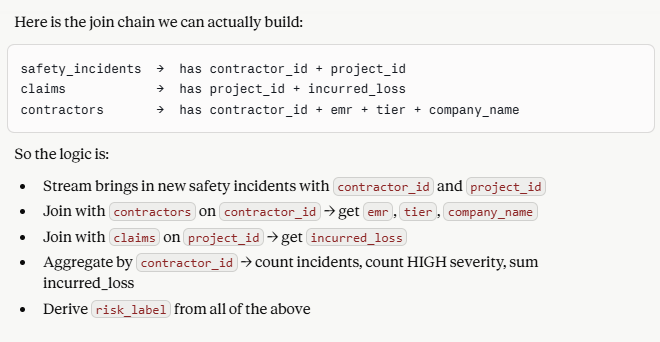

In [59]:
# Verify join key formats match across tables
print("=== safety_incidents — contractor_id + project_id samples ===")
safety_incidents.select("contractor_id", "project_id").show(3)

print("=== contractors — contractor_id samples ===")
contractors.select("contractor_id").show(3)

print("=== claims — project_id + incurred_loss samples ===")
claims.select("project_id", "incurred_loss").show(3)

=== safety_incidents — contractor_id + project_id samples ===
+-------------+----------+
|contractor_id|project_id|
+-------------+----------+
|    CON-01000| PRJ-00097|
|    CON-01264| PRJ-00175|
|    CON-00751| PRJ-00154|
+-------------+----------+
only showing top 3 rows

=== contractors — contractor_id samples ===
+-------------+
|contractor_id|
+-------------+
|    CON-00001|
|    CON-00002|
|    CON-00003|
+-------------+
only showing top 3 rows

=== claims — project_id + incurred_loss samples ===
+----------+-------------+
|project_id|incurred_loss|
+----------+-------------+
| PRJ-00081|    120752.80|
| PRJ-00110|   1096690.44|
| PRJ-00188|    225475.90|
+----------+-------------+
only showing top 3 rows



In [60]:
# Transformation 2: Multi-Table Stream Join + Aggregation + Risk Label ──
import os, json, time

# ── Step 1: Define schema for incoming streaming JSON files ────────────
incident_schema = StructType([
    StructField("incident_id",   StringType(),  True),  # INC-XXXXX format
    StructField("contractor_id", StringType(),  True),  # CON-XXXXX format
    StructField("project_id",    StringType(),  True),  # PRJ-XXXXX format — needed to join claims
    StructField("incident_type", StringType(),  True),
    StructField("severity",      StringType(),  True),
    StructField("event_time",    StringType(),  True)
])

# ── Step 2: Create fresh folder for this transformation ───────────────
os.makedirs("/content/stream_risk", exist_ok=True)

# ── Step 3: Read stream from folder ───────────────────────────────────
incident_stream = spark.readStream \
  .format("json")\
  .schema(incident_schema)\
  .option("maxFilePerTrigger", 1)\
  .load("/content/stream_risk")

# ── Step 4: Pre-aggregate claims BEFORE joining ───────────────────────
# claims has one row per claim — one project can have many claims
# We collapse it to one row per project with total incurred loss
# If we don't do this, the join would multiply rows and give wrong counts

claims_agg = claims \
  .groupBy("project_id")\
  .agg(
      F.sum("incurred_loss").alias("total_incurred_loss"),
      F.count("claim_id").alias("total_claims")
  )

# ── Step 5: Prepare contractors static table ──────────────────────────
contractors_static = contractors.select(
    "contractor_id",
    "company_name",
    "emr",    # keep emr as-is — no cast here, cast after join
    "tier"
)

# ── Step 6: Join stream with contractors ──────────────────────────────
enriched = incident_stream.join(
    contractors_static,
    on="contractor_id",
    how="left"
) \
.withColumn("emr", F.col("emr").cast("double"))  # cast emr AFTER join — avoids Spark dropping it

# ── Step 7: Join enriched stream with pre-aggregated claims ───────────
# Now we bring in total_incurred_loss and total_claims per project

enriched_with_claims = enriched.join(
    claims_agg,
    on="project_id",
    how="left"
)

# ── Step 8: Aggregate by contractor ───────────────────────────────────
risk_agg = enriched_with_claims \
    .groupBy(
        "contractor_id",
        "company_name",
        "tier"
        # removed emr from groupBy — use first() instead below
    ) \
    .agg(
        F.first("emr").alias("emr"),                                              # take first EMR value for this contractor
        F.count("incident_id").alias("total_incidents"),
        F.sum(F.when(F.col("severity") == "HIGH", 1).otherwise(0))
         .alias("high_severity_count"),
        F.sum("total_incurred_loss").alias("total_incurred_loss"),
        F.sum("total_claims").alias("total_claims")
    )

  # ── Step 9: Derive risk label using business logic ────────────────────
# This is the intelligence layer — combining EMR + severity + claim amount
# into one human readable risk classification
risk_scored = risk_agg.withColumn(
    "risk_label",
    F.when(
        (F.col("high_severity_count") > 2) |   # more than 2 HIGH severity incidents OR
        (F.col("emr") > 1.5) |                 # EMR above 1.5 (very risky contractor) OR
        (F.col("total_incurred_loss") > 500000) # over 500k in losses
        , "CRITICAL"
    ).when(
        (F.col("high_severity_count") > 0) |   # at least 1 HIGH severity incident OR
        (F.col("emr") > 1.0) |                 # EMR above 1.0 (moderate risk) OR
        (F.col("total_incurred_loss") > 100000) # over 100k in losses
        , "WATCH"
    ).otherwise("OKAY")                         # everything else is fine
)

# ── Step 10: Select final columns in clean order ──────────────────────
final = risk_scored.select(
    "contractor_id",
    "company_name",
    "tier",
    "emr",
    "total_incidents",
    "high_severity_count",
    "total_claims",
    "total_incurred_loss",
    "risk_label"       # this is the final derived intelligence column
)

# ── Step 11: Write to memory ──────────────────────────────────────────
query_risk = final.writeStream \
    .format("memory") \
    .queryName("contractor_risk_scorecard") \
    .outputMode("complete") \
    .start()

print("Stream started:", query_risk.isActive)

Stream started: True


In [61]:
# ── CELL 6b — Drop Files + Query Risk Scorecard ───────────────────────

import os, json, time

# ── Step 1: Drop incident files with real NovaBuild IDs ───────────────
# Using real contractor_id and project_id formats from our database
incidents = [
    {"incident_id": "INC-001", "contractor_id": "CON-00001", "project_id": "PRJ-00081", "incident_type": "FALL",     "severity": "HIGH",   "event_time": "2024-01-15 09:00:00"},
    {"incident_id": "INC-002", "contractor_id": "CON-00001", "project_id": "PRJ-00081", "incident_type": "ELECTRIC", "severity": "HIGH",   "event_time": "2024-01-15 09:05:00"},
    {"incident_id": "INC-003", "contractor_id": "CON-00001", "project_id": "PRJ-00081", "incident_type": "FIRE",     "severity": "HIGH",   "event_time": "2024-01-15 09:10:00"},
    {"incident_id": "INC-004", "contractor_id": "CON-00002", "project_id": "PRJ-00110", "incident_type": "FALL",     "severity": "MEDIUM", "event_time": "2024-01-15 09:15:00"},
    {"incident_id": "INC-005", "contractor_id": "CON-00003", "project_id": "PRJ-00188", "incident_type": "FIRE",     "severity": "LOW",    "event_time": "2024-01-15 09:20:00"},
]
# CON-00001 has 3 HIGH severity incidents — should come out as CRITICAL
# CON-00002 has 1 MEDIUM — should come out as OKAY or WATCH depending on EMR + claims
# CON-00003 has 1 LOW — should come out as OKAY or WATCH depending on EMR + claims

for i, record in enumerate(incidents):
    file_path = f"/content/stream_risk/incident_{i+1}.json"  # unique file name per incident
    with open(file_path, "w") as f:
        json.dump(record, f)                                  # write JSON to file
    print(f"Dropped: {file_path}")
    time.sleep(2)                                             # gap so Spark processes one file at a time

# ── Step 2: Wait for Spark to finish processing all files ─────────────
time.sleep(8)  # slightly longer wait — this query is more complex than before

# ── Step 3: Query the risk scorecard ──────────────────────────────────
spark.sql("""
    SELECT
        contractor_id,
        company_name,
        tier,
        emr,
        total_incidents,
        high_severity_count,
        total_claims,
        ROUND(total_incurred_loss, 2) as total_incurred_loss,
        risk_label
    FROM contractor_risk_scorecard
    ORDER BY
        CASE risk_label                -- order by risk priority
            WHEN 'CRITICAL' THEN 1
            WHEN 'WATCH'    THEN 2
            WHEN 'OKAY'     THEN 3
        END
""").show(truncate=False)
# CRITICAL contractors appear first, then WATCH, then OKAY
# This is how a real underwriting dashboard would prioritize alerts

Dropped: /content/stream_risk/incident_1.json
Dropped: /content/stream_risk/incident_2.json
Dropped: /content/stream_risk/incident_3.json
Dropped: /content/stream_risk/incident_4.json
Dropped: /content/stream_risk/incident_5.json
+-------------+-------------------------------------------+------------+----+---------------+-------------------+------------+-------------------+----------+
|contractor_id|company_name                               |tier        |emr |total_incidents|high_severity_count|total_claims|total_incurred_loss|risk_label|
+-------------+-------------------------------------------+------------+----+---------------+-------------------+------------+-------------------+----------+
|CON-00001    |Premier Plumbing Development Corp          |Preferred   |1.72|3              |3                  |90          |71826298.89        |CRITICAL  |
|CON-00002    |Summit General Contractor Building Services|Standard    |0.55|1              |0                  |18          |13777218.10 

In [62]:
# Stop current stream
query_risk.stop()
print("Stream stopped:", query_risk.isActive)  # should print False

Stream stopped: False


**Transformation 3 of 5 — Watermarking**

**The Story First**
Imagine you are managing a complaint register at a construction site. Every time an incident happens, a worker fills out a form and drops it in your inbox.

Now here is the problem — some workers are slow. An incident happened at 9:00 AM but the worker only filled the form and dropped it at 9:45 AM. By that time, you have already closed and summarized the 9:00 AM to 9:30 AM window.

Now what do you do with that late form?

Option 1 — Throw it away. Ignore it. The window is closed.

Option 2 — Wait forever for late forms before closing any window. But then you never produce results.

Option 3 — Set a rule: "I will wait maximum 10 minutes for late forms. Anything arriving after 10 minutes of the window closing gets thrown away. Anything within 10 minutes gets included."

Option 3 is exactly what Watermarking does in Spark.

**The Technical Meaning**

In streaming, data arrives with an event timestamp — the time the incident actually happened. But Spark processes it at a different time — the time the file arrived.

These two times are almost never the same in real life. Network delays, system lag, slow sensors — events always arrive late.

**Watermarking tells Spark:**

"For any event with timestamp T, I will keep the window open for T + 10 minutes. After that, discard late arrivals for that window."

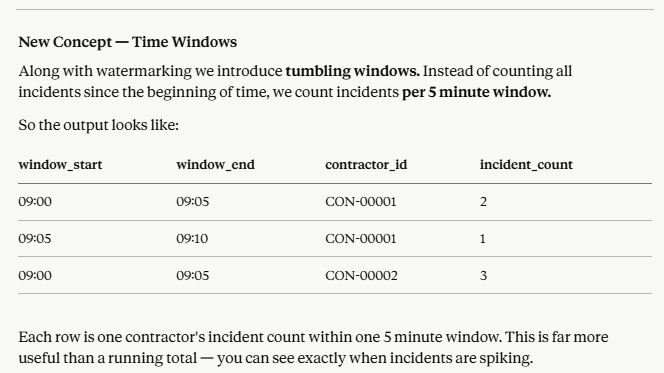

In [63]:
# ── Transformation 3: Watermarking + Tumbling Windows ────────

import os, json, time

# ── Step 1: Define schema — event_time must be TimestampType for windowing ──
incident_schema = StructType([
    StructField("incident_id",   StringType(),    True),
    StructField("contractor_id", StringType(),    True),
    StructField("project_id",    StringType(),    True),
    StructField("incident_type", StringType(),    True),
    StructField("severity",      StringType(),    True),
    StructField("event_time",    TimestampType(), True)  # MUST be Timestamp — not String like before
])                                                       # windowing only works on actual timestamp columns

# ── Step 2: Create fresh folder ───────────────────────────────────────
os.makedirs("/content/stream_watermark", exist_ok=True)

# ── Step 3: Read stream ───────────────────────────────────────────────
incident_stream = spark.readStream \
    .format("json") \
    .schema(incident_schema) \
    .option("maxFilesPerTrigger", 1) \
    .load("/content/stream_watermark")
# ── Step 4: Apply watermark on event_time ─────────────────────────────
water_marked = incident_stream \
  .withWatermark("event_time", "10 minutes")

# This tells Spark: "for any event, wait up to 10 minutes for late arrivals"
# If an event arrives more than 10 minutes after its event_time window closed — discard it
# If it arrives within 10 minutes — include it in the correct window

# ── Step 5: Apply tumbling window + groupBy ───────────────────────────
windowed_count = water_marked\
  .groupBy(
      F.window("event_time", "5 minutes"),  # divide time into 5 minute buckets
      "contractor_id",                     # group by contractor within each bucket
      "severity"                             # also break down by severity
  )\
  .agg(
      F.count("incident_id").alias("incident_count"),                        # how many incidents in this window
        F.sum(F.when(F.col("severity") == "HIGH", 1).otherwise(0))
         .alias("high_severity_count")                                         # how many were HIGH in this window
  )
# F.window("event_time", "5 minutes") creates a struct with window.start and window.end
# Each unique combination of (5min bucket + contractor_id + severity) = one row
# ── Step 6: Flatten the window struct into readable columns ───────────
final = windowed_count.select(
    F.col("window.start").alias("window_start"),  # extract start time from window struct
    F.col("window.end").alias("window_end"),       # extract end time from window struct
    "contractor_id",
    "severity",
    "incident_count",
    "high_severity_count"
)

# ── Step 7: Write to memory ───────────────────────────────────────────
query_watermark = final.writeStream \
    .format("memory") \
    .queryName("windowed_incidents") \
    .outputMode("complete") \
    .start()

print("Stream started:", query_watermark.isActive)

Stream started: True


In [64]:
# ── CELL 7b — Drop Files with Spread Timestamps + Query ───────────────

# ── Step 1: Drop incident files with deliberate timestamp spread ───────
incidents = [
    # Window 1 — 09:00 to 09:05
    {"incident_id": "INC-001", "contractor_id": "CON-00001", "project_id": "PRJ-00081", "incident_type": "FALL",     "severity": "HIGH",   "event_time": "2024-01-15T09:01:00"},
    {"incident_id": "INC-002", "contractor_id": "CON-00001", "project_id": "PRJ-00081", "incident_type": "FIRE",     "severity": "HIGH",   "event_time": "2024-01-15T09:03:00"},
    {"incident_id": "INC-003", "contractor_id": "CON-00002", "project_id": "PRJ-00110", "incident_type": "FALL",     "severity": "MEDIUM", "event_time": "2024-01-15T09:04:00"},

    # Window 2 — 09:05 to 09:10
    {"incident_id": "INC-004", "contractor_id": "CON-00001", "project_id": "PRJ-00081", "incident_type": "ELECTRIC", "severity": "HIGH",   "event_time": "2024-01-15T09:06:00"},
    {"incident_id": "INC-005", "contractor_id": "CON-00002", "project_id": "PRJ-00110", "incident_type": "FIRE",     "severity": "LOW",    "event_time": "2024-01-15T09:08:00"},

    # Late arriving event — event_time is 09:03 but arrives AFTER window 2 events
    # Watermark is 10 minutes — this is only 7 minutes late so it WILL be included
    {"incident_id": "INC-006", "contractor_id": "CON-00003", "project_id": "PRJ-00188", "incident_type": "FALL",     "severity": "HIGH",   "event_time": "2024-01-15T09:03:00"},
]
# INC-006 has event_time 09:03 — belongs to Window 1
# But it arrives after INC-004 and INC-005 which are Window 2 events
# Since it is within 10 minute watermark — Spark will still include it in Window 1

for i, record in enumerate(incidents):
    file_path = f"/content/stream_watermark/incident_{i+1}.json"  # unique file per incident
    with open(file_path, "w") as f:
        json.dump(record, f)                                       # write to watched folder
    print(f"Dropped: {file_path}")
    time.sleep(2)                                                  # gap between files

# ── Step 2: Wait for Spark to finish processing ───────────────────────
time.sleep(10)  # longer wait — watermark calculations need more time

# ── Step 3: Query windowed results ────────────────────────────────────
spark.sql("""
    SELECT
        window_start,
        window_end,
        contractor_id,
        severity,
        incident_count,
        high_severity_count
    FROM windowed_incidents
    ORDER BY
        window_start,       -- earliest window first
        contractor_id,      -- then by contractor
        severity            -- then by severity
""").show(truncate=False)

Dropped: /content/stream_watermark/incident_1.json
Dropped: /content/stream_watermark/incident_2.json
Dropped: /content/stream_watermark/incident_3.json
Dropped: /content/stream_watermark/incident_4.json
Dropped: /content/stream_watermark/incident_5.json
Dropped: /content/stream_watermark/incident_6.json
+-------------------+-------------------+-------------+--------+--------------+-------------------+
|window_start       |window_end         |contractor_id|severity|incident_count|high_severity_count|
+-------------------+-------------------+-------------+--------+--------------+-------------------+
|2024-01-15 09:00:00|2024-01-15 09:05:00|CON-00001    |HIGH    |2             |2                  |
|2024-01-15 09:00:00|2024-01-15 09:05:00|CON-00002    |MEDIUM  |1             |0                  |
|2024-01-15 09:00:00|2024-01-15 09:05:00|CON-00003    |HIGH    |1             |1                  |
|2024-01-15 09:05:00|2024-01-15 09:10:00|CON-00001    |HIGH    |1             |1              

**Transformation 3 — Watermarking + Tumbling Windows**

What is this doing?

Spark watches a folder for incoming incident JSON files. Each file carries an event_time — the actual time the incident happened on site. Spark groups incidents into 5 minute time windows and counts them per contractor per severity. The 10 minute watermark tells Spark to wait up to 10 minutes for late arriving events before finalizing any window.

Why is this useful?

In real construction sites, data arrives late due to network issues, remote locations, and slow sensors. Without watermarking, late events either land in the wrong window or get dropped entirely. Watermarking gives Spark a tolerance threshold — accept late data up to 10 minutes, discard anything later than that.
The Flow
1. New JSON file lands in folder
        ↓
2. Spark reads event_time from each record
        ↓
3. withWatermark("event_time", "10 minutes") — sets late arrival tolerance
        ↓
4. F.window("event_time", "5 minutes") — buckets events into 5 min windows
        ↓
5. groupBy(window, contractor_id, severity) — counts per bucket
        ↓
6. Late event INC-006 arrives — event_time 09:03 — within watermark — included in Window 1
        ↓
7. Results written to memory — queryable with spark.sql()
Key Concepts

withWatermark("event_time", "10 minutes") — sets the late arrival tolerance on the timestamp column

F.window("event_time", "5 minutes") — creates tumbling 5 minute buckets based on event_time

window.start and window.end — extract readable timestamps from the window struct

outputMode("complete") — required when using watermark with aggregations

Late event within watermark → included in correct window

Late event beyond watermark → silently discarded

**What to notice in the output**

INC-006 has event_time 09:03 — belongs to Window 1
It arrived on disk after Window 2 events — but Spark still placed it correctly in Window 1

That is watermarking working — event placement based on when it happened, not when it arrived

In [65]:
# Stop watermark stream
query_watermark.stop()
print("Stream stopped:", query_watermark.isActive)  # should print False

Stream stopped: False


**Transformation 4 of 5 — Your Turn**

**Business Problem Statement**

NovaBuild's broker performance team wants a live scorecard that tracks how each broker is performing in terms of claims activity.

Every time a new claim event arrives via stream, they want to see:

1. broker_id
2. broker_name — from the brokers table
3. total_claims — count of all claims
4. total_incurred_loss — sum of incurred_loss
5. avg_incurred_loss — average loss per claim
6. high_value_claims — count of claims where incurred_loss > 100,000
7. performance_label — your derived intelligence column:

**Condition	Label**
1. avg_incurred_loss > 500,000 OR high_value_claims > 5	POOR
2. avg_incurred_loss > 100,000 OR high_value_claims > 2	AVERAGE
3. Everything else	GOOD


**The Plan — I Give You This, Code is Yours**

Stream brings in: new claim JSON files with claim_id, broker_id, incurred_loss, claim_type, event_time

Static join with: brokers table — to get broker name

Aggregate by: broker_id, broker_name

Compute: total_claims, total_incurred_loss, avg_incurred_loss, high_value_claims

Derive: performance_label using the logic above

Output mode: complete

Query name: broker_scorecard

**Hints**
1. Check brokers table columns first — brokers.columns
2. Folder name: /content/stream_broker
3. For high_value_claims use F.sum(F.when(F.col("incurred_loss") > 100000, 1).otherwise(0))
4. For avg_incurred_loss use F.avg("incurred_loss").alias("avg_incurred_loss")
5. Cast incurred_loss as DoubleType() in schema — it is a decimal value
6. Same stream-static join pattern as Transformation 1 and 2
7. Same EMR cast lesson applies — do not cast inside static select, cast after join using withColumn

In [66]:
# Check brokers table columns
print("=== BROKERS ===")
print(brokers.columns)
brokers.show(3)


=== BROKERS ===
['broker_id', 'broker_name', 'firm_name', 'license_number', 'state', 'email', 'phone', 'years_experience', 'specialty', 'active']
+---------+---------------+--------------------+--------------+-----+--------------------+--------------+----------------+----------------+------+
|broker_id|    broker_name|           firm_name|license_number|state|               email|         phone|years_experience|       specialty|active|
+---------+---------------+--------------------+--------------+-----+--------------------+--------------+----------------+----------------+------+
|BRK-00001|   Thomas Davis|       USI Insurance|    LIC-179046|   NC|thomas.davis@corp...|(300) 251-9856|               3|Wrap-Up Programs| false|
|BRK-00002| Barbara Thomas|Gallagher Constru...|    LIC-609231|   NC|barbara.thomas@gm...|(610) 260-3697|              15|Wrap-Up Programs| false|
|BRK-00003|Thomas Martinez|       USI Insurance|    LIC-543555|   WA|thomas.martinez@c...|(769) 877-8973|              

In [67]:
# ── CELL 8 — Transformation 4: Broker Performance Scorecard ───────────
import os, json, time

# Step 1: Schema — fix incurred_loss to DoubleType
incident_schema = StructType([
    StructField("claim_id",      StringType(), True),
    StructField("broker_id",     StringType(), True),
    StructField("incurred_loss", DoubleType(), True),  # ← fix this
    StructField("claim_type",    StringType(), True),
    StructField("event_time",    StringType(), True)
])

# ── Step 2: Create fresh folder for this transformation ───────────────
os.makedirs("/content/stream_broker", exist_ok=True)

# ── Step 3: Read stream from folder ───────────────────────────────────
incident_stream = spark.readStream \
  .format("json")\
  .schema(incident_schema)\
  .option("maxFilesPerTrigger", 1)\
  .load("/content/stream_broker")

# Step 4: Prepare brokers static table — select only what you need
brokers_static = brokers.select(
    "broker_id", "broker_name", "firm_name", "state"
)

# Step 5: Join stream with brokers_static
enriched = incident_stream.join(
    brokers_static,
    on="broker_id",
    how="left"
)


# Step 6: GroupBy and aggregate
scored = enriched \
    .groupBy("broker_id", "broker_name", "firm_name") \
    .agg(
        F.sum("incurred_loss").alias("total_incurred_loss"),
        F.count("claim_id").alias("total_claims"),
        F.avg("incurred_loss").alias("avg_incurred_loss"),
        F.sum(F.when(F.col("incurred_loss") > 100000, 1).otherwise(0)).alias("high_value_claims")
  )

# Step 7: Add performance_label
final = scored.withColumn(
    "performance_label",
    F.when(
    (F.col("avg_incurred_loss") > 500000) |   # ← condition 1 wrapped
    (F.col("high_value_claims") > 5),          # ← condition 2 wrapped
    "Poor"
).when(
    (F.col("avg_incurred_loss") > 100000) |   # ← condition 1 wrapped
    (F.col("high_value_claims") > 2),          # ← condition 2 wrapped
    "Average"
).otherwise("Good")
)

# Step 8: Write to memory
query_broker = final.writeStream \
    .format("memory") \
    .queryName("broker_scorecard") \
    .outputMode("complete") \
    .start()

print("Stream started:", query_broker.isActive)

Stream started: True


In [68]:
# ── CELL 8b — Drop Files + Query Broker Scorecard ─────────────────────

# ── Step 1: Drop claim files with real broker IDs ─────────────────────
claims_data = [
    {"claim_id": "CLM-001", "broker_id": "BRK-00001", "incurred_loss": 650000.00, "claim_type": "Property",  "event_time": "2024-01-15T09:00:00"},
    {"claim_id": "CLM-002", "broker_id": "BRK-00001", "incurred_loss": 720000.00, "claim_type": "Liability", "event_time": "2024-01-15T09:05:00"},
    {"claim_id": "CLM-003", "broker_id": "BRK-00001", "incurred_loss": 480000.00, "claim_type": "Property",  "event_time": "2024-01-15T09:10:00"},
    {"claim_id": "CLM-004", "broker_id": "BRK-00002", "incurred_loss": 95000.00,  "claim_type": "Liability", "event_time": "2024-01-15T09:15:00"},
    {"claim_id": "CLM-005", "broker_id": "BRK-00002", "incurred_loss": 110000.00, "claim_type": "Property",  "event_time": "2024-01-15T09:20:00"},
    {"claim_id": "CLM-006", "broker_id": "BRK-00003", "incurred_loss": 45000.00,  "claim_type": "Liability", "event_time": "2024-01-15T09:25:00"},
]

for i, record in enumerate(claims_data):
    file_path = f"/content/stream_broker/claim_{i+1}.json"  # unique file name per claim
    with open(file_path, "w") as f:
        json.dump(record, f)                                 # write JSON to watched folder
    print(f"Dropped: {file_path}")
    time.sleep(2)                                            # gap so Spark processes one at a time

# ── Step 2: Wait for Spark to finish processing ───────────────────────
time.sleep(8)

# ── Step 3: Query broker scorecard ────────────────────────────────────
spark.sql("""
    SELECT
        broker_id,
        broker_name,
        firm_name,
        total_claims,
        ROUND(total_incurred_loss, 2)  AS total_incurred_loss,
        ROUND(avg_incurred_loss, 2)    AS avg_incurred_loss,
        high_value_claims,
        performance_label
    FROM broker_scorecard
    ORDER BY
        CASE performance_label
            WHEN 'Poor'    THEN 1
            WHEN 'Average' THEN 2
            WHEN 'Good'    THEN 3
        END
""").show(truncate=False)

Dropped: /content/stream_broker/claim_1.json
Dropped: /content/stream_broker/claim_2.json
Dropped: /content/stream_broker/claim_3.json
Dropped: /content/stream_broker/claim_4.json
Dropped: /content/stream_broker/claim_5.json
Dropped: /content/stream_broker/claim_6.json
+---------+---------------+----------------------+------------+-------------------+-----------------+-----------------+-----------------+
|broker_id|broker_name    |firm_name             |total_claims|total_incurred_loss|avg_incurred_loss|high_value_claims|performance_label|
+---------+---------------+----------------------+------------+-------------------+-----------------+-----------------+-----------------+
|BRK-00001|Thomas Davis   |USI Insurance         |3           |1850000.0          |616666.67        |3                |Poor             |
|BRK-00002|Barbara Thomas |Gallagher Construction|2           |205000.0           |102500.0         |1                |Average          |
|BRK-00003|Thomas Martinez|USI Insurance

In [69]:
# Stop broker stream
query_broker.stop()
print("Stream stopped:", query_broker.isActive)  # should print False


Stream stopped: False


In [70]:
print("=== CARRIERS ===")
print(carriers.columns)
carriers.show(3)

=== CARRIERS ===
['carrier_id', 'carrier_name', 'am_best_rating', 'state_licensed', 'contact_name', 'contact_email', 'contact_phone', 'active']
+----------+--------------------+--------------+--------------------+------------------+----------------+--------------+------+
|carrier_id|        carrier_name|am_best_rating|      state_licensed|      contact_name|   contact_email| contact_phone|active|
+----------+--------------------+--------------+--------------------+------------------+----------------+--------------+------+
| CAR-00001|Zurich North America|           A++|WA,IL,NY,TN,CA,FL...|Christopher Thomas|   uw@zurich.com|(232) 230-2535|  true|
| CAR-00002|    AIG Construction|            A+|PA,AZ,TX,MN,NY,WA...|      James Garcia|      uw@aig.com|(914) 632-6574|  true|
| CAR-00003| Travelers Companies|             A|NY,TN,OH,FL,WA,GA...|   Betty Rodriguez|uw@travelers.com|(244) 947-8527|  true|
+----------+--------------------+--------------+--------------------+------------------+

In [71]:
#Transformation 5:  Live carrier risk exposure dashboard ───────────
import os, json, time
from pyspark.sql.functions import broadcast
# Step 1: Schema — fix incurred_loss to DoubleType
carrier_schema = StructType([
    StructField("policy_id", StringType(), True),
    StructField("carrier_id", StringType(), True),
    StructField("total_insured_value", DoubleType(), True),
    StructField("annual_premium", DoubleType(), True),
    StructField("policy_type", StringType(), True),
    StructField("event_time", StringType(), True)
])

# ── Step 2: Create fresh folder for this transformation ───────────────
os.makedirs("/content/stream_carrier", exist_ok=True)

# ── Step 3: Read stream from folder ───────────────────────────────────
carrier_stream = spark.readStream \
  .format("json")\
  .schema(carrier_schema)\
  .option("maxFilesPerTrigger", 1)\
  .load("/content/stream_carrier")

# Step 4: Prepare brokers static table — select only what you need
carrier_static = carriers.select(
    "carrier_id", "carrier_name", "am_best_rating",
)

# Step 5: Join stream with brokers_static
enriched = carrier_stream.join(
    broadcast(carrier_static),
    on="carrier_id",
    how="left"
)


# Step 6: GroupBy and aggregate
scored = enriched \
    .groupBy("carrier_id", "carrier_name", "am_best_rating") \
    .agg(
        F.count("policy_id").alias("total_policies"),
        F.sum("total_insured_value").alias("total_insured_value"),
        F.sum("annual_premium").alias("total_premium"),
        F.sum(F.when(F.col("total_insured_value") > 1000000, 1).otherwise(0)).alias("high_exposure_policies"),
        (F.sum("total_insured_value") / F.sum("annual_premium")).alias("exposure_ratio")
    )

# Step 7: Add performance_label
final = scored.withColumn(
    "risk_label",
    F.when(
    (F.col("exposure_ratio") > 50) |
    (F.col("high_exposure_policies") > 10),
    "CRITICAL"
    ).when(
      (F.col("exposure_ratio") > 20) |
      (F.col("high_exposure_policies") > 5),
      "ELEVATED"
  ).otherwise("NORMAL")
)

# Step 8: Write to memory
query_carrier = final.writeStream \
    .format("memory") \
    .queryName("carrier_exposure") \
    .outputMode("complete") \
    .option("checkpointLocation", "/content/checkpoints/carrier_exposure") \
    .start()

print("Stream started:", query_carrier.isActive)

Stream started: True


In [72]:
# ── CELL 9b — Drop Files + Query Carrier Exposure Dashboard ───────────

# ── Step 1: Drop policy files with real carrier IDs ───────────────────
policies_data = [
    {"policy_id": "POL-001", "carrier_id": "CAR-00001", "total_insured_value": 2500000.00, "annual_premium": 45000.00, "policy_type": "Property",  "event_time": "2024-01-15T09:00:00"},
    {"policy_id": "POL-002", "carrier_id": "CAR-00001", "total_insured_value": 1800000.00, "annual_premium": 32000.00, "policy_type": "Liability", "event_time": "2024-01-15T09:05:00"},
    {"policy_id": "POL-003", "carrier_id": "CAR-00001", "total_insured_value": 950000.00,  "annual_premium": 18000.00, "policy_type": "Property",  "event_time": "2024-01-15T09:10:00"},
    {"policy_id": "POL-004", "carrier_id": "CAR-00002", "total_insured_value": 3200000.00, "annual_premium": 58000.00, "policy_type": "Property",  "event_time": "2024-01-15T09:15:00"},
    {"policy_id": "POL-005", "carrier_id": "CAR-00002", "total_insured_value": 800000.00,  "annual_premium": 22000.00, "policy_type": "Liability", "event_time": "2024-01-15T09:20:00"},
    {"policy_id": "POL-006", "carrier_id": "CAR-00003", "total_insured_value": 450000.00,  "annual_premium": 35000.00, "policy_type": "Property",  "event_time": "2024-01-15T09:25:00"},
]

for i, record in enumerate(policies_data):
    file_path = f"/content/stream_carrier/policy_{i+1}.json"  # unique file name per policy
    with open(file_path, "w") as f:
        json.dump(record, f)                                   # write JSON to watched folder
    print(f"Dropped: {file_path}")
    time.sleep(2)                                              # gap so Spark processes one at a time

# ── Step 2: Wait for Spark to finish processing ───────────────────────
time.sleep(8)

# ── Step 3: Query carrier exposure dashboard ──────────────────────────
spark.sql("""
    SELECT
        carrier_id,
        carrier_name,
        am_best_rating,
        total_policies,
        ROUND(total_insured_value, 2)  AS total_insured_value,
        ROUND(total_premium, 2)        AS total_premium,
        high_exposure_policies,
        ROUND(exposure_ratio, 2)       AS exposure_ratio,
        risk_label
    FROM carrier_exposure
    ORDER BY
        CASE risk_label
            WHEN 'CRITICAL' THEN 1
            WHEN 'ELEVATED' THEN 2
            WHEN 'NORMAL'   THEN 3
        END
""").show(truncate=False)

Dropped: /content/stream_carrier/policy_1.json
Dropped: /content/stream_carrier/policy_2.json
Dropped: /content/stream_carrier/policy_3.json
Dropped: /content/stream_carrier/policy_4.json
Dropped: /content/stream_carrier/policy_5.json
Dropped: /content/stream_carrier/policy_6.json
+----------+--------------------+--------------+--------------+-------------------+-------------+----------------------+--------------+----------+
|carrier_id|carrier_name        |am_best_rating|total_policies|total_insured_value|total_premium|high_exposure_policies|exposure_ratio|risk_label|
+----------+--------------------+--------------+--------------+-------------------+-------------+----------------------+--------------+----------+
|CAR-00001 |Zurich North America|A++           |3             |5250000.0          |95000.0      |2                     |55.26         |CRITICAL  |
|CAR-00002 |AIG Construction    |A+            |2             |4000000.0          |80000.0      |1                     |50.0      

In [73]:
# Stop carrier stream
query_carrier.stop()
print("Stream stopped:", query_carrier.isActive)

Stream stopped: False


In [74]:
# ════════════════════════════════════════════════════════════════════════
# SECTION 8.10 — STRUCTURED STREAMING — SUMMARY
# ════════════════════════════════════════════════════════════════════════

# ── CORE CONCEPTS COVERED ─────────────────────────────────────────────

# 1. RATE SOURCE (Cells 1-3)
#    Spark generates fake data at a fixed rate
#    Good for testing — not used in production
#    spark.readStream.format("rate")

# 2. FILE STREAM (Cell 4)
#    Spark watches a folder for new JSON/CSV/Parquet files
#    Picks up each new file automatically as it arrives
#    Schema must be defined manually — Spark won't guess it
#    spark.readStream.format("json").schema(...).load("/folder")

# 3. STREAM-STATIC JOIN (Transformation 1)
#    Stream on left, static table on right
#    Enriches raw events with reference data in real time
#    Always broadcast small static tables
#    Never cast inside static select — cast after join using withColumn

# 4. MULTI-TABLE JOIN + AGGREGATION + BUSINESS LOGIC (Transformation 2)
#    Pre-aggregate static tables before joining to avoid row multiplication
#    groupBy on stream produces running totals — updates every micro-batch
#    Derive intelligence columns using F.when business logic
#    outputMode("complete") required for aggregations

# 5. WATERMARKING + TUMBLING WINDOWS (Transformation 3)
#    withWatermark("event_time", "10 minutes") — late arrival tolerance
#    F.window("event_time", "5 minutes") — tumbling 5 min buckets
#    Events placed in correct window based on event_time, not arrival time
#    Late events within watermark — included
#    Late events beyond watermark — discarded
#    event_time must be TimestampType — not StringType

# 6. BROADCAST JOIN IN STREAMS (Transformations 4 + 5)
#    Always broadcast small static tables in stream-static joins
#    carriers (15 rows), brokers (40 rows), sponsors (80 rows)
#    from pyspark.sql.functions import broadcast
#    stream.join(broadcast(static_table), on="key", how="left")

# 7. CHECKPOINT (Transformation 5)
#    Mandatory in production — tracks which micro-batches were processed
#    If stream crashes — resumes from exactly where it stopped
#    .option("checkpointLocation", "/content/checkpoints/query_name")

# ── OUTPUT MODES — QUICK REFERENCE ───────────────────────────────────
# append   — only new rows added each micro-batch (no aggregation)
# complete — entire result table rewritten each micro-batch (aggregation)
# update   — only changed rows rewritten each micro-batch (aggregation)

# ── SINK TYPES — QUICK REFERENCE ─────────────────────────────────────
# memory   — in-memory table, queryable with spark.sql() — testing only
# delta    — production grade, ACID, queryable — covered in Cell 10
# kafka    — pass enriched stream to another system — enterprise level
# jdbc     — write results back to operational database

# ── STREAM LIFECYCLE ──────────────────────────────────────────────────
# query = df.writeStream.start()   — starts the stream
# query.isActive                   — check if running
# query.stop()                     — stop the stream cleanly

# ── WHAT WE BUILT — 5 TRANSFORMATIONS ────────────────────────────────
# T1 — Stream-Static Join — enrich incidents with contractor details
# T2 — Multi-table join + risk scoring — live contractor risk scorecard
# T3 — Watermarking + windows — 5 min incident counts with late data handling
# T4 — Broker performance scorecard — you wrote this
# T5 — Carrier risk exposure dashboard — you wrote this with broadcast + checkpoint

# ── PRODUCTION CHECKLIST ──────────────────────────────────────────────
# ✅ Define schema manually for file streams
# ✅ Use maxFilesPerTrigger for controlled processing
# ✅ Broadcast small static tables in joins
# ✅ Cast after join — never inside static select
# ✅ Pre-aggregate static tables before joining to stream
# ✅ Use withWatermark for late arriving data
# ✅ Always add checkpointLocation in production
# ✅ Use Delta sink in production — not memory

print("Section 8.10 — Structured Streaming — Complete")

Section 8.10 — Structured Streaming — Complete


#Delta Sink

**The Story**

Everything we have built so far writes to memory sink. That means the moment you stop the stream or restart Colab — everything is gone. No trace. No history. Nothing.

In production, nobody writes to memory. That is like doing all your work on a whiteboard and then wiping it clean at the end of the day.

Delta Lake is the production sink. When you write a stream to Delta:

1. Every micro-batch gets written as a Delta transaction
2. Data is persisted on disk — survives crashes and restarts
3. You can query it anytime with spark.read.format("delta")
4. Full ACID guarantees — no partial writes, no corruption
5. Combined with checkpoint — if stream crashes, it resumes exactly where it stopped and writes continue from that point

This is what every real production streaming pipeline looks like at the end:
Stream → transformations → writeStream.format("delta") → Delta table on disk

**One New Concept — foreachBatch**

There is one limitation with writing aggregations to Delta in streaming mode — Delta sink does not natively support complete output mode with aggregations in all Spark versions.

The solution is foreachBatch. Instead of Spark writing automatically, you tell Spark:

**"For each micro-batch, call this function. Inside the function, I will handle the write myself."**

This gives you full control. You can write to Delta, add extra logic, write to multiple sinks — anything you want.

In [75]:
# ── CELL 10 — Delta Sink — Production Streaming Pattern ───────────────

import os, json, time
from pyspark.sql.functions import broadcast

# ── Step 1: Define Delta path where stream output will be written ──────
STREAMING_DELTA_PATH = "/content/novabuild_delta/contractor_risk_live"
# This is where the Delta table will live on disk
# Every micro-batch will write here — persisted, queryable, versioned

# ── Step 2: Define schema for incoming JSON files ─────────────────────
incident_schema = StructType([
    StructField("incident_id",   StringType(), True),
    StructField("contractor_id", StringType(), True),
    StructField("project_id",    StringType(), True),
    StructField("incident_type", StringType(), True),
    StructField("severity",      StringType(), True),
    StructField("event_time",    StringType(), True)
])

# ── Step 3: Create fresh folder to watch ──────────────────────────────
os.makedirs("/content/stream_delta", exist_ok=True)

# ── Step 4: Read stream ───────────────────────────────────────────────
incident_stream = spark.readStream \
    .format("json") \
    .schema(incident_schema) \
    .option("maxFilesPerTrigger", 1) \
    .load("/content/stream_delta")       # Spark watches this folder

# ── Step 5: Prepare static tables ─────────────────────────────────────
contractors_static = contractors.select(
    "contractor_id",
    "company_name",
    "emr",      # no cast here — cast after join
    "tier"
)

claims_agg = claims \
    .groupBy("project_id") \
    .agg(
        F.sum("incurred_loss").alias("total_incurred_loss"),  # total loss per project
        F.count("claim_id").alias("total_claims")             # total claims per project
    )

# ── Step 6: Join stream with contractors ──────────────────────────────
enriched = incident_stream.join(
    broadcast(contractors_static),  # broadcast — contractors is small, 1500 rows
    on="contractor_id",
    how="left"
) \
.withColumn("emr", F.col("emr").cast("double"))  # cast after join — lesson learned

# ── Step 7: Join with pre-aggregated claims ───────────────────────────
enriched_with_claims = enriched.join(
    broadcast(claims_agg),   # broadcast — pre-aggregated claims is small
    on="project_id",
    how="left"
)

# ── Step 8: Aggregate by contractor ───────────────────────────────────
risk_agg = enriched_with_claims \
    .groupBy("contractor_id", "company_name", "tier") \
    .agg(
        F.first("emr").alias("emr"),                                        # one EMR per contractor
        F.count("incident_id").alias("total_incidents"),                    # total incidents
        F.sum(F.when(F.col("severity") == "HIGH", 1).otherwise(0))
         .alias("high_severity_count"),                                     # HIGH severity count
        F.sum("total_incurred_loss").alias("total_incurred_loss"),          # total losses
        F.sum("total_claims").alias("total_claims")                         # total claims
    )

# ── Step 9: Derive risk label ──────────────────────────────────────────
risk_scored = risk_agg.withColumn(
    "risk_label",
    F.when(
        (F.col("high_severity_count") > 2) |
        (F.col("emr") > 1.5) |
        (F.col("total_incurred_loss") > 500000),
        "CRITICAL"
    ).when(
        (F.col("high_severity_count") > 0) |
        (F.col("emr") > 1.0) |
        (F.col("total_incurred_loss") > 100000),
        "WATCH"
    ).otherwise("OKAY")
)

# ── Step 10: Define foreachBatch function ─────────────────────────────
def write_to_delta(batch_df, batch_id):
    # batch_df — current micro-batch as a regular batch DataFrame
    # batch_id — unique ID for this micro-batch, auto-increments each batch
    print(f"Writing batch {batch_id} to Delta...")
    batch_df.write \
        .format("delta") \
        .mode("overwrite") \
        .save(STREAMING_DELTA_PATH)
    print(f"Batch {batch_id} written successfully")

# ── Step 11: Write stream using foreachBatch ──────────────────────────
query_delta = risk_scored.writeStream \
    .outputMode("complete") \
    .foreachBatch(write_to_delta) \
    .option("checkpointLocation", "/content/checkpoints/contractor_risk_live") \
    .trigger(processingTime="10 seconds") \
    .start()
# Note: no .format() or .queryName() needed — foreachBatch handles the write

print("Stream started:", query_delta.isActive)  # should print True

Stream started: True


In [76]:
# ── CELL 10b — Drop Files + Read Results from Delta ───────────────────

import os, json, time

# ── Step 1: Drop incident files ───────────────────────────────────────
incidents = [
    {"incident_id": "INC-001", "contractor_id": "CON-00001", "project_id": "PRJ-00081", "incident_type": "FALL",     "severity": "HIGH",   "event_time": "2024-01-15T09:00:00"},
    {"incident_id": "INC-002", "contractor_id": "CON-00001", "project_id": "PRJ-00081", "incident_type": "ELECTRIC", "severity": "HIGH",   "event_time": "2024-01-15T09:05:00"},
    {"incident_id": "INC-003", "contractor_id": "CON-00001", "project_id": "PRJ-00081", "incident_type": "FIRE",     "severity": "HIGH",   "event_time": "2024-01-15T09:10:00"},
    {"incident_id": "INC-004", "contractor_id": "CON-00002", "project_id": "PRJ-00110", "incident_type": "FALL",     "severity": "MEDIUM", "event_time": "2024-01-15T09:15:00"},
    {"incident_id": "INC-005", "contractor_id": "CON-00003", "project_id": "PRJ-00188", "incident_type": "FIRE",     "severity": "LOW",    "event_time": "2024-01-15T09:20:00"},
]

for i, record in enumerate(incidents):
    file_path = f"/content/stream_delta/incident_{i+1}.json"  # unique file per incident
    with open(file_path, "w") as f:
        json.dump(record, f)                                   # write to watched folder
    print(f"Dropped: {file_path}")
    time.sleep(2)                                              # gap between files

# ── Step 2: Wait for Spark to finish processing ───────────────────────
time.sleep(15)  # longer wait — Delta writes take more time than memory

# ── Step 3: Read results from Delta — NOT from memory ─────────────────
print("\n=== Reading from Delta Lake — Production Style ===\n")
spark.read \
    .format("delta") \
    .load(STREAMING_DELTA_PATH) \
    .orderBy(
        F.when(F.col("risk_label") == "CRITICAL", 1)
         .when(F.col("risk_label") == "WATCH", 2)
         .otherwise(3)
    ) \
    .show(truncate=False)

# ── Step 4: Check Delta history — shows every write that happened ──────
print("\n=== Delta History — Every Micro-Batch Write ===\n")
from delta.tables import DeltaTable
delta_table = DeltaTable.forPath(spark, STREAMING_DELTA_PATH)  # load Delta table object
delta_table.history(5).select(                                  # last 5 operations
    "version",
    "timestamp",
    "operation",
    "operationParameters"
).show(truncate=False)

Dropped: /content/stream_delta/incident_1.json
Writing batch 0 to Delta...
Batch 0 written successfully
Dropped: /content/stream_delta/incident_2.json
Dropped: /content/stream_delta/incident_3.json
Dropped: /content/stream_delta/incident_4.json
Writing batch 1 to Delta...
Dropped: /content/stream_delta/incident_5.json
Batch 1 written successfully
Writing batch 2 to Delta...
Batch 2 written successfully

=== Reading from Delta Lake — Production Style ===

Writing batch 3 to Delta...
+-------------+---------------------------------+---------+----+---------------+-------------------+-------------------+------------+----------+
|contractor_id|company_name                     |tier     |emr |total_incidents|high_severity_count|total_incurred_loss|total_claims|risk_label|
+-------------+---------------------------------+---------+----+---------------+-------------------+-------------------+------------+----------+
|CON-00001    |Premier Plumbing Development Corp|Preferred|1.72|3             

In [77]:
# Stop delta stream
query_delta.stop()
print("Stream stopped:", query_delta.isActive)

Stream stopped: False


So this and forward will be done in Databricks Community Edition?

#Section 8.12 — Databricks Workflows

The Story First:

You have built pipelines in Colab. But every time you wanted to run them, you had to manually open the notebook and press Run. That is fine for learning. In production, nobody does that.

In production, pipelines run automatically on a schedule. Every day at 6 AM, the pipeline wakes up, runs all the notebooks in the right order, and goes back to sleep. No human involved.

That is what Databricks Workflows does. It is Databricks' built-in scheduler and orchestrator.

Think of it like a factory assembly line:

1. Station 1 — Extract raw data
2. Station 2 — Clean and transform
4. Station 3 — Write to Delta table
5. Station 4 — Send alert if something is wrong

Each station is a notebook. Workflows runs them in the right order, handles failures, retries automatically, and sends you an email if something breaks.

What You Are Looking At

Three options to create:

1. Ingestion pipeline — pull data from databases, apps, files into Delta
2. ETL pipeline — build transformations using SQL and Python (Delta Live Tables)
3. Job — orchestrate notebooks, pipelines, queries — this is what we want

No jobs exist yet — No jobs or pipelines found.


What We Will Build

A simple 3-task NovaBuild pipeline:
1. Task 1 — Extract (notebook 1) — create raw contractor data
    ↓
2. Task 2 — Transform (notebook 2) — clean and add risk labels
    ↓
3. Task 3 — Load (notebook 3) — save final table to catalog

Each task is a separate notebook. Task 2 only runs if Task 1 succeeds. Task 3 only runs if Task 2 succeeds. This is a dependency chain.

First we need to create the 3 notebooks. Go back to Workspace → Drafts and create 3 new notebooks named:

nb1_extract

nb2_transform

nb3_load

In [78]:
# Confirm Spark session is active
print(spark.version)
print("Session alive — ready for 8.13 MLflow")

3.5.3
Session alive — ready for 8.13 MLflow


#Section 8.13 — MLflow

The Story First

Imagine you are a scientist running experiments to find the best medicine dosage. You try 50 different dosages over 3 months. Without notes, after 3 months you have no idea which dosage worked best, which parameters you used, or how you got there.

That is exactly the problem Data Scientists had before MLflow.
They would train 20 different ML models — changing parameters each time — and have no systematic way to track which model performed best, what parameters they used, or which version is currently running in production.
MLflow solves this.

It is an experiment tracking and model management tool. Every time you train a model, MLflow automatically records:

1. What parameters you used
2. What metrics the model achieved
3. The model itself — saved as an artifact
4. When it ran, how long it took

Then you can compare all 20 runs in one table and pick the best one.

Why Does a Data Engineer Care About MLflow?

You are not a Data Scientist. So why are we covering this?

Because in modern data teams, the DE's job includes:

Setting up MLflow tracking servers — so Data Scientists have somewhere to log their experiments

Building pipelines that retrain models — scheduled Databricks Workflows that retrain and re-register models automatically

Reading from the Model Registry — pulling the latest production model into a scoring pipeline

Databricks integration — MLflow is built into Databricks natively, so every DE needs to know it

In interviews for DE roles at InsurTech companies like Injala — they will ask: "Have you worked with MLflow?" You need to say yes and explain what it does.

The 4 Components of MLflow
1. MLflow Tracking    — log experiments, metrics, parameters, artifacts
2. MLflow Projects    — package ML code for reproducibility (we skip this)
3. MLflow Models      — standard format for saving models
4. MLflow Registry    — version control for models — dev → staging → production

**Install MLflow in Colab**

In [80]:
# MLflow is not pre-installed in Colab — install it first
!pip install mlflow --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.7/939.7 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21

In [81]:
import mlflow
print("MLflow version:", mlflow.__version__)

MLflow version: 3.14.0


In [82]:
# ── CELL 1 — MLflow Tracking — Log Experiments ────────────────────────

import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import numpy as np

# ── Step 1: Create sample NovaBuild contractor data ───────────────────
# Simulating contractor risk data — EMR, incidents, claim amount → risk label
np.random.seed(42)
n = 200  # 200 contractors

data = pd.DataFrame({
    "emr":              np.random.uniform(0.5, 2.5, n),        # EMR between 0.5 and 2.5
    "incident_count":   np.random.randint(0, 10, n),           # 0 to 10 incidents
    "total_claims":     np.random.uniform(0, 1000000, n),      # claim amounts
    "years_experience": np.random.randint(1, 30, n),           # years in business
})

# Risk label — 1 = HIGH RISK, 0 = LOW RISK
# Business rule — high EMR or many incidents = high risk
data["risk"] = ((data["emr"] > 1.5) | (data["incident_count"] > 5)).astype(int)

# ── Step 2: Split into train and test ─────────────────────────────────
X = data[["emr", "incident_count", "total_claims", "years_experience"]]
y = data["risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42  # 80% train, 20% test
)

print(f"Training rows: {len(X_train)}, Test rows: {len(X_test)}")
print(f"High risk contractors in dataset: {y.sum()} out of {len(y)}")

# ── Step 3: Set up MLflow experiment ──────────────────────────────────
mlflow.set_experiment("NovaBuild_Contractor_Risk_Scoring")
# This creates a named experiment — all runs go into this bucket
# If it already exists, MLflow uses the existing one

print("MLflow experiment set — ready to log runs")

Training rows: 160, Test rows: 40
High risk contractors in dataset: 132 out of 200


2026/06/22 09:54:16 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/22 09:54:16 INFO mlflow.store.db.utils: Updating database tables
2026/06/22 09:54:19 INFO mlflow.tracking.fluent: Experiment with name 'NovaBuild_Contractor_Risk_Scoring' does not exist. Creating a new experiment.


MLflow experiment set — ready to log runs


In [83]:
# ── CELL 2 — Train 3 Models + Log Each Run to MLflow ──────────────────

# We will train the same RandomForest model 3 times
# Each time with different n_estimators and max_depth
# MLflow logs every run so we can compare them

# Three parameter combinations to try
experiments = [
    {"n_estimators": 10,  "max_depth": 3},   # Run 1 — simple model
    {"n_estimators": 50,  "max_depth": 5},   # Run 2 — medium model
    {"n_estimators": 100, "max_depth": 10},  # Run 3 — complex model
]

for i, params in enumerate(experiments):
    with mlflow.start_run(run_name=f"RF_Run_{i+1}"):  # start a new MLflow run

        # ── Train the model ───────────────────────────────────────────
        model = RandomForestClassifier(
            n_estimators=params["n_estimators"],  # number of trees
            max_depth=params["max_depth"],         # how deep each tree grows
            random_state=42
        )
        model.fit(X_train, y_train)               # train on training data

        # ── Evaluate the model ────────────────────────────────────────
        predictions = model.predict(X_test)        # predict on test data
        accuracy = accuracy_score(y_test, predictions)  # how many correct
        f1 = f1_score(y_test, predictions)              # balanced score

        # ── Log parameters to MLflow ──────────────────────────────────
        mlflow.log_param("n_estimators", params["n_estimators"])  # log what we used
        mlflow.log_param("max_depth",    params["max_depth"])

        # ── Log metrics to MLflow ─────────────────────────────────────
        mlflow.log_metric("accuracy", accuracy)  # log how well it performed
        mlflow.log_metric("f1_score", f1)

        # ── Log the model itself as an artifact ───────────────────────
        mlflow.sklearn.log_model(model, "random_forest_model")  # save model file

        print(f"Run {i+1} | n_estimators={params['n_estimators']} | "
              f"max_depth={params['max_depth']} | "
              f"accuracy={accuracy:.4f} | f1={f1:.4f}")

print("\nAll 3 runs logged to MLflow successfully")

2026/06/22 10:03:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Run 1 | n_estimators=10 | max_depth=3 | accuracy=1.0000 | f1=1.0000


2026/06/22 10:04:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Run 2 | n_estimators=50 | max_depth=5 | accuracy=1.0000 | f1=1.0000


2026/06/22 10:04:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Run 3 | n_estimators=100 | max_depth=10 | accuracy=1.0000 | f1=1.0000

All 3 runs logged to MLflow successfully


In [84]:
# ── CELL 3 — Query MLflow Runs + Compare ──────────────────────────────

# MLflow stores all run data in a local database
# We can query it programmatically to compare all runs

# ── Step 1: Get the experiment ────────────────────────────────────────
experiment = mlflow.get_experiment_by_name("NovaBuild_Contractor_Risk_Scoring")
print(f"Experiment ID: {experiment.experiment_id}")
print(f"Experiment name: {experiment.name}")
print(f"Artifact location: {experiment.artifact_location}")

# ── Step 2: Load all runs from this experiment ────────────────────────
runs_df = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],  # filter to our experiment
    order_by=["metrics.accuracy DESC"]          # sort by best accuracy first
)

# ── Step 3: Show only the columns we care about ───────────────────────
comparison = runs_df[[
    "run_id",
    "params.n_estimators",
    "params.max_depth",
    "metrics.accuracy",
    "metrics.f1_score",
    "start_time",
    "status"
]]

print("\n=== MLflow Run Comparison ===")
print(comparison.to_string(index=False))

Experiment ID: 1
Experiment name: NovaBuild_Contractor_Risk_Scoring
Artifact location: /content/mlruns/1

=== MLflow Run Comparison ===
                          run_id params.n_estimators params.max_depth  metrics.accuracy  metrics.f1_score                       start_time   status
500308decab14693ae01cd752e2599ff                 100               10               1.0               1.0 2026-06-22 10:04:23.530000+00:00 FINISHED
bb96f65ed11748e4a9f06eb7ae754810                  50                5               1.0               1.0 2026-06-22 10:04:11.496000+00:00 FINISHED
ffebea93962b4a96893de5182cfb8795                  10                3               1.0               1.0 2026-06-22 10:03:39.374000+00:00 FINISHED


In [85]:
# ── CELL 4 — MLflow Model Registry ────────────────────────────────────
from mlflow.tracking import MlflowClient

client = MlflowClient()  # MLflow client to interact with registry programmatically

# ── Step 1: Pick the best run — first row since sorted by accuracy ─────
best_run_id = runs_df.iloc[0]["run_id"]  # top row = best run
print(f"Best run ID: {best_run_id}")

# ── Step 2: Register the best model in MLflow Model Registry ──────────
model_uri = f"runs:/{best_run_id}/random_forest_model"  # path to the model artifact
# Format is always: runs:/<run_id>/<artifact_name>

registered_model = mlflow.register_model(
    model_uri=model_uri,
    name="NovaBuild_Risk_Scorer"  # name in the registry — this becomes the model name
)

print(f"Model registered: {registered_model.name}")
print(f"Model version: {registered_model.version}")

Best run ID: 500308decab14693ae01cd752e2599ff


Successfully registered model 'NovaBuild_Risk_Scorer'.
2026/06/22 10:07:03 WARNING mlflow.tracking._model_registry.fluent: Run with id 500308decab14693ae01cd752e2599ff has no artifacts at artifact path 'random_forest_model', registering model based on models:/m-e46d66ee89984a1f806d290fe96abfd8 instead
Created version '1' of model 'NovaBuild_Risk_Scorer'.


Model registered: NovaBuild_Risk_Scorer
Model version: 1


In [86]:
# ── CELL 5 — Load Model from Registry + Score New Contractors ─────────

# ── Step 1: Load the registered model from MLflow Registry ────────────
# In production a DE pulls the latest registered model and runs it on new data
# No need to retrain — just load and score

model_name = "NovaBuild_Risk_Scorer"
model_version = 1

loaded_model = mlflow.sklearn.load_model(
    model_uri=f"models:/{model_name}/{model_version}"
    # Format: models:/<model_name>/<version>
    # In production you would use: models:/<model_name>/Production
    # That always pulls whatever version is tagged as Production
)

print(f"Model loaded: {model_name} v{model_version}")

# ── Step 2: Score new incoming contractors ─────────────────────────────
# Simulating 5 new contractors arriving that need risk scoring
new_contractors = pd.DataFrame({
    "emr":              [1.8, 0.6, 2.1, 0.9, 1.3],
    "incident_count":   [6,   1,   8,   2,   4  ],
    "total_claims":     [850000, 45000, 920000, 120000, 380000],
    "years_experience": [5, 15, 3, 20, 8]
})

# ── Step 3: Run predictions ───────────────────────────────────────────
predictions = loaded_model.predict(new_contractors)  # 0 = LOW RISK, 1 = HIGH RISK
probabilities = loaded_model.predict_proba(new_contractors)  # confidence scores

# ── Step 4: Attach predictions to contractor data ─────────────────────
new_contractors["risk_prediction"] = predictions
new_contractors["risk_probability"] = probabilities[:, 1].round(3)  # probability of HIGH RISK
new_contractors["risk_label"] = new_contractors["risk_prediction"].map({
    1: "HIGH RISK",
    0: "LOW RISK"
})

print("\n=== New Contractor Risk Scores ===")
print(new_contractors.to_string(index=False))

Model loaded: NovaBuild_Risk_Scorer v1

=== New Contractor Risk Scores ===
 emr  incident_count  total_claims  years_experience  risk_prediction  risk_probability risk_label
 1.8               6        850000                 5                1              1.00  HIGH RISK
 0.6               1         45000                15                0              0.02   LOW RISK
 2.1               8        920000                 3                1              1.00  HIGH RISK
 0.9               2        120000                20                0              0.00   LOW RISK
 1.3               4        380000                 8                0              0.05   LOW RISK


In [87]:
# ════════════════════════════════════════════════════════════════════════
# SECTION 8.13 — MLFLOW — SUMMARY
# ════════════════════════════════════════════════════════════════════════

# ── WHAT IS MLFLOW ────────────────────────────────────────────────────
# MLflow is an open source platform for managing the ML lifecycle
# It solves the problem of tracking experiments, versioning models,
# and deploying them to production in a systematic way

# ── 4 COMPONENTS ─────────────────────────────────────────────────────
# 1. MLflow Tracking   — log params, metrics, artifacts for each run
# 2. MLflow Projects   — package ML code for reproducibility (skipped)
# 3. MLflow Models     — standard format for saving models
# 4. MLflow Registry   — version control — Dev → Staging → Production

# ── KEY CONCEPTS COVERED ─────────────────────────────────────────────

# EXPERIMENT
# A named container grouping related runs together
# mlflow.set_experiment("experiment_name")

# RUN
# One training execution — has its own params, metrics, artifacts
# with mlflow.start_run(run_name="RF_Run_1"):

# LOGGING
# mlflow.log_param("n_estimators", 100)     # log a parameter
# mlflow.log_metric("accuracy", 0.95)       # log a metric
# mlflow.sklearn.log_model(model, "name")   # log the model artifact

# SEARCHING RUNS
# mlflow.search_runs(experiment_ids=[...], order_by=["metrics.accuracy DESC"])
# Returns a DataFrame — compare all runs in one table

# MODEL REGISTRY
# mlflow.register_model(model_uri, name)    # register best model
# model_uri format: runs:/<run_id>/<artifact_name>

# LOADING FROM REGISTRY
# mlflow.sklearn.load_model(f"models:/{name}/{version}")
# In production: f"models:/{name}/Production" — always gets latest Production model

# ── WHY DATA ENGINEERS CARE ───────────────────────────────────────────
# 1. Set up MLflow tracking servers for Data Scientists
# 2. Build pipelines that retrain and re-register models automatically
# 3. Pull registered models into scoring pipelines
# 4. MLflow is built into Databricks natively — every DE needs to know it

# ── MLFLOW IN DATABRICKS ──────────────────────────────────────────────
# No setup needed — MLflow is pre-configured in every Databricks workspace
# spark.autolog() — automatically logs all Spark ML runs without any code
# Model Registry is visible in the Databricks UI under Machine Learning
# Experiment runs are viewable in the Experiments tab

# ── PRODUCTION FLOW ───────────────────────────────────────────────────
# Data Scientist trains model → logs to MLflow Tracking
#         ↓
# Best run selected → registered in Model Registry as Version 1
#         ↓
# QA team validates → model promoted to Staging
#         ↓
# Business approves → model promoted to Production
#         ↓
# DE scoring pipeline loads models:/NovaBuild_Risk_Scorer/Production
#         ↓
# New contractors scored automatically every day via Databricks Workflow

print("Section 8.13 — MLflow — Complete")

Section 8.13 — MLflow — Complete
